# Stock Market Trend Analysis

In [1]:
#importing relevant libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
#loading relevant dataset
stk_prices_indicators = pd.read_csv(r'C:\Users\ofori\OneDrive\Desktop\Stock_Market_Analysis\Stock-analysis\data\stock_prices_with_indicators.csv')

In [4]:
stk_prices_indicators.head()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,...,2.88,2.880,962644.00,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,...,5.39,4.135,1137664.50,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,...,1.57,3.280,1241502.00,1.167277,NaN,NaN,0.002251,0.012463,-0.012301,Sideways
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,...,6.12,3.990,1314834.75,1.167320,NaN,NaN,0.026039,0.018138,-0.061950,Downtrend
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,...,4.08,4.008,1221520.00,0.694431,NaN,NaN,0.013953,0.018663,-0.070196,Downtrend


In [5]:
stk_prices_indicators['date'] = pd.to_datetime(stk_prices_indicators['date'])

In [6]:
#Extracting the relevant date information 
stk_prices_indicators['Year'] = stk_prices_indicators['date'].dt.year
stk_prices_indicators['Month'] = stk_prices_indicators['date'].dt.month
stk_prices_indicators['Day'] = stk_prices_indicators['date'].dt.day  

In [7]:
stk_prices_indicators["mnth_yr"] = stk_prices_indicators["date"].dt.to_period("M")

In [8]:
stk_prices_indicators["mnth_yr"] = stk_prices_indicators["mnth_yr"].dt.to_timestamp()

In [13]:
stk_prices_indicators["mnth_yr"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 15502 entries, 0 to 15501
Series name: mnth_yr
Non-Null Count  Dtype         
--------------  -----         
15502 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 121.2 KB


In [17]:
stk_prices_indicators.ticker.unique()

array(['STK001', 'STK002', 'STK003', 'STK004', 'STK005', 'STK006',
       'STK007', 'STK008', 'STK009', 'STK010', 'STK011', 'STK012',
       'STK013', 'STK014', 'STK015', 'STK016', 'STK017', 'STK018',
       'STK019', 'STK020'], dtype=object)

In [19]:
stk_prices_indicators['open'].describe()

count    15502.000000
mean       102.408860
std         58.524307
min         21.060000
25%         63.350000
50%         88.540000
75%        131.052500
max        512.090000
Name: open, dtype: float64

Text(0.5, 0, 'Opening Price')

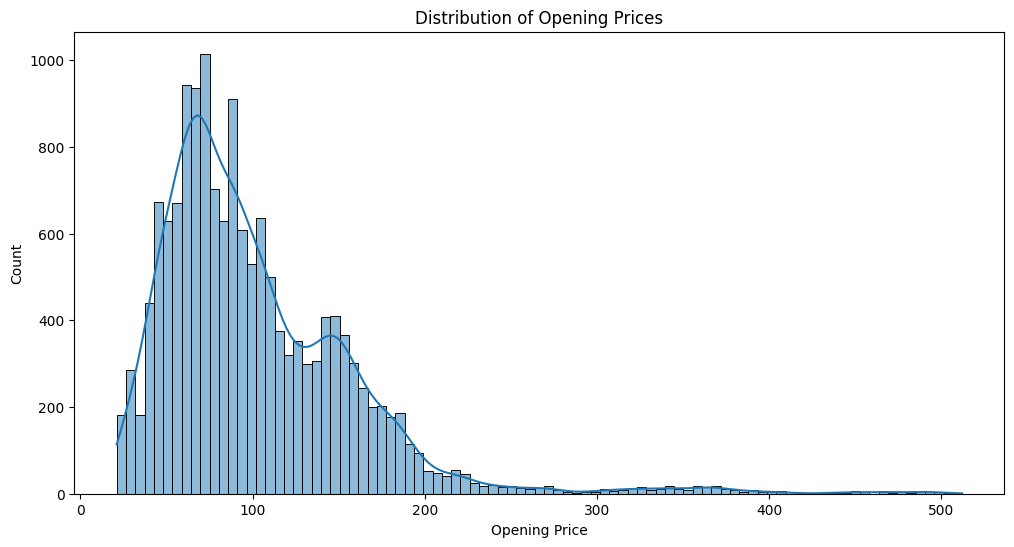

In [21]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['open'], kde=True)
plt.title('Distribution of Opening Prices')
plt.xlabel('Opening Price')

<Axes: xlabel='open'>

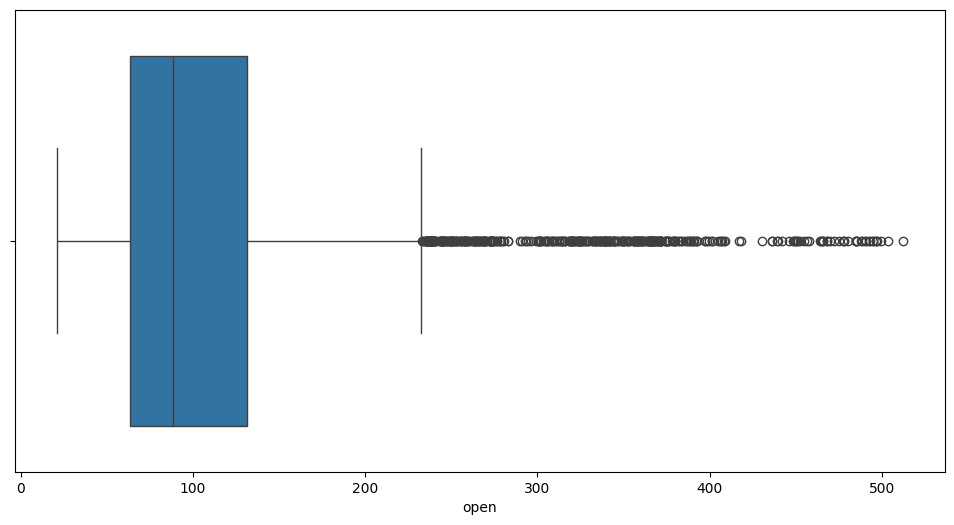

In [15]:
#Boxplot of opening prices
plt.figure(figsize=(12,6))
sns.boxplot(data=stk_prices_indicators['open'], orient='h')

##### The data appears quite skewed to the right, with a long tail on the right side. This indicates that there are a few instances of very high opening prices compared to the majority of the data. There are visible outliers, fluctuations are however expected with stock prices data, removing them could destroy important signals and blind model to volatility. 

##### There are no missing values in the data. 

In [36]:
stk_prices_indicators.groupby(['ticker','Year'])['open'] \
    .agg(mean_open='mean', median_open='median') \
    .sort_values(by='mean_open', ascending=False)

mean_open  median_open
ticker Year                         
STK001 2023  366.094078      360.990
STK003 2022  224.110269      207.230
       2023  186.781412      184.430
       2021  184.756000      170.600
STK004 2021  165.772500      164.465
STK001 2021  164.756115      155.425
STK002 2021  160.979154      158.690
STK001 2022  158.683923      160.320
STK011 2023  155.833608      153.720
STK009 2023  150.780275      135.640
STK008 2023  141.004588      144.180
STK012 2023  140.369961      139.310
STK010 2023  139.639373      135.920
STK014 2023  135.956875      125.120
STK011 2022  135.237577      129.135
       2021  130.672385      130.220
STK002 2023  128.845255      125.910
STK012 2022  126.538154      125.260
STK004 2022  126.307615      103.575
STK010 2022  125.577538      113.580
STK004 2023  119.708667      109.210
STK012 2021  116.492077      117.955
STK009 2022  105.122231      104.935
STK013 2023  103.237843      103.960
STK010 2021  101.776038      105.195
STK002 2022   99.662346       97.380
STK008 2022   98.952808      104.120
STK006 2023   97.711882       94.440
STK005 2023   93.641255       90.550
STK008 2021   87.471154       87.990
STK005 2021   86.438538       87.165
STK013 2022   82.441538       85.055
STK018 2021   81.750923       81.025
STK019 2021   81.373346       84.055
STK020 2021   79.122692       78.880
STK006 2021   78.249385       81.850
STK009 2021   76.316346       75.685
STK005 2022   71.012654       72.640
STK014 2022   70.845077       64.265
       2021   69.444346       68.565
STK007 2021   69.238962       71.120
STK006 2022   69.143077       65.910
STK017 2021   67.244962       69.015
STK007 2023   67.116275       66.790
STK013 2021   67.016308       66.565
STK015 2021   66.634385       68.505
STK017 2023   64.324902       57.300
STK016 2021   63.124731       66.650
STK018 2023   57.488235       57.480
STK007 2022   56.632654       57.260
STK020 2023   56.118941       53.630
STK018 2022   51.674346       48.235
STK017 2022   50.337615       47.110
STK016 2022   49.205615       49.115
       2023   47.571490       47.130
STK019 2022   46.517154       35.210
STK020 2022   46.419154       43.615
STK015 2023   43.732275       42.490
       2022   32.260038       30.905
STK019 2023   28.296824       27.530

##### Ticker 01 has averagely had the highest opening prices across all 3 years.Ticker 03 however has had the highest and most stable high average across the all the tickers and the 3 years. 

In [38]:
stk_prices_indicators['high'].describe()

count    15502.000000
mean       104.210076
std         59.610521
min         22.080000
25%         64.432500
50%         90.090000
75%        132.977500
max        516.020000
Name: high, dtype: float64

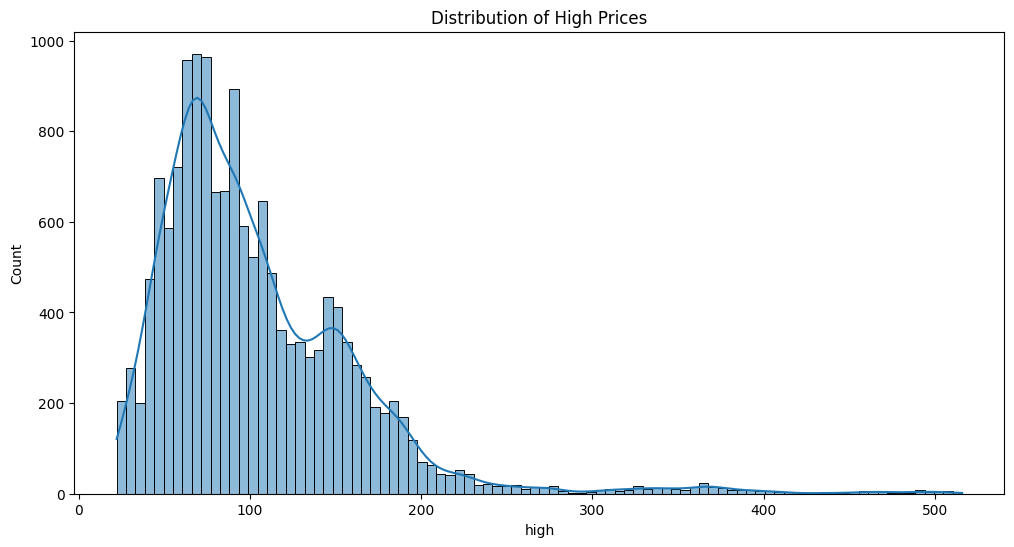

In [40]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['high'], kde=True)
plt.title('Distribution of High Prices');

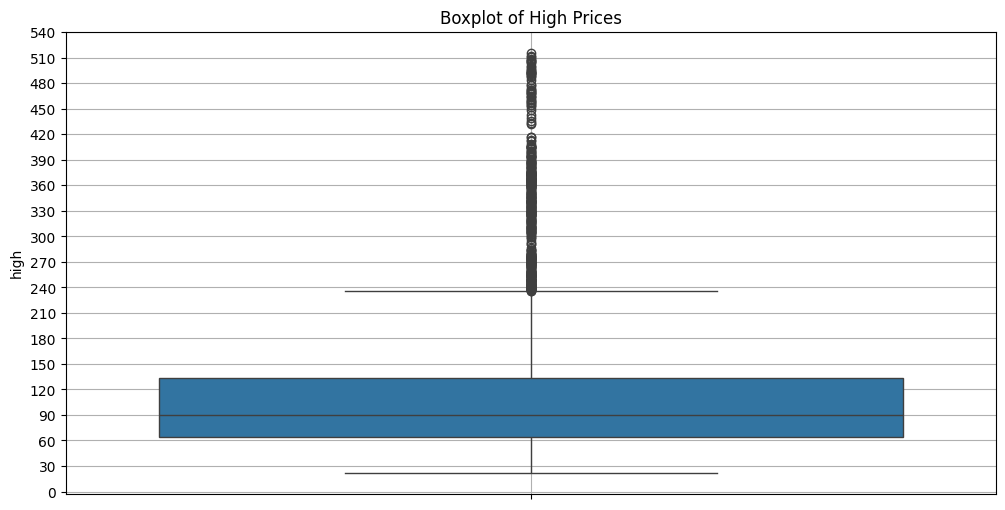

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['high'])
plt.title('Boxplot of High Prices')
plt.yticks(range(0,550,30))
plt.grid();

##### The data appears quite skewed to the right, with a long tail on the right side. The also appears bimodal.The average high price is £90 with outliers noted above £240. 

In [44]:
stk_prices_indicators.low.describe()

count    15502.000000
mean       100.685710
std         57.519995
min         21.060000
25%         62.235000
50%         87.155000
75%        128.850000
max        497.210000
Name: low, dtype: float64

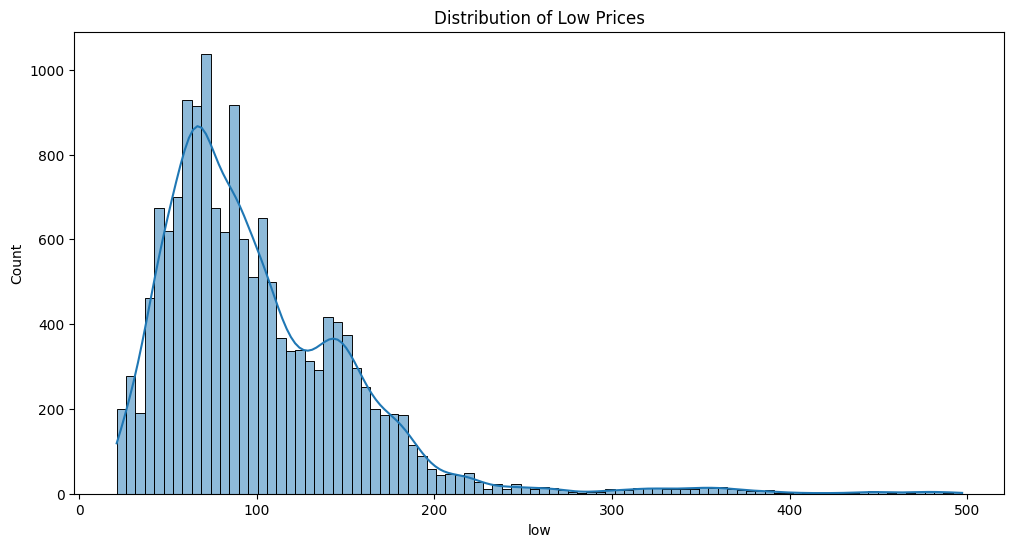

In [45]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['low'], kde=True)
plt.title('Distribution of Low Prices');

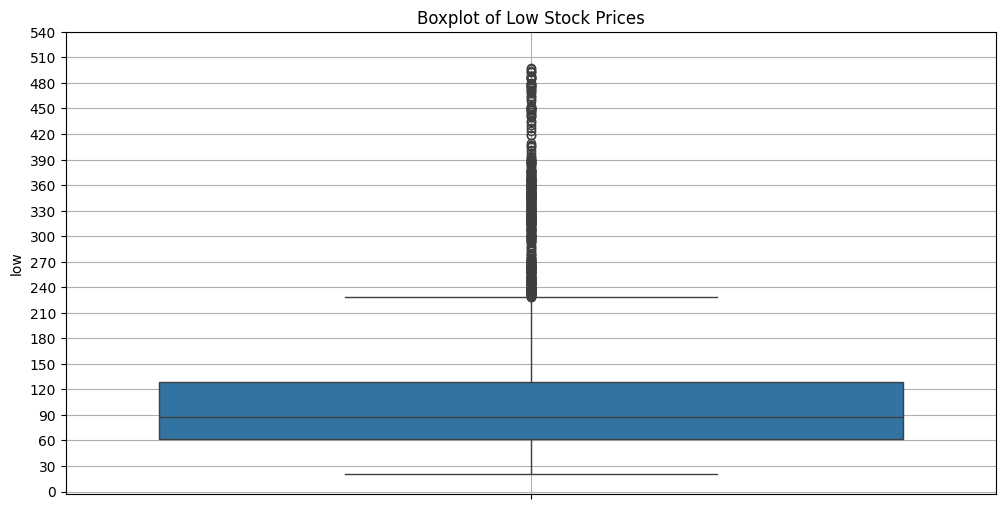

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['low'])
plt.yticks(range(0,550,30)) 
plt.grid()
plt.title('Boxplot of Low Stock Prices');

##### The low prices also appears quite skewed to the right, with a long tail on the right side. They also appear bimodal. The majority of the prices also tend to fall below 200 with fewer larger values. There are visible outliers, fluctuations are however expected with stock prices data, removing them could destroy important signals and blind model to volatility.

In [ ]:
stk_prices_indicators['close'].describe()

count    15502.000000
mean       102.447796
std         58.583470
min         21.440000
25%         63.332500
50%         88.650000
75%        130.967500
max        509.110000
Name: close, dtype: float64

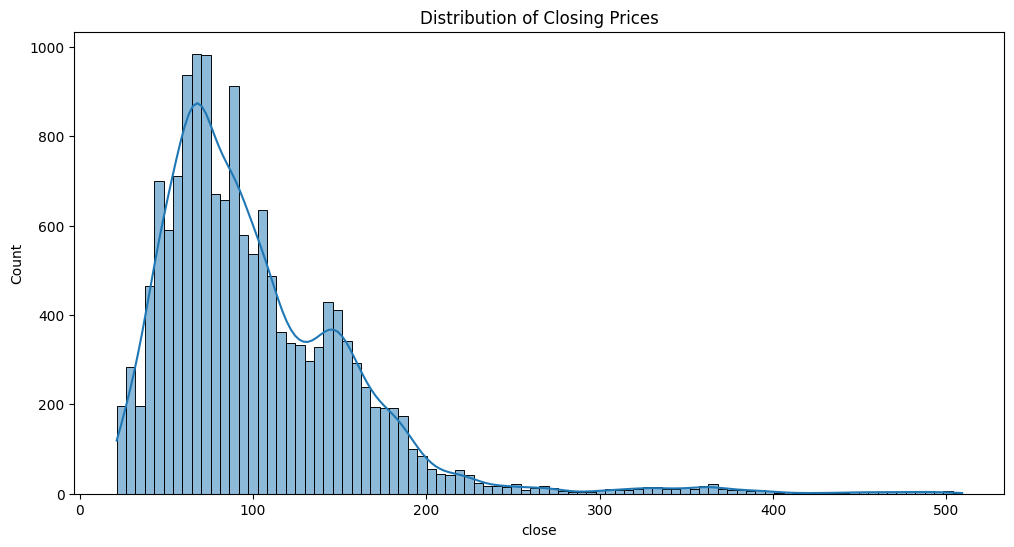

In [48]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['close'], kde=True)
plt.title('Distribution of Closing Prices');

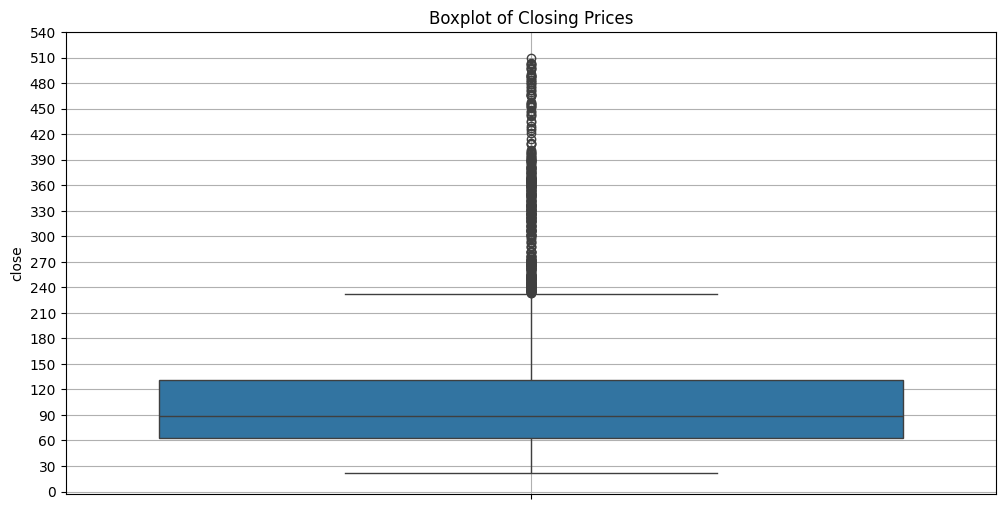

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['close'])
plt.yticks(range(0,550,30))
plt.grid()
plt.title('Boxplot of Closing Prices');

##### The dataset for the closing prices is skewed to the right with obvious outliers. The data is also multimodal. There are some evident outliers above 230 with an average closing price of £90.

In [12]:
vol = ['volume', 'volume_sma_20', 'volume_ratio']

In [16]:
for col in vol:
    m = round(stk_prices_indicators[col].describe(),2)
    print(f"Statistics for {col}:\n{m}\n")

Statistics for volume:
count       15502.00
mean      1255806.35
std        388042.56
min        801893.00
25%       1069135.50
50%       1249854.00
75%       1420746.75
max      13996964.39
Name: volume, dtype: float64

Statistics for volume_sma_20:
count      15502.00
mean     1245795.35
std        56591.06
min       885470.00
25%      1207038.44
50%      1243692.20
75%      1282458.41
max      1578011.00
Name: volume_sma_20, dtype: float64

Statistics for volume_ratio:
count    15192.00
mean         1.00
std          0.17
min          0.61
25%          0.86
50%          1.00
75%          1.13
max          1.57
Name: volume_ratio, dtype: float64



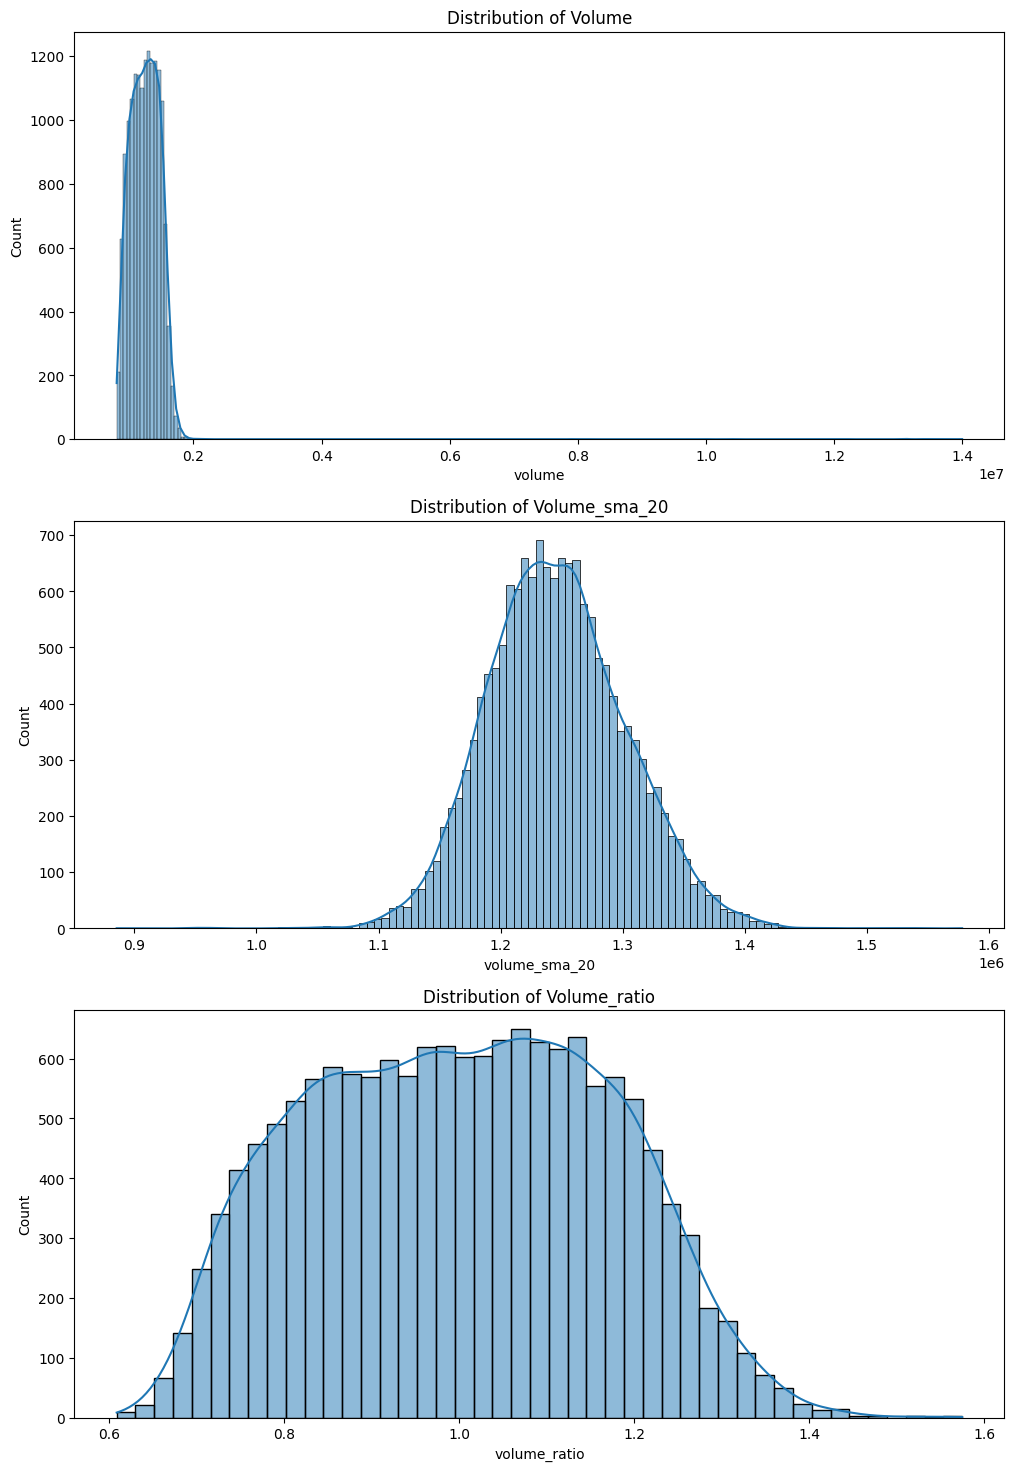

In [26]:
fig, axs = plt.subplots(3, 1, figsize=(12, 18))
axs = axs.flatten()

for i in vol: 
    sns.histplot(stk_prices_indicators[i], kde=True, ax=axs[vol.index(i)])
    axs[vol.index(i)].set_title(f'Distribution of {i.capitalize()}');


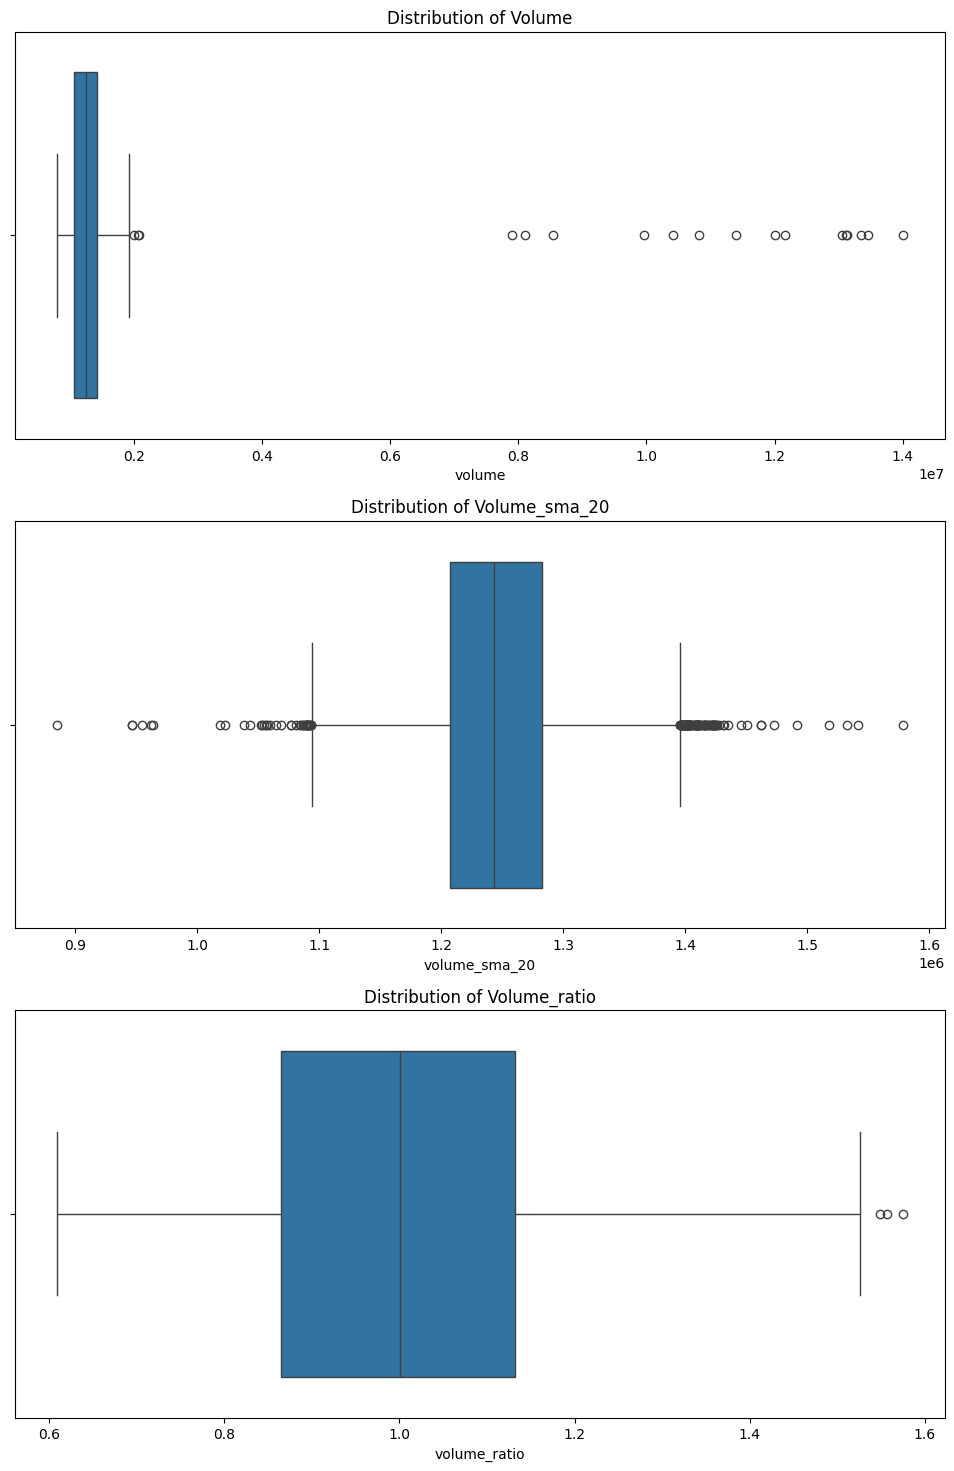

In [35]:
fig, axs = plt.subplots(3, 1, figsize=(12, 18))
axs = axs.flatten()

for i in vol: 
    sns.boxplot(stk_prices_indicators[i], ax=axs[vol.index(i)], orient='h')
    axs[vol.index(i)].set_title(f'Distribution of {i.capitalize()}');


##### The data has quite a large range, from 80K to close to 20m. The avarage volume is however below 1.2m, even for the 20 day simple moving average. There are quite a large number of outliers which is expected as this is the data for the number of shares traded, a year based analysis will provided key insights into shares exchanged per day, month and year. SMA however has outliers on the lower and higher bands of the data. 

##### The data is quite balanced however as the mean and median are quite similar. 

##### The volume ratio averages at 1.0 with outliers close to 1.6. 

In [ ]:
# Exploring missing values in volume ratio
stk_prices_indicators['volume_ratio'].isnull().sum()

np.int64(310)

In [37]:
#Generating missing volume ratio
stk_prices_indicators['vol_rat2'] = stk_prices_indicators['volume'] / stk_prices_indicators['volume_sma_20']

In [ ]:
#Checking if new volume ratio is same as old volume ratio
stk_prices_indicators[['ticker','volume_ratio', 'vol_rat2']]

,ticker,volume_ratio,vol_rat2
0,STK001,1.000000,1.000000
1,STK001,1.153842,1.153842
2,STK001,1.167277,1.167277
3,STK001,1.167320,1.167320
4,STK001,0.694431,0.694431
...,...,...,...
15497,STK020,0.840504,0.840504
15498,STK020,0.853584,0.853584
15499,STK020,0.884184,0.884184
15500,STK020,0.890195,0.890195


In [ ]:
# Checking if the new volume ratio has missing values
stk_prices_indicators['vol_rat2'].isnull().sum()

np.int64(0)

In [41]:
#Filling volume ratio missing values with newly generated volume ratio
stk_prices_indicators['volume_ratio'].fillna(stk_prices_indicators['vol_rat2'], inplace=True)

C:\Users\ofori\AppData\Local\Temp\ipykernel_15028\2376775138.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stk_prices_indicators['volume_ratio'].fillna(stk_prices_indicators['vol_rat2'], inplace=True)


In [26]:
stk_prices_indicators['adjusted_close'].describe()

count    15502.000000
mean       102.447796
std         58.583470
min         21.440000
25%         63.332500
50%         88.650000
75%        130.967500
max        509.110000
Name: adjusted_close, dtype: float64

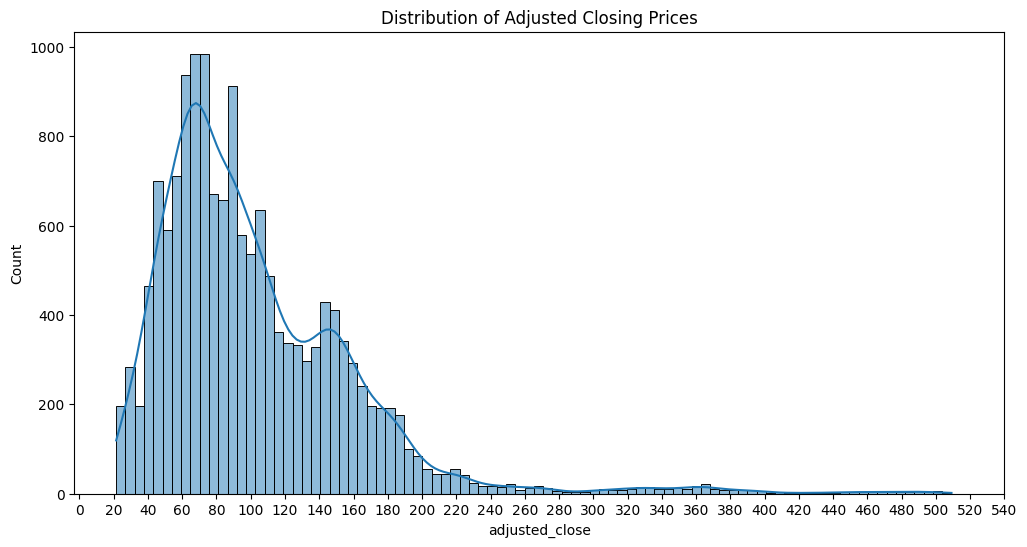

In [27]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['adjusted_close'], kde=True)
plt.title('Distribution of Adjusted Closing Prices')
plt.xticks(range(0,550,20));

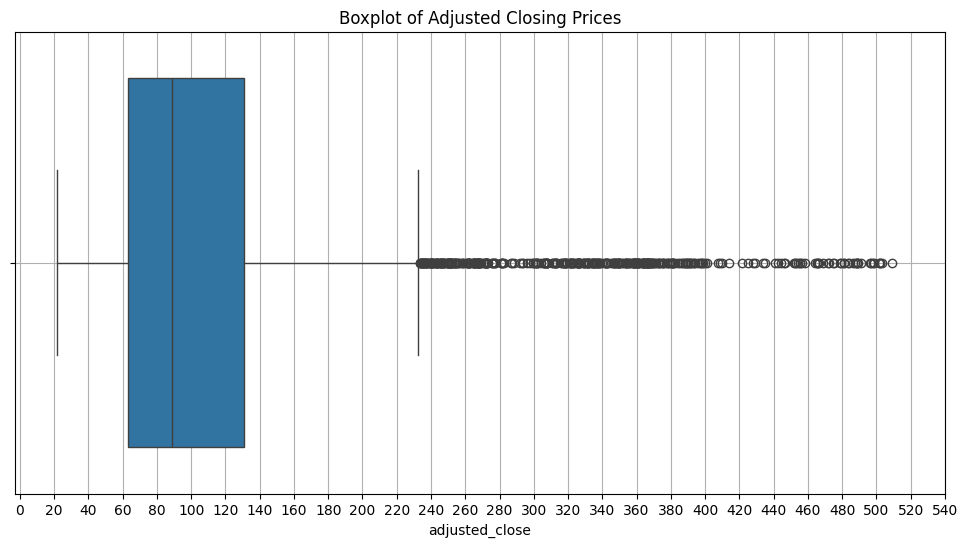

In [30]:
plt.figure(figsize=(12,6))
sns.boxplot(data=stk_prices_indicators['adjusted_close'], orient='h')
plt.title('Boxplot of Adjusted Closing Prices')
plt.xticks(range(0,550,20))
plt.grid();


##### The adjusted close prices are quite skewed to the right, with average price of about 90. There are however some outliers with prices above 240. The data is also multimodal. The outliers are however expected although these have been adjusted. 

In [32]:
print(stk_prices_indicators['adjusted_close'].isnull().sum())

0


In [33]:
stk_prices_indicators['sma_20'].describe()

count    15192.000000
mean       102.145547
std         57.549051
min         22.808000
25%         63.007500
50%         88.149250
75%        130.658125
max        489.384000
Name: sma_20, dtype: float64

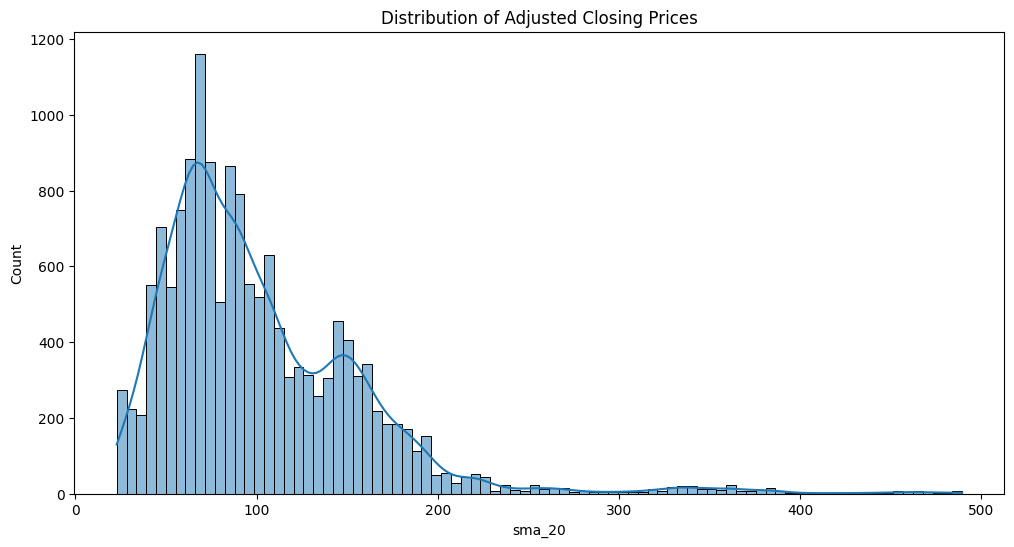

In [34]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['sma_20'], kde=True)
plt.title('Distribution of Adjusted Closing Prices');

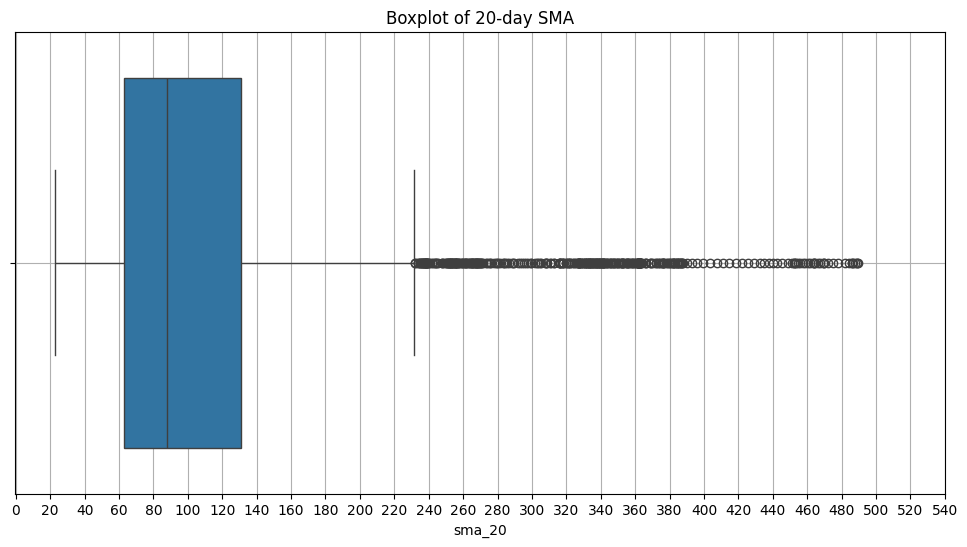

In [35]:
plt.figure(figsize=(12,6))
sns.boxplot(data=stk_prices_indicators['sma_20'], orient='h')
plt.xticks(range(0,550,20))
plt.title('Boxplot of 20-day SMA')
plt.grid();

In [50]:
stk_prices_indicators['sma_20'].isnull().sum()

np.int64(310)

##### Nulls are expected for SMA as the first 19 days will not have enough data to compute the SMA. We will further investigate the nulls to confirm this.

In [68]:
stk_prices_indicators.sort_values(by=['ticker','date'])

,ticker,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,...,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label,Year,Month,Day,mnth_yr
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,STK001,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,160.110000,...,NaN,NaN,0.000000,NaN,0.026357,Uptrend,2021,1,4,2021-01-01
2021-01-05,STK001,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,161.235000,...,NaN,NaN,0.006977,NaN,0.018169,Sideways,2021,1,5,2021-01-01
2021-01-06,STK001,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,161.416667,...,NaN,NaN,0.002251,0.012463,-0.012301,Sideways,2021,1,6,2021-01-01
2021-01-07,STK001,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,162.830000,...,NaN,NaN,0.026039,0.018138,-0.061950,Downtrend,2021,1,7,2021-01-01
2021-01-08,STK001,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,163.400000,...,NaN,NaN,0.013953,0.018663,-0.070196,Downtrend,2021,1,8,2021-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-18,STK020,76.16,77.62,75.43,76.39,1029767.0,76.39,67.238000,58.996800,58.124050,...,0.106620,0.344658,0.294816,0.024476,-0.046865,Downtrend,2023,12,18,2023-12-01
2023-12-19,STK020,76.93,78.72,75.06,76.97,1031912.0,76.97,68.222000,59.477800,58.251450,...,0.170468,0.343515,0.294096,0.024489,0.010913,Sideways,2023,12,19,2023-12-01
2023-12-20,STK020,77.89,77.89,76.83,77.24,1057795.0,77.24,69.164000,59.972400,58.374450,...,0.151118,0.322603,0.287926,0.024602,-0.004531,Sideways,2023,12,20,2023-12-01


In [52]:
sma_20_null = stk_prices_indicators[stk_prices_indicators['sma_20'].isnull()]

In [53]:
sma_20_null['ticker'].value_counts()

ticker
STK014    21
STK006    20
STK009    19
STK013    19
STK019    18
STK015    18
STK010    18
STK005    17
STK008    17
STK020    16
STK018    16
STK011    15
STK017    15
STK012    15
STK007    13
STK016    13
STK002    11
STK001    11
STK003    10
STK004     8
Name: count, dtype: int64

In [58]:
sma_20_null.groupby('mnth_yr')['sma_20'].size()

mnth_yr
2021-01-01     7
2021-02-01     6
2021-03-01     7
2021-04-01     8
2021-05-01     9
2021-06-01     5
2021-07-01    18
2021-08-01     6
2021-09-01    11
2021-10-01     3
2021-11-01    14
2021-12-01    12
2022-01-01    10
2022-02-01     7
2022-03-01     6
2022-04-01    12
2022-05-01    12
2022-06-01    11
2022-07-01    12
2022-08-01     3
2022-09-01     7
2022-10-01     9
2022-11-01    13
2022-12-01     3
2023-01-01    12
2023-02-01    11
2023-03-01     5
2023-04-01     6
2023-05-01    10
2023-06-01    11
2023-07-01    12
2023-08-01     4
2023-09-01     8
2023-10-01     6
2023-11-01    10
2023-12-01     4
Name: sma_20, dtype: int64

In [62]:
sma_20_null.sort_values(by='date')

,ticker,open,high,low,close,volume,adjusted_close,sma_20,sma_50,sma_200,...,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label,Year,Month,Day,mnth_yr
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,STK003,174.11,176.13,170.31,173.94,1541580.0,173.94,NaN,173.940000,173.940000,...,NaN,NaN,0.000000,NaN,-0.026388,Downtrend,2021,1,4,2021-01-01
2021-01-06,STK006,82.69,83.53,82.34,83.02,1090340.0,83.02,NaN,83.433333,83.433333,...,NaN,NaN,-0.004954,0.007131,0.052517,Uptrend,2021,1,6,2021-01-01
2021-01-06,STK008,94.77,96.55,94.77,95.97,889376.0,95.97,NaN,94.996667,94.996667,...,NaN,NaN,0.010246,0.018771,-0.044701,Downtrend,2021,1,6,2021-01-01
2021-01-06,STK018,64.78,65.83,63.77,65.13,1051631.0,65.13,NaN,63.750000,63.750000,...,NaN,NaN,0.021647,0.037916,-0.074927,Downtrend,2021,1,6,2021-01-01
2021-01-14,STK012,93.52,96.33,93.52,95.76,1295080.0,95.76,NaN,98.233333,98.233333,...,NaN,NaN,-0.025178,0.018695,0.034148,Uptrend,2021,1,14,2021-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-30,STK011,145.79,145.79,141.03,142.44,949649.0,142.44,NaN,140.752600,158.111450,...,-0.020425,-0.017926,0.011988,0.019799,-0.037138,Downtrend,2023,11,30,2023-11-01
2023-12-04,STK016,42.90,43.59,42.90,43.35,1419812.0,43.35,NaN,42.088800,48.369350,...,0.033619,0.094421,0.029965,0.016797,0.011995,Sideways,2023,12,4,2023-12-01
2023-12-12,STK010,97.12,97.93,96.60,97.15,1525542.0,97.15,NaN,125.678400,139.291850,...,-0.152712,-0.264572,-0.226995,0.031510,0.013176,Sideways,2023,12,12,2023-12-01


##### The nulls seems quite sporadic and not necessaerily concentrated in the beginning of the data for each ticker. Further investigation is needed to understand the cause of these nulls. It could be due to data collection issues or specific market events affecting certain stocks. As weekends have already been identified as not covered by the data and all tickers have the adequate dates present, these are most likely Nulls from data calaculation and can be filled using the previous data from within the price section. 

In [73]:
#Developing column to fill in missing sma_20 values
stk_prices_indicators = stk_prices_indicators.sort_values(['ticker', 'date'])

# SMA20 from close price
stk_prices_indicators['SMA20'] = (
    stk_prices_indicators
        .groupby('ticker')['close']
        .rolling(window=20, min_periods=20)
        .mean()
        .reset_index(level=0, drop=True)
)

In [84]:
stk_prices_indicators[['ticker','SMA20','sma_20']].head(25)

,ticker,SMA20,sma_20
date,,,
2021-01-04,STK001,NaN,160.110000
2021-01-05,STK001,NaN,161.235000
2021-01-06,STK001,NaN,161.416667
2021-01-07,STK001,NaN,162.830000
2021-01-08,STK001,NaN,163.400000
2021-01-11,STK001,NaN,163.555000
2021-01-12,STK001,NaN,163.805714
2021-01-13,STK001,NaN,163.303750
2021-01-14,STK001,NaN,162.572222


In [ ]:
stk_prices_indicators[stk_prices_indicators['ticker'] == 'STK002'][['sma_20','SMA20']]

,sma_20,SMA20
date,,
2021-01-04,166.570000,NaN
2021-01-05,162.625000,NaN
2021-01-06,162.146667,NaN
2021-01-07,162.007500,NaN
2021-01-08,160.950000,NaN
...,...,...
2023-12-18,100.378500,100.3785
2023-12-19,99.850500,99.8505
2023-12-20,99.435500,99.4355


In [94]:
stk_prices_indicators[stk_prices_indicators['ticker'] == 'STK007'][['sma_20','SMA20']]

,sma_20,SMA20
date,,
2021-01-04,76.8500,NaN
2021-01-05,76.8700,NaN
2021-01-06,77.3600,NaN
2021-01-07,77.5225,NaN
2021-01-08,77.8800,NaN
...,...,...
2023-12-18,62.2350,62.2350
2023-12-19,62.0800,62.0800
2023-12-20,61.9230,61.9230


In [95]:
stk_prices_indicators[stk_prices_indicators['ticker'] == 'STK019'][['sma_20','SMA20']]

,sma_20,SMA20
date,,
2021-01-04,83.070000,NaN
2021-01-05,81.510000,NaN
2021-01-06,82.456667,NaN
2021-01-07,83.342500,NaN
2021-01-08,83.794000,NaN
...,...,...
2023-12-18,27.561000,27.5610
2023-12-19,27.539000,27.5390
2023-12-20,27.489000,27.4890


#### It is evident that, the SMA20 provides same data as sma_20 and therefore can be used to fill the NULL values. However, there are nulls for the first 20 values of each ticker, which explains the nulls. 

In [89]:
stk_prices_indicators['sma_20'] = stk_prices_indicators['sma_20'].fillna(stk_prices_indicators['SMA20'])

In [96]:
stk_prices_indicators['sma_20'].isnull().sum()

np.int64(7)

In [100]:
sma_20_null = stk_prices_indicators[stk_prices_indicators['sma_20'].isnull()]
sma_20_null.groupby(['ticker','mnth_yr'])['sma_20'].size()

ticker  mnth_yr   
STK003  2021-01-01    2
STK006  2021-01-01    1
STK008  2021-01-01    1
STK009  2021-01-01    1
STK012  2021-01-01    1
STK018  2021-01-01    1
Name: sma_20, dtype: int64

##### The total number of nulls in the 'sma_20' column has been successfully filled using the calculated 'SMA20' values based on the closing prices. This ensures that our dataset is more complete and ready for further analysis. 7 values were however not filled and most likely to be dropped. These values were the beginning months which cannot be generated without prior data. 

In [70]:
stk_prices_indicators['sma_50'].describe()

count    15502.000000
mean       101.370939
std         55.626918
min         23.391200
25%         64.068350
50%         87.822600
75%        130.193450
max        470.320200
Name: sma_50, dtype: float64

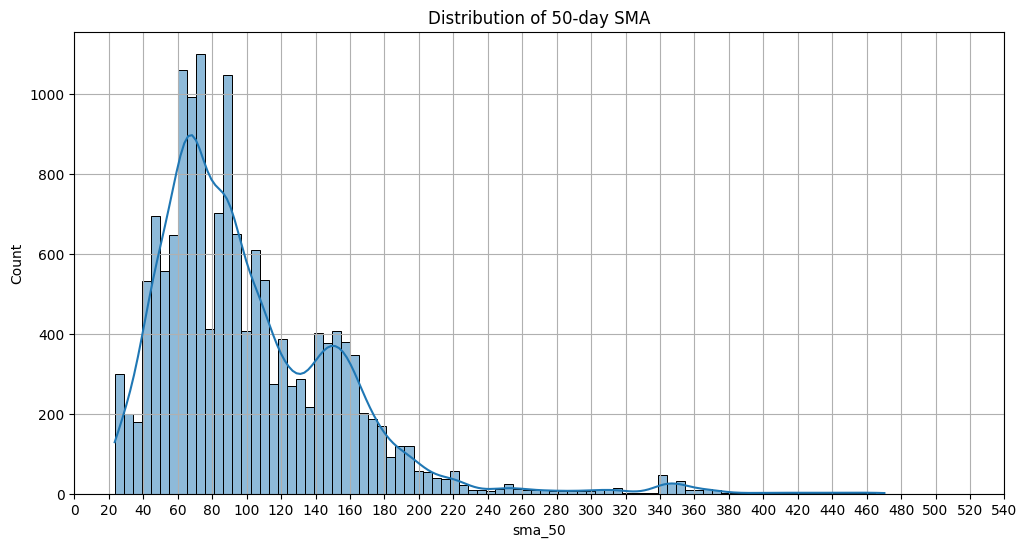

In [71]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['sma_50'], kde=True)
plt.title('Distribution of 50-day SMA')
plt.xticks(range(0,550,20))
plt.grid();    

##### The sma_50 data is right skewed and bimodal with most values concentrated between 60 and 100, with another concentrated between 140 and 160.

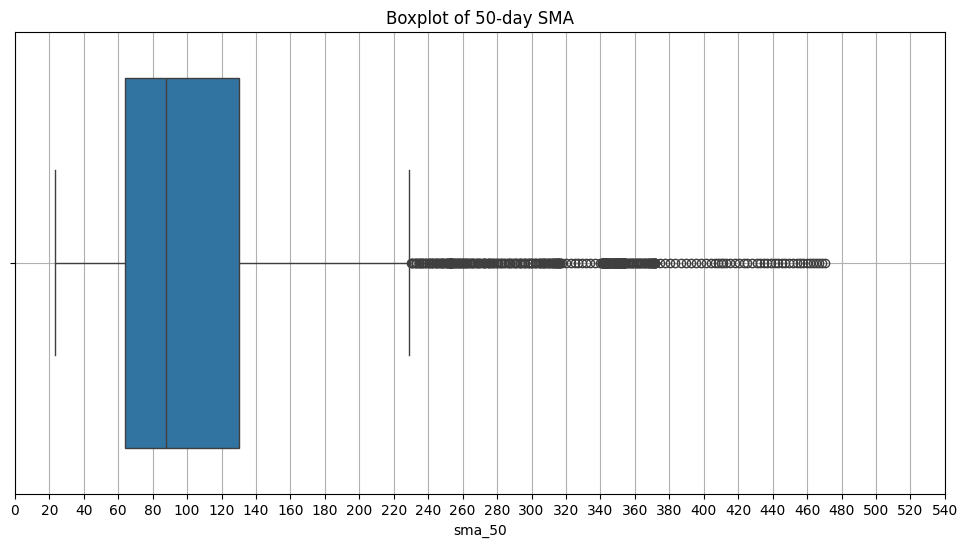

In [72]:
plt.figure(figsize=(12,6))
sns.boxplot(data=stk_prices_indicators['sma_50'], orient='h')
plt.title('Boxplot of 50-day SMA')
plt.xticks(range(0,550,20))
plt.grid();

##### There are evident outliers closer to 220 with the average drawn closer to 80 as well. 

In [104]:
print(stk_prices_indicators['sma_50'].isnull().sum())

0


##### There are no nulls in the sma_50 column.

In [105]:
stk_prices_indicators['sma_200'].describe()

count    15502.000000
mean        99.078231
std         49.001519
min         25.758150
25%         66.673452
50%         86.859500
75%        127.921712
max        383.890800
Name: sma_200, dtype: float64

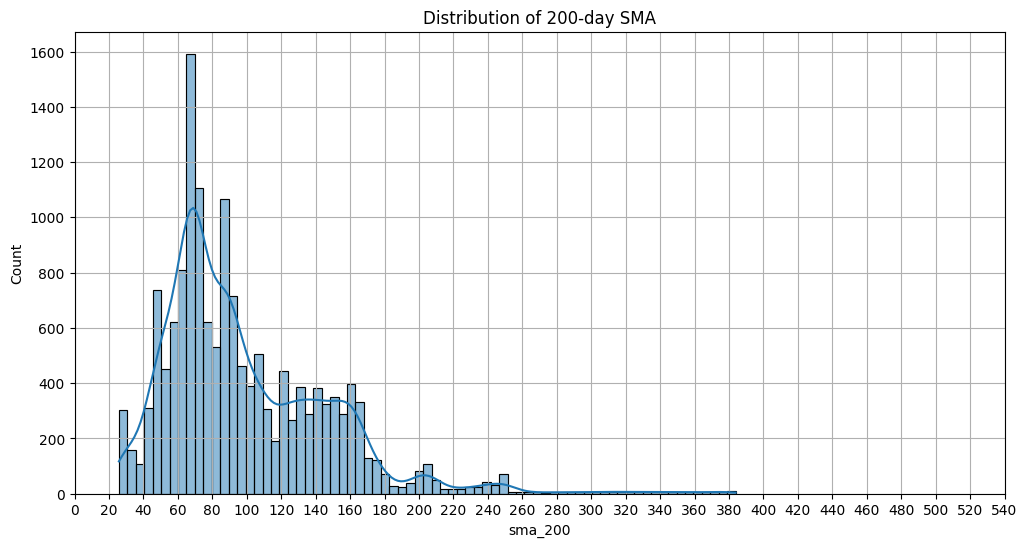

In [110]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['sma_200'], kde=True)
plt.title('Distribution of 200-day SMA')    
plt.xticks(range(0,550,20))
plt.grid();

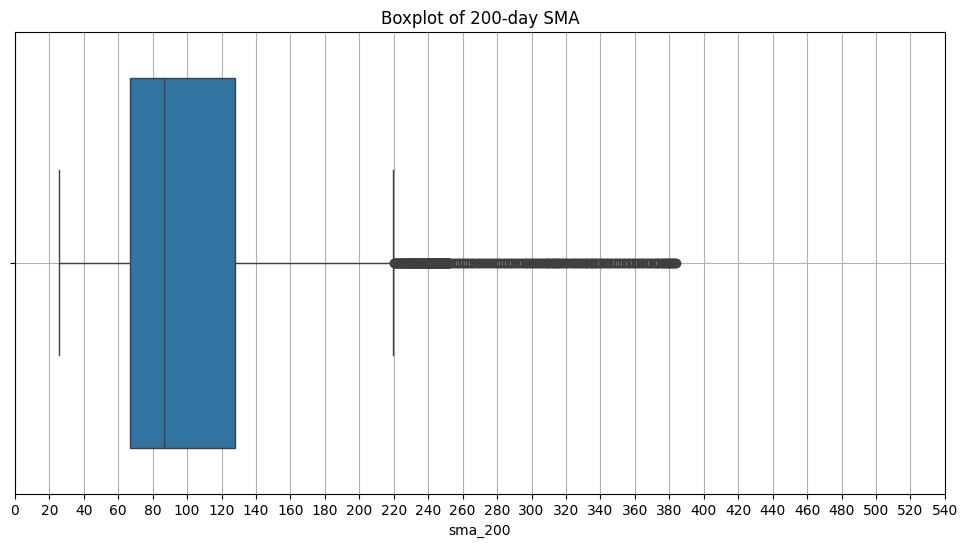

In [111]:
plt.figure(figsize=(12,6))
sns.boxplot(data=stk_prices_indicators['sma_200'], orient='h')
plt.title('Boxplot of 200-day SMA')         
plt.xticks(range(0,550,20))
plt.grid();

##### SMA 200 appears to be right skewed with a smoothened 2nd mode as compared to other predictions. The outliers are more closely packed. Quite a large amount of predictions sit between 60 & 80. 

In [112]:
stk_prices_indicators['sma_200'].isnull().sum()

np.int64(0)

#### There are no null values.

In [114]:
stk_prices_indicators['ema_12'].describe()

count    15502.000000
mean       102.205225
std         57.851272
min         22.611917
25%         62.982891
50%         88.338272
75%        130.549266
max        494.758062
Name: ema_12, dtype: float64

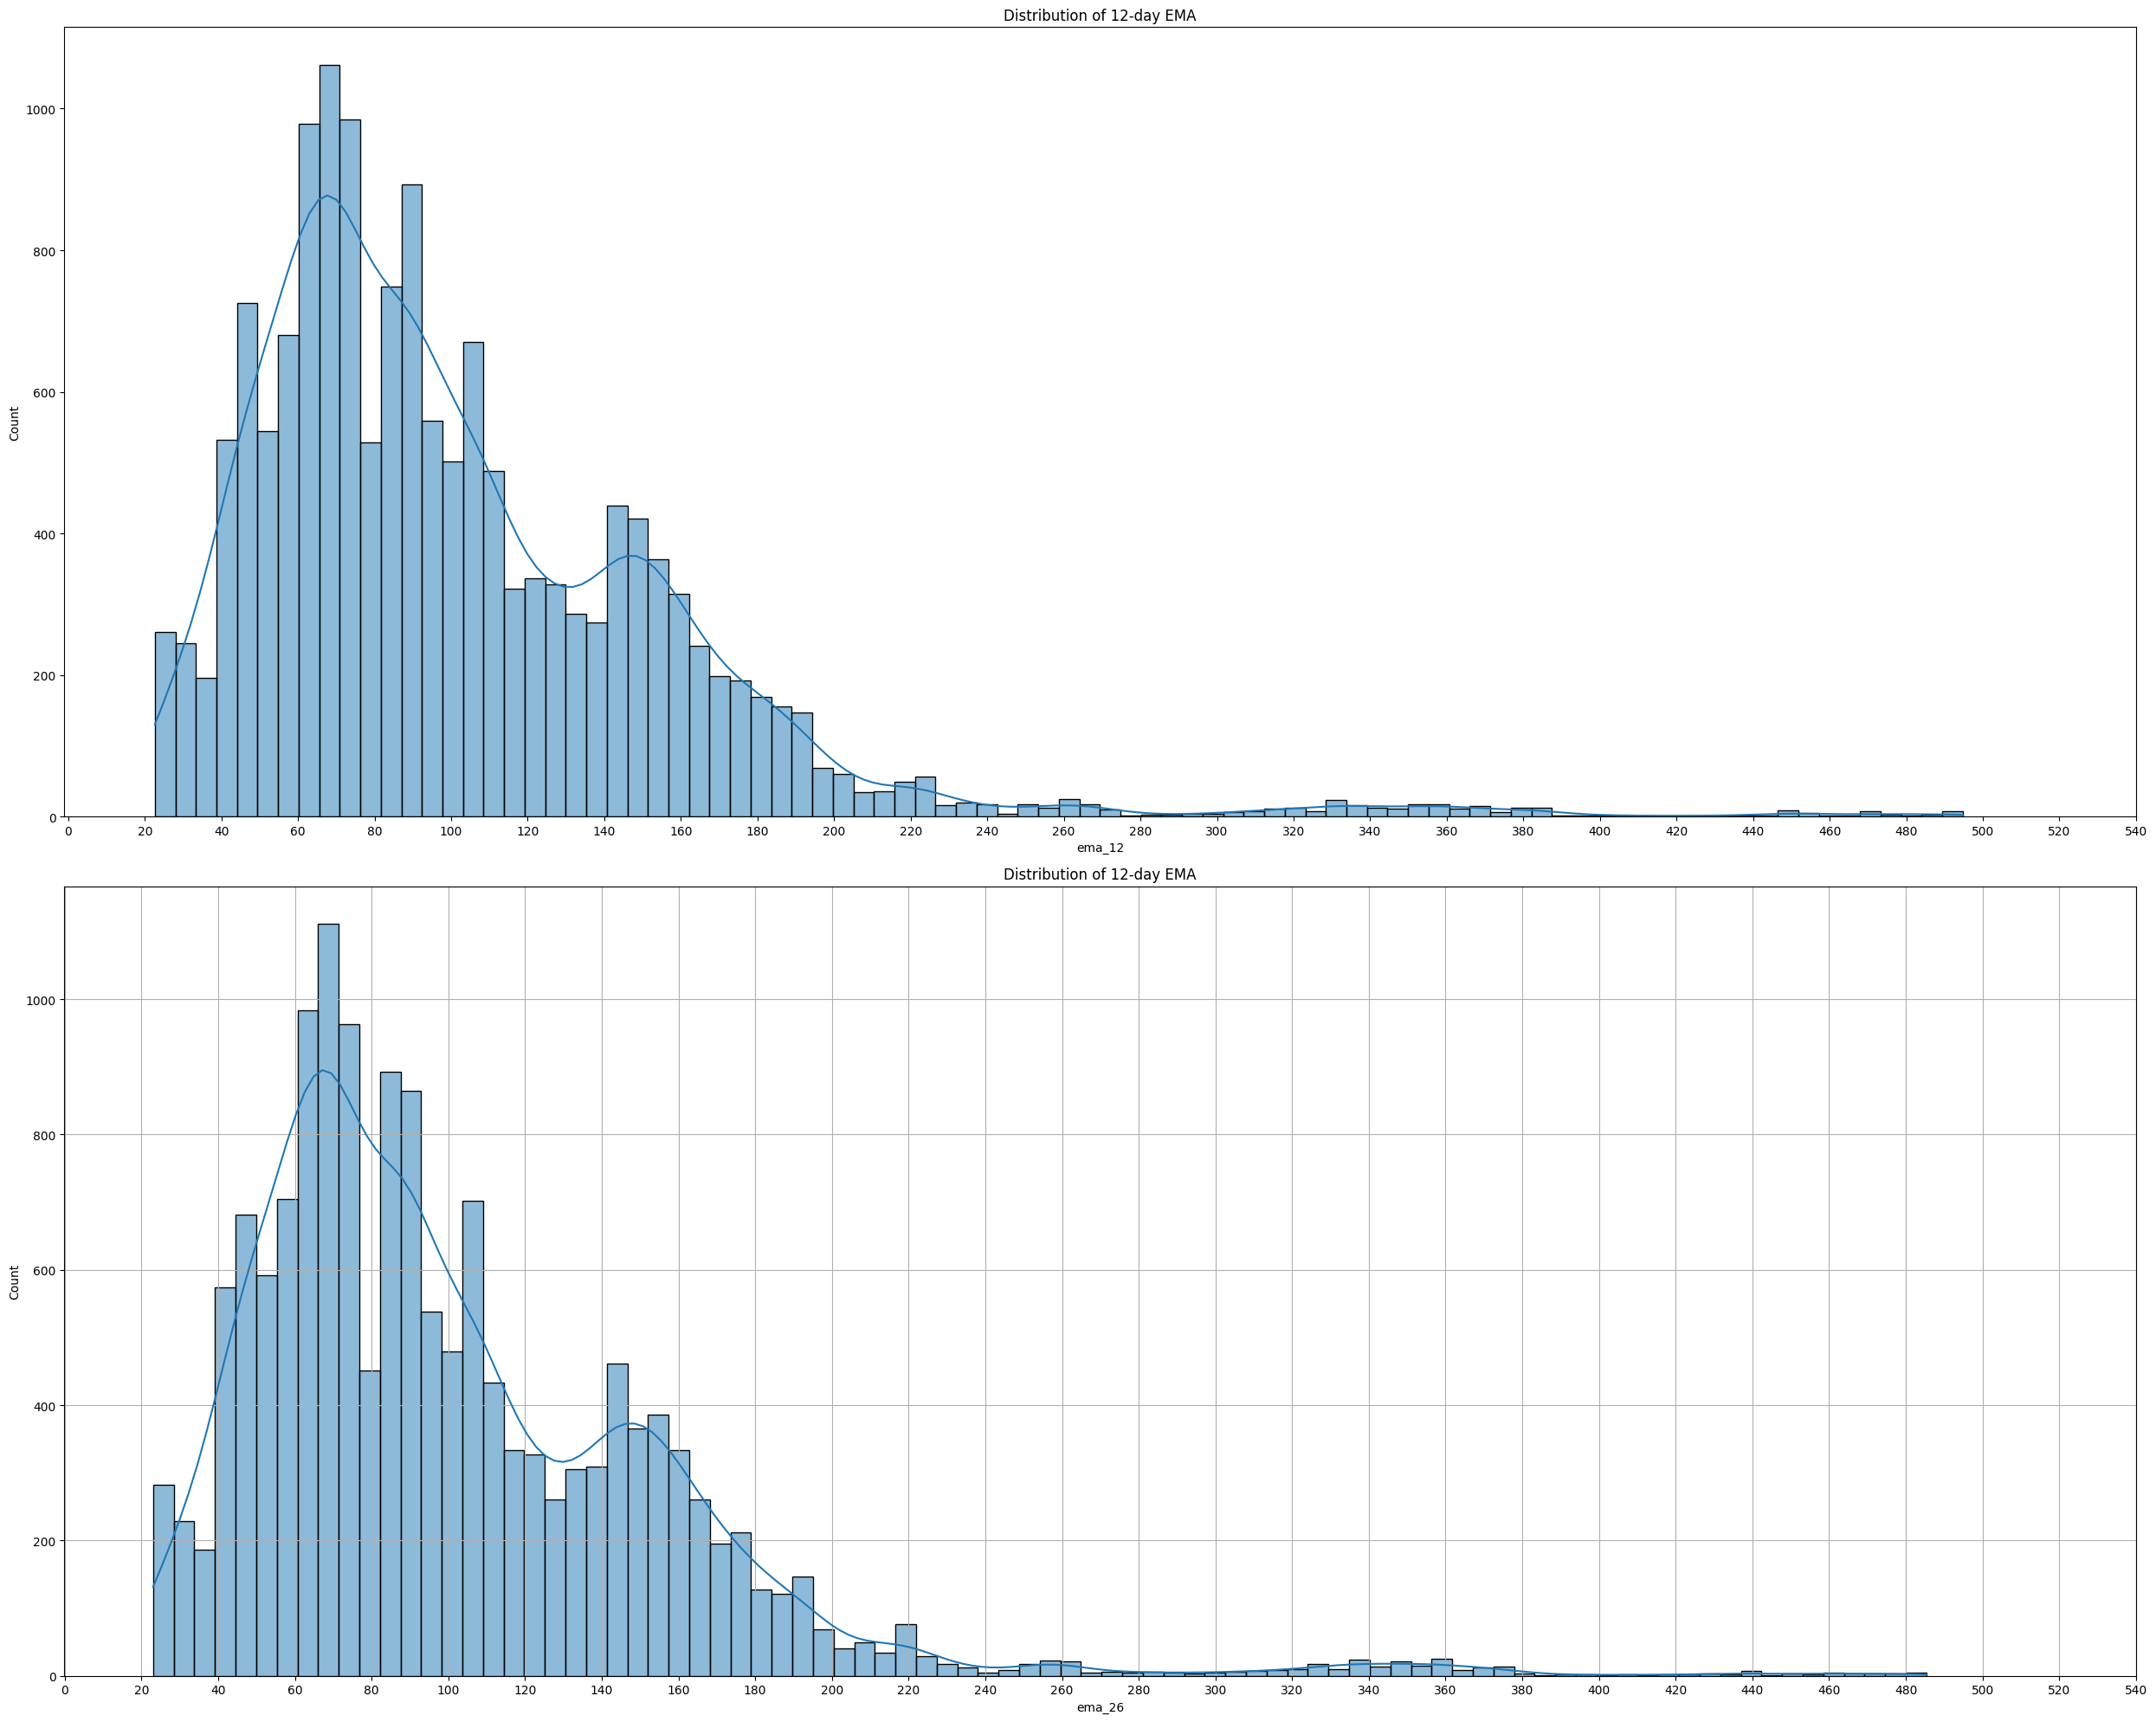

In [120]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(25,20))
axs = axs.flatten()

sns.histplot(stk_prices_indicators['ema_12'], kde=True, ax=axs[0])
axs[0].set_title('Distribution of 12-day EMA')
axs[0].set_xticks(range(0,550,20))


sns.histplot(stk_prices_indicators['ema_26'], kde=True, ax=axs[1])
axs[1].set_title('Distribution of 12-day EMA')
axs[1].set_xticks(range(0,550,20))

plt.tight_layout()
plt.grid(); 

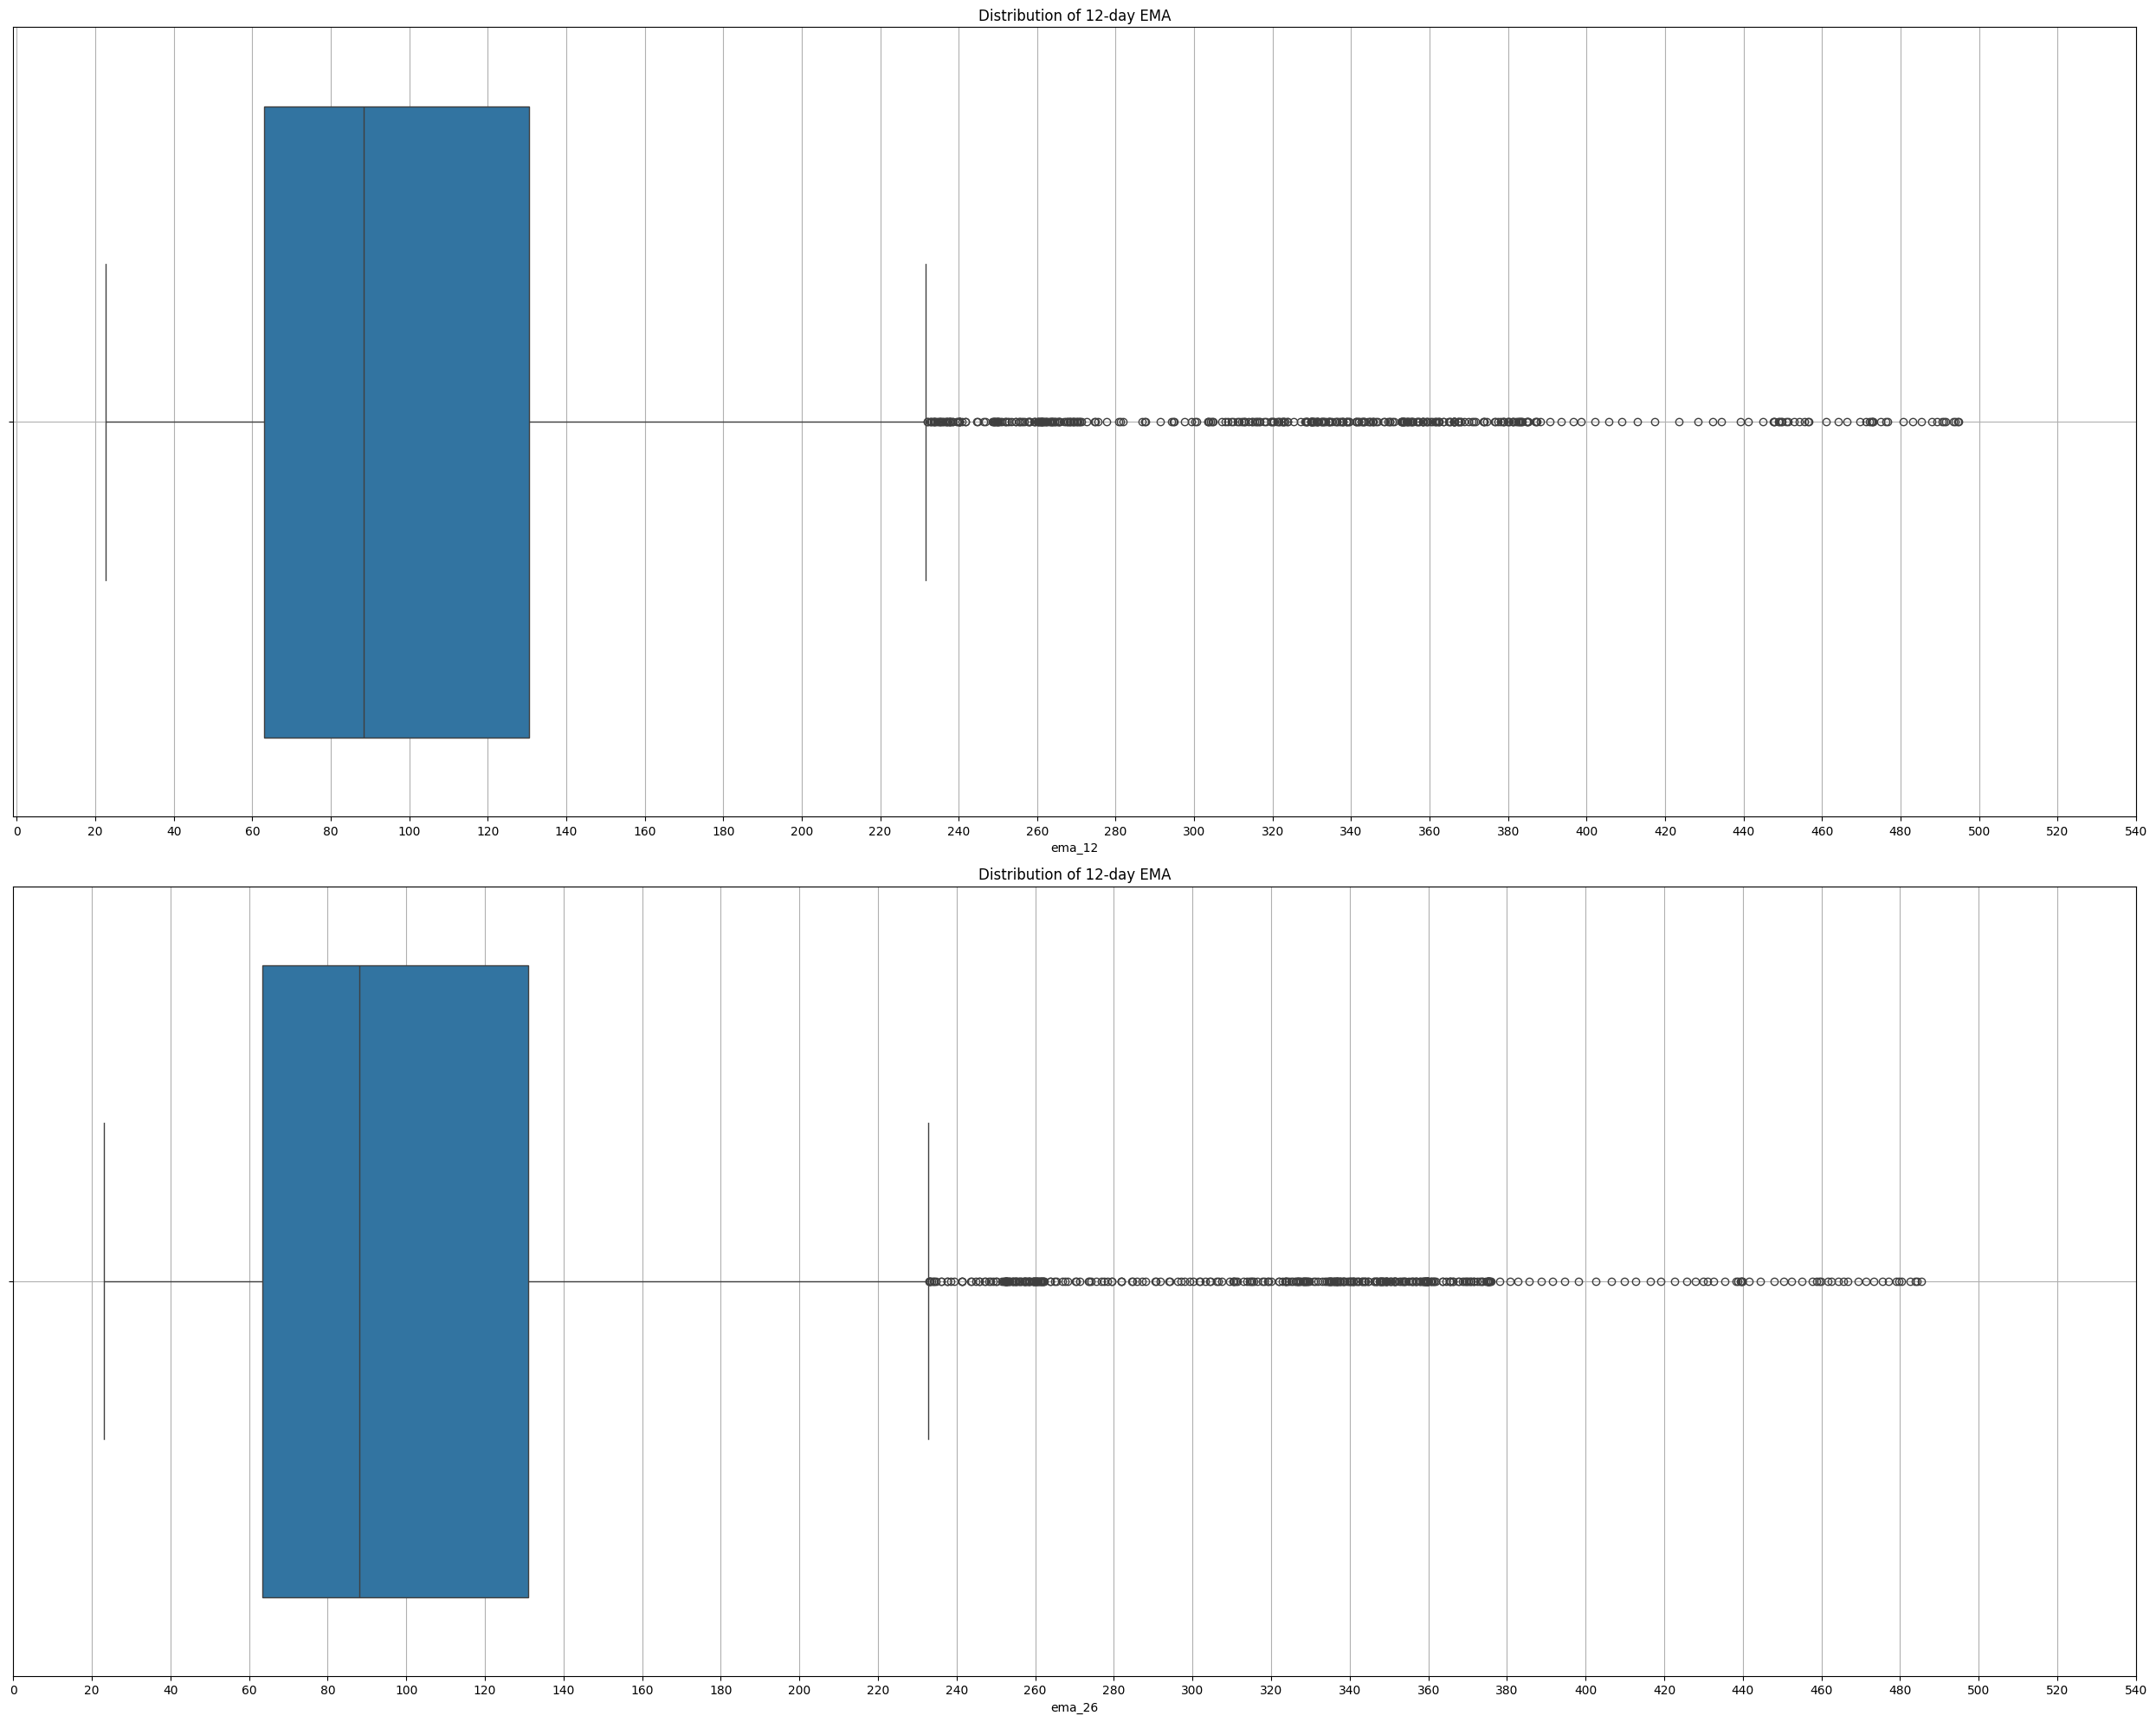

In [128]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(25,20))
axs = axs.flatten()

sns.boxplot(stk_prices_indicators['ema_12'], ax=axs[0], orient='h')
axs[0].set_title('Distribution of 12-day EMA')
axs[0].set_xticks(range(0,550,20))
axs[0].grid()


sns.boxplot(stk_prices_indicators['ema_26'], ax=axs[1], orient='h')
axs[1].set_title('Distribution of 12-day EMA')
axs[1].set_xticks(range(0,550,20))

plt.tight_layout()
axs[1].grid(); 

##### The exponential moving average (EMA) with a 12-day and 26-day span appear to be right skewed with a concentration of values between 60 and 80 and 140 and 160. There are also some extreme outliers above 230.There is however a noticeable about of higher predictions values between 80 and 100 in the 26-day EMA.

In [131]:
stk_prices_indicators['macd'].describe()    

count    15191.000000
mean         0.302839
std          3.450097
min        -23.275442
25%         -1.206885
50%          0.177854
75%          1.642282
max         27.705089
Name: macd, dtype: float64

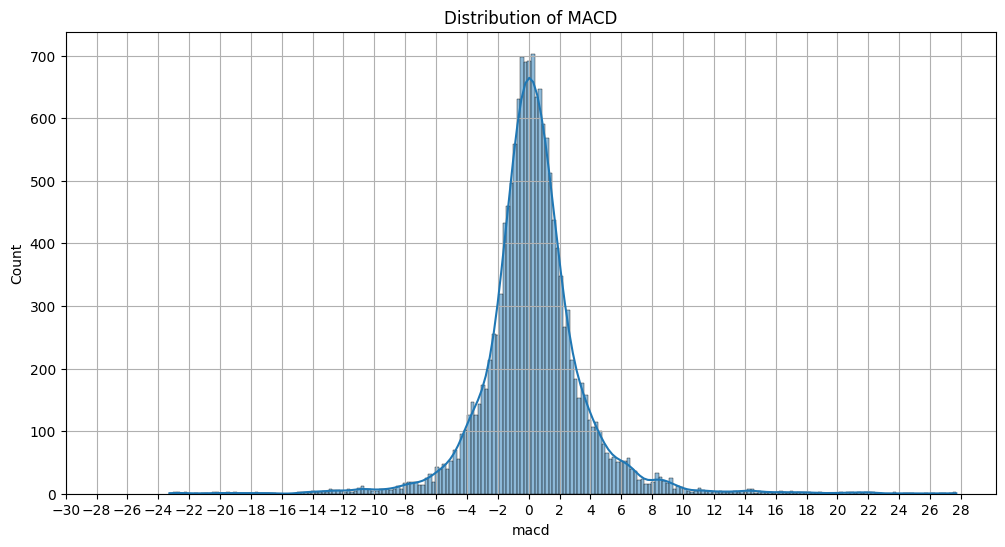

In [133]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['macd'], kde=True)
plt.title('Distribution of MACD')
plt.xticks(range(-30,30,2))
plt.grid();

In [134]:
stk_prices_indicators['macd'].isnull().sum()

np.int64(311)

In [137]:
stk_prices_indicators[['macd','ema_12','ema_26']][stk_prices_indicators['macd'].isnull()]

,macd,ema_12,ema_26
date,,,
2021-05-07,NaN,141.616051,141.600010
2021-05-31,NaN,140.941481,140.948450
2021-08-10,NaN,166.252705,159.318540
2021-08-13,NaN,173.416509,164.466359
2021-10-19,NaN,188.539703,191.240938
...,...,...,...
2023-06-01,NaN,66.511019,62.451103
2023-06-07,NaN,71.033795,65.995532
2023-07-04,NaN,69.061647,69.979822


In [143]:
#imputing missing macd values
stk_prices_indicators['macd'].fillna(stk_prices_indicators['ema_12'] - stk_prices_indicators['ema_26'], inplace=True)

In [144]:
stk_prices_indicators['macd'].isnull().sum()

np.int64(0)

#### All null values for the macd column have been filled by calculating the difference between the 12-day and 26-day EMA.

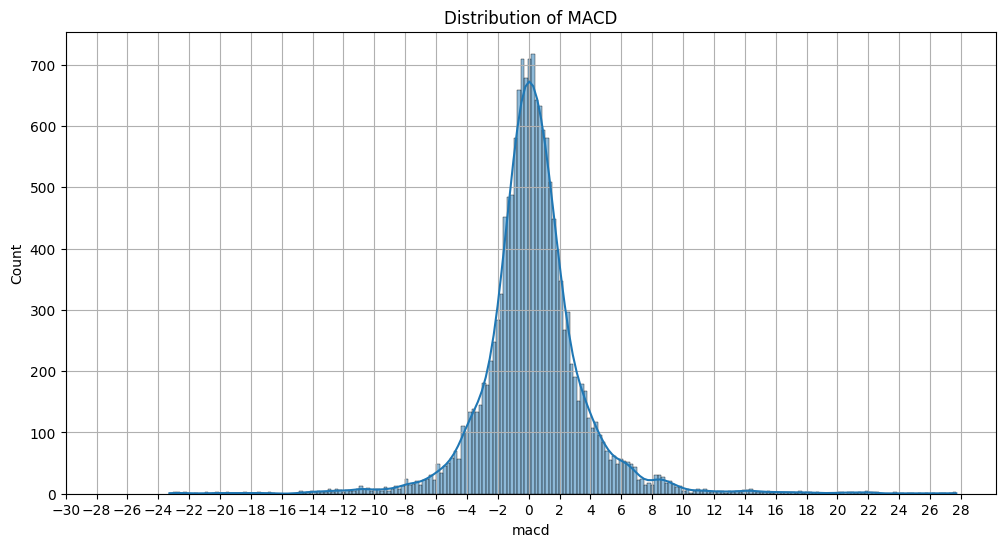

In [146]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['macd'], kde=True)
plt.title('Distribution of MACD')
plt.xticks(range(-30,30,2))
plt.grid();

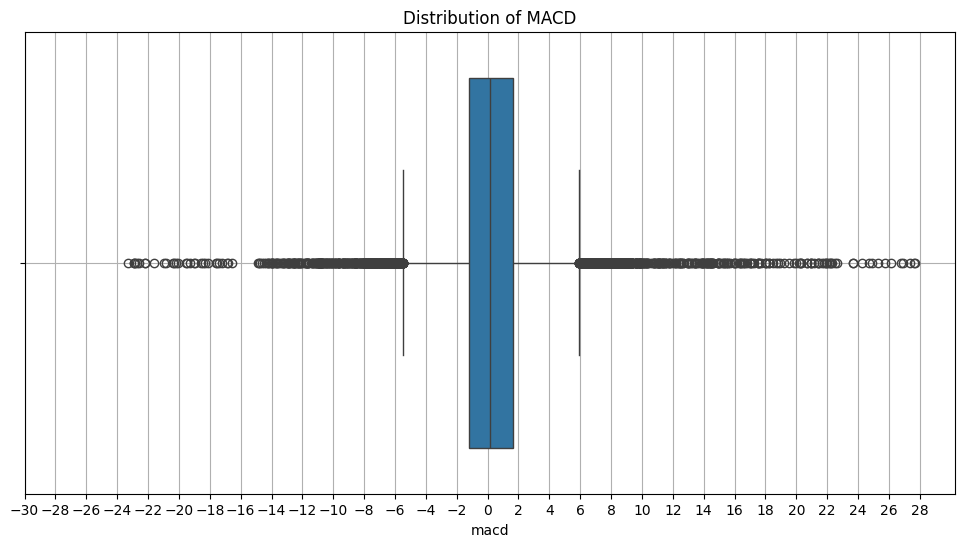

In [149]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['macd'], orient='h')
plt.title('Distribution of MACD')
plt.xticks(range(-30,30,2))
plt.grid();

##### Averagely, the MACD appears to be normally distributed with most values concentrated around the mean of approximately 0. There are some outliers on both ends of the distribution. Extending beyond 22 at both ends. 

In [ ]:
#Checking macd_signal
stk_prices_indicators['macd_signal'].describe()

count    15502.000000
mean         0.305445
std          3.285406
min        -22.206211
25%         -1.088918
50%          0.156432
75%          1.548797
max         25.837723
Name: macd_signal, dtype: float64

In [ ]:
#Exploring missing values in macd_signal
stk_prices_indicators['macd_signal'].isnull().sum()

np.int64(0)

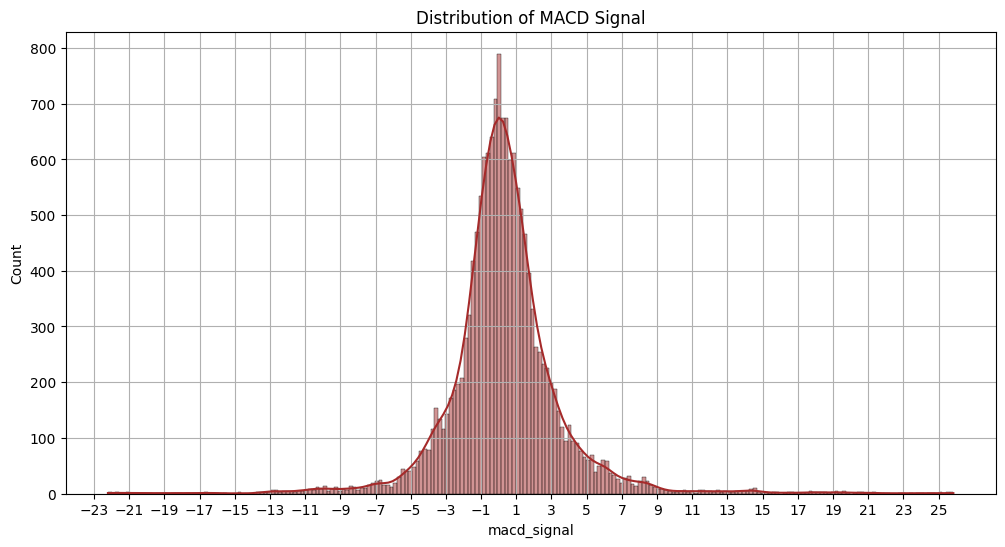

In [155]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['macd_signal'], kde=True, color='brown')
plt.title('Distribution of MACD Signal')
plt.xticks(range(-23,26,2))
plt.grid();

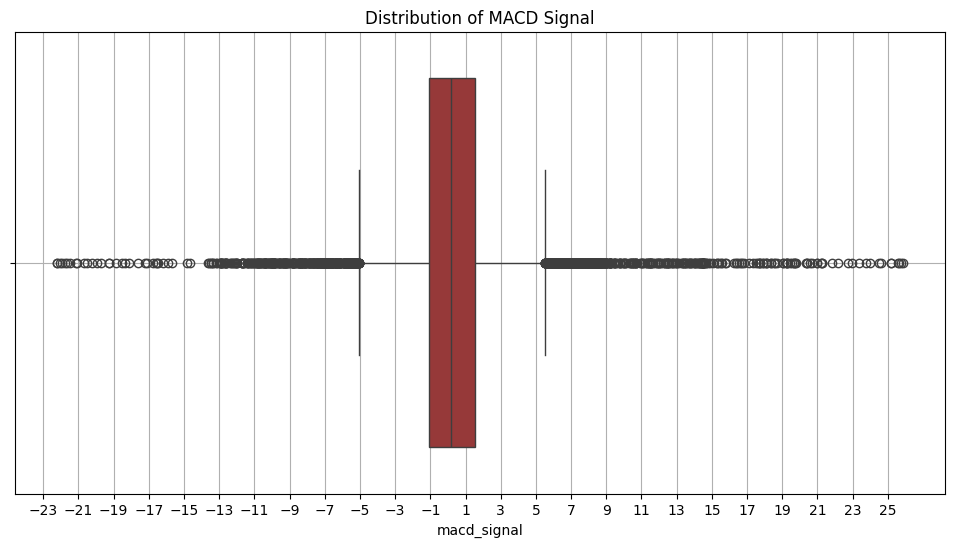

In [157]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['macd_signal'], color='brown', orient='h')
plt.title('Distribution of MACD Signal')
plt.xticks(range(-23,26,2))
plt.grid();

##### MACD Signal has a smaller range compared to MACD which is expected as it is a rolling average of the latter. 

In [158]:
stk_prices_indicators['macd_histogram'].describe()

count    15502.000000
mean         0.001915
std          0.943022
min         -8.019466
25%         -0.407452
50%          0.022291
75%          0.429288
max          7.228006
Name: macd_histogram, dtype: float64

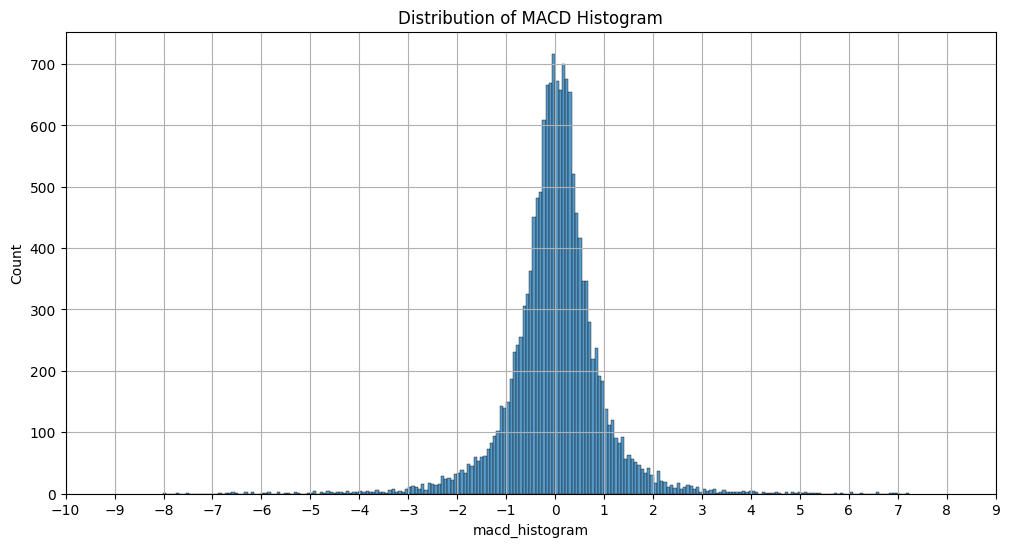

In [163]:
plt.figure(figsize=(12,6))
sns.histplot(data=stk_prices_indicators['macd_histogram'])
plt.title('Distribution of MACD Histogram')
plt.xticks(range(-10,10))
plt.grid();

##### MACD histogram is quite symmetrically distributed around zero with most values concentrated between -3 and 3. 

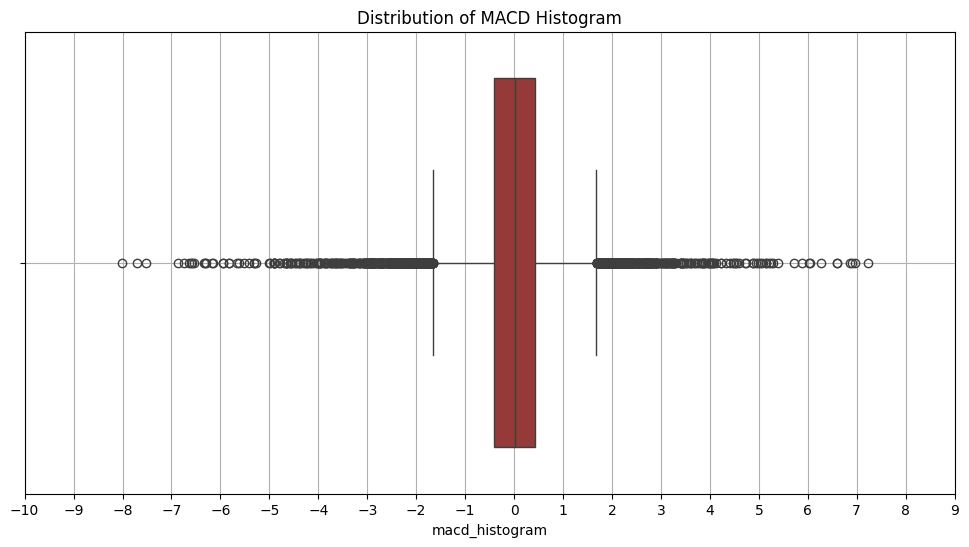

In [164]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['macd_histogram'], orient='h', color='brown')
plt.title('Distribution of MACD Histogram')
plt.xticks(range(-10,10))
plt.grid();

##### There are eminent outliers beyond 2 on both sides of the boxplot for MACD Histogram.

In [166]:
stk_prices_indicators['rsi_14'].describe()

count    15172.000000
mean        51.253335
std         16.777709
min          0.000000
25%         39.669951
50%         51.461079
75%         63.056654
max        100.000000
Name: rsi_14, dtype: float64

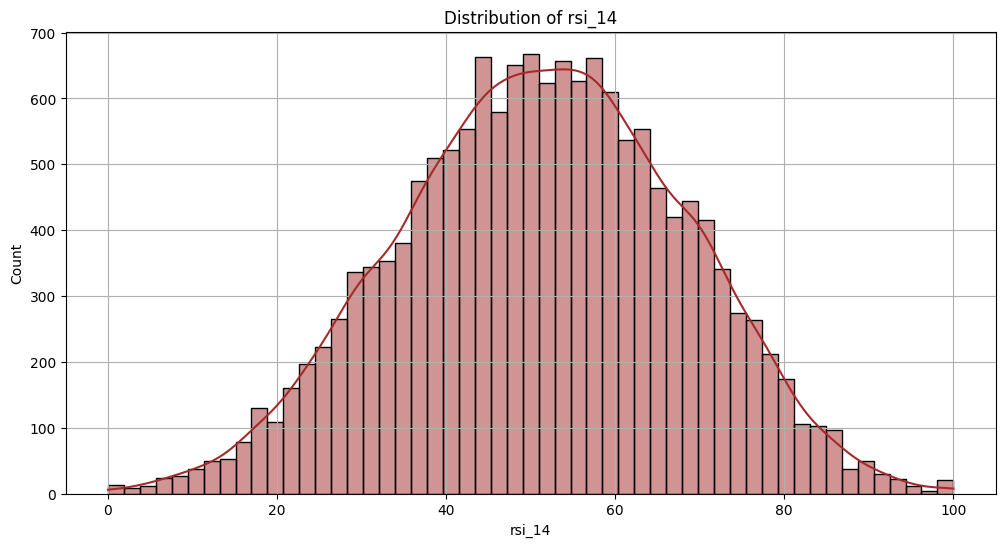

In [168]:
plt.figure(figsize=(12,6))
sns.histplot(stk_prices_indicators['rsi_14'], kde=True, color='brown')
plt.title('Distribution of rsi_14')
plt.grid();

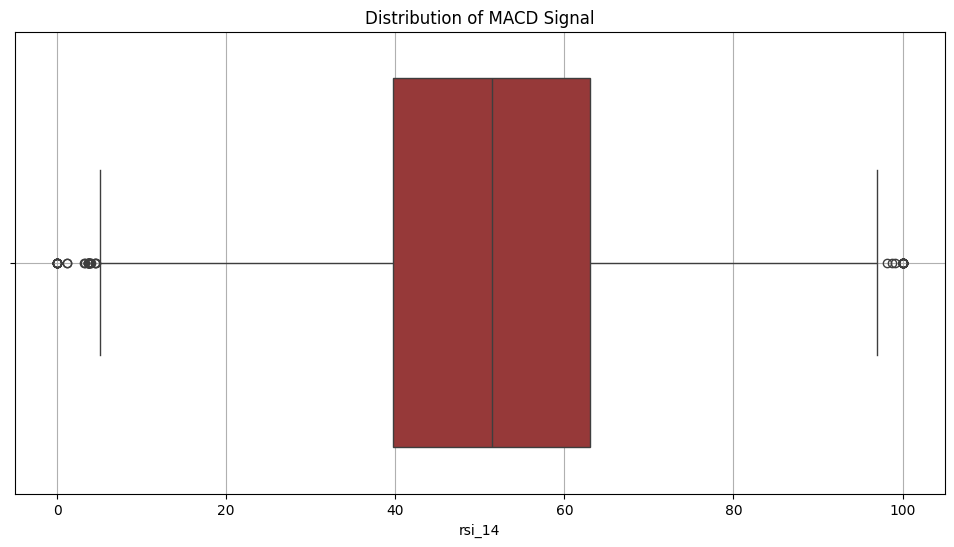

In [171]:
plt.figure(figsize=(12,6))
sns.boxplot(stk_prices_indicators['rsi_14'], orient='h', color='brown')
plt.title('Distribution of MACD Signal')
plt.grid();

##### As expected, rsi_14 sits between 0 and 100 with most values concentrated between 40 and 60. There are a few extremes close to 100 and 0.

In [173]:
stk_prices_indicators['rsi_14'].isnull().sum()

np.int64(330)

In [179]:
#Creating rsi_14 to impute missing values
window = 14

def compute_rsi(series):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

stk_prices_indicators['rsi14_2'] = (
    stk_prices_indicators
    .groupby('ticker')['close']
    .transform(compute_rsi)
)


In [181]:
stk_prices_indicators[['ticker','rsi_14','rsi14_2']].tail(25)

,ticker,rsi_14,rsi14_2
date,,,
2023-11-20,STK020,64.738041,57.233198
2023-11-21,STK020,66.380479,58.248061
2023-11-22,STK020,76.476283,60.577804
2023-11-23,STK020,77.161654,61.937779
2023-11-24,STK020,78.303571,68.601050
2023-11-27,STK020,76.814240,67.854535
2023-11-28,STK020,79.136691,69.121085
2023-11-29,STK020,76.284205,67.996979
2023-11-30,STK020,75.200803,71.521594


##### Computed rsi_14 seems not to match the original rsi_14 column. This could be due to different methods of calculation.This feature would most likely be dropped. 

In [182]:
bb_group = ['bb_middle', 'bb_upper',
       'bb_lower', 'bb_width']

In [190]:
for x in bb_group:
   k =  stk_prices_indicators[x].describe()
   print(f"---{x}---\n{k}\n")


---bb_middle---
count    15502.000000
mean       102.030416
std         57.438542
min         22.808000
25%         62.956500
50%         88.089500
75%        130.386500
max        489.384000
Name: bb_middle, dtype: float64

---bb_upper---
count    15482.000000
mean       110.179010
std         62.608513
min         23.534596
25%         68.279885
50%         94.121356
75%        140.218062
max        514.858490
Name: bb_upper, dtype: float64

---bb_lower---
count    15482.000000
mean        93.899438
std         52.692699
min         20.181625
25%         58.506490
50%         82.377280
75%        119.979094
max        463.909510
Name: bb_lower, dtype: float64

---bb_width---
count    15171.000000
mean        16.282274
std         13.645730
min          0.113137
25%          7.937950
50%         12.344552
75%         19.921944
max        124.994567
Name: bb_width, dtype: float64



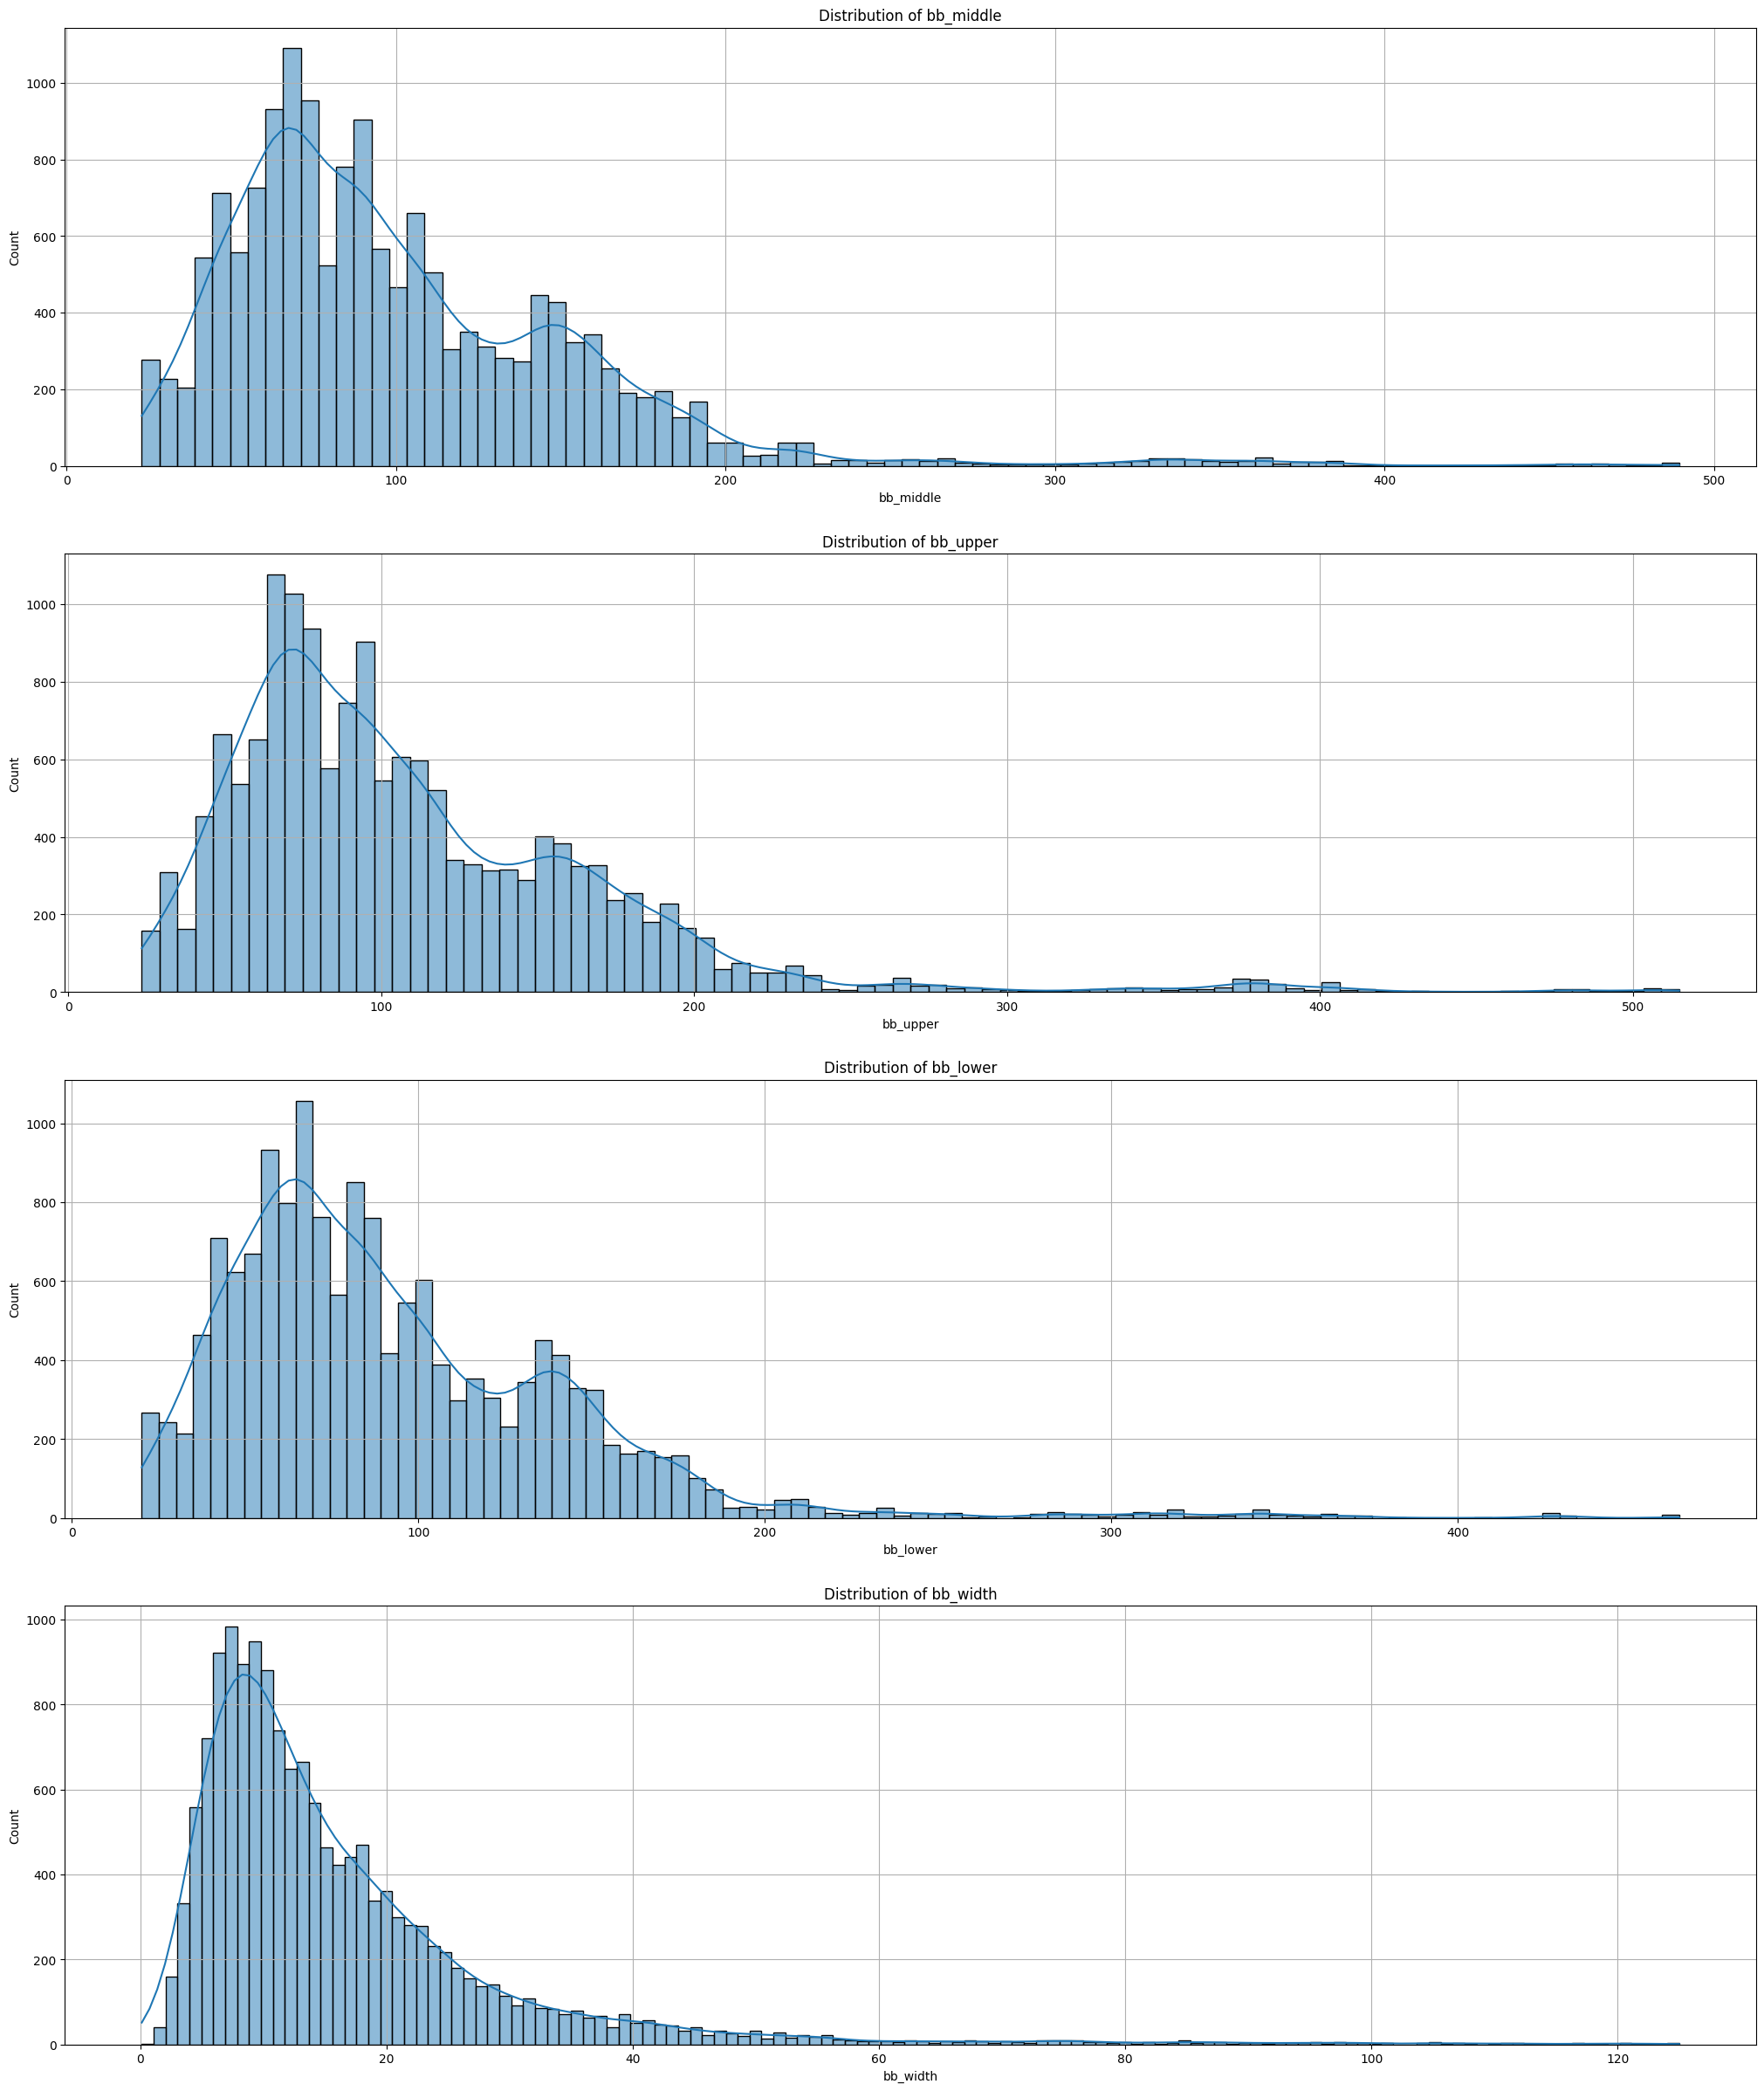

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(25,30))
axs = axs.flatten()
for i, x in enumerate(bb_group):
    sns.histplot(stk_prices_indicators[x], kde=True, ax=axs[i])
    axs[i].set_title(f'Distribution of {x}')
    axs[i].grid();


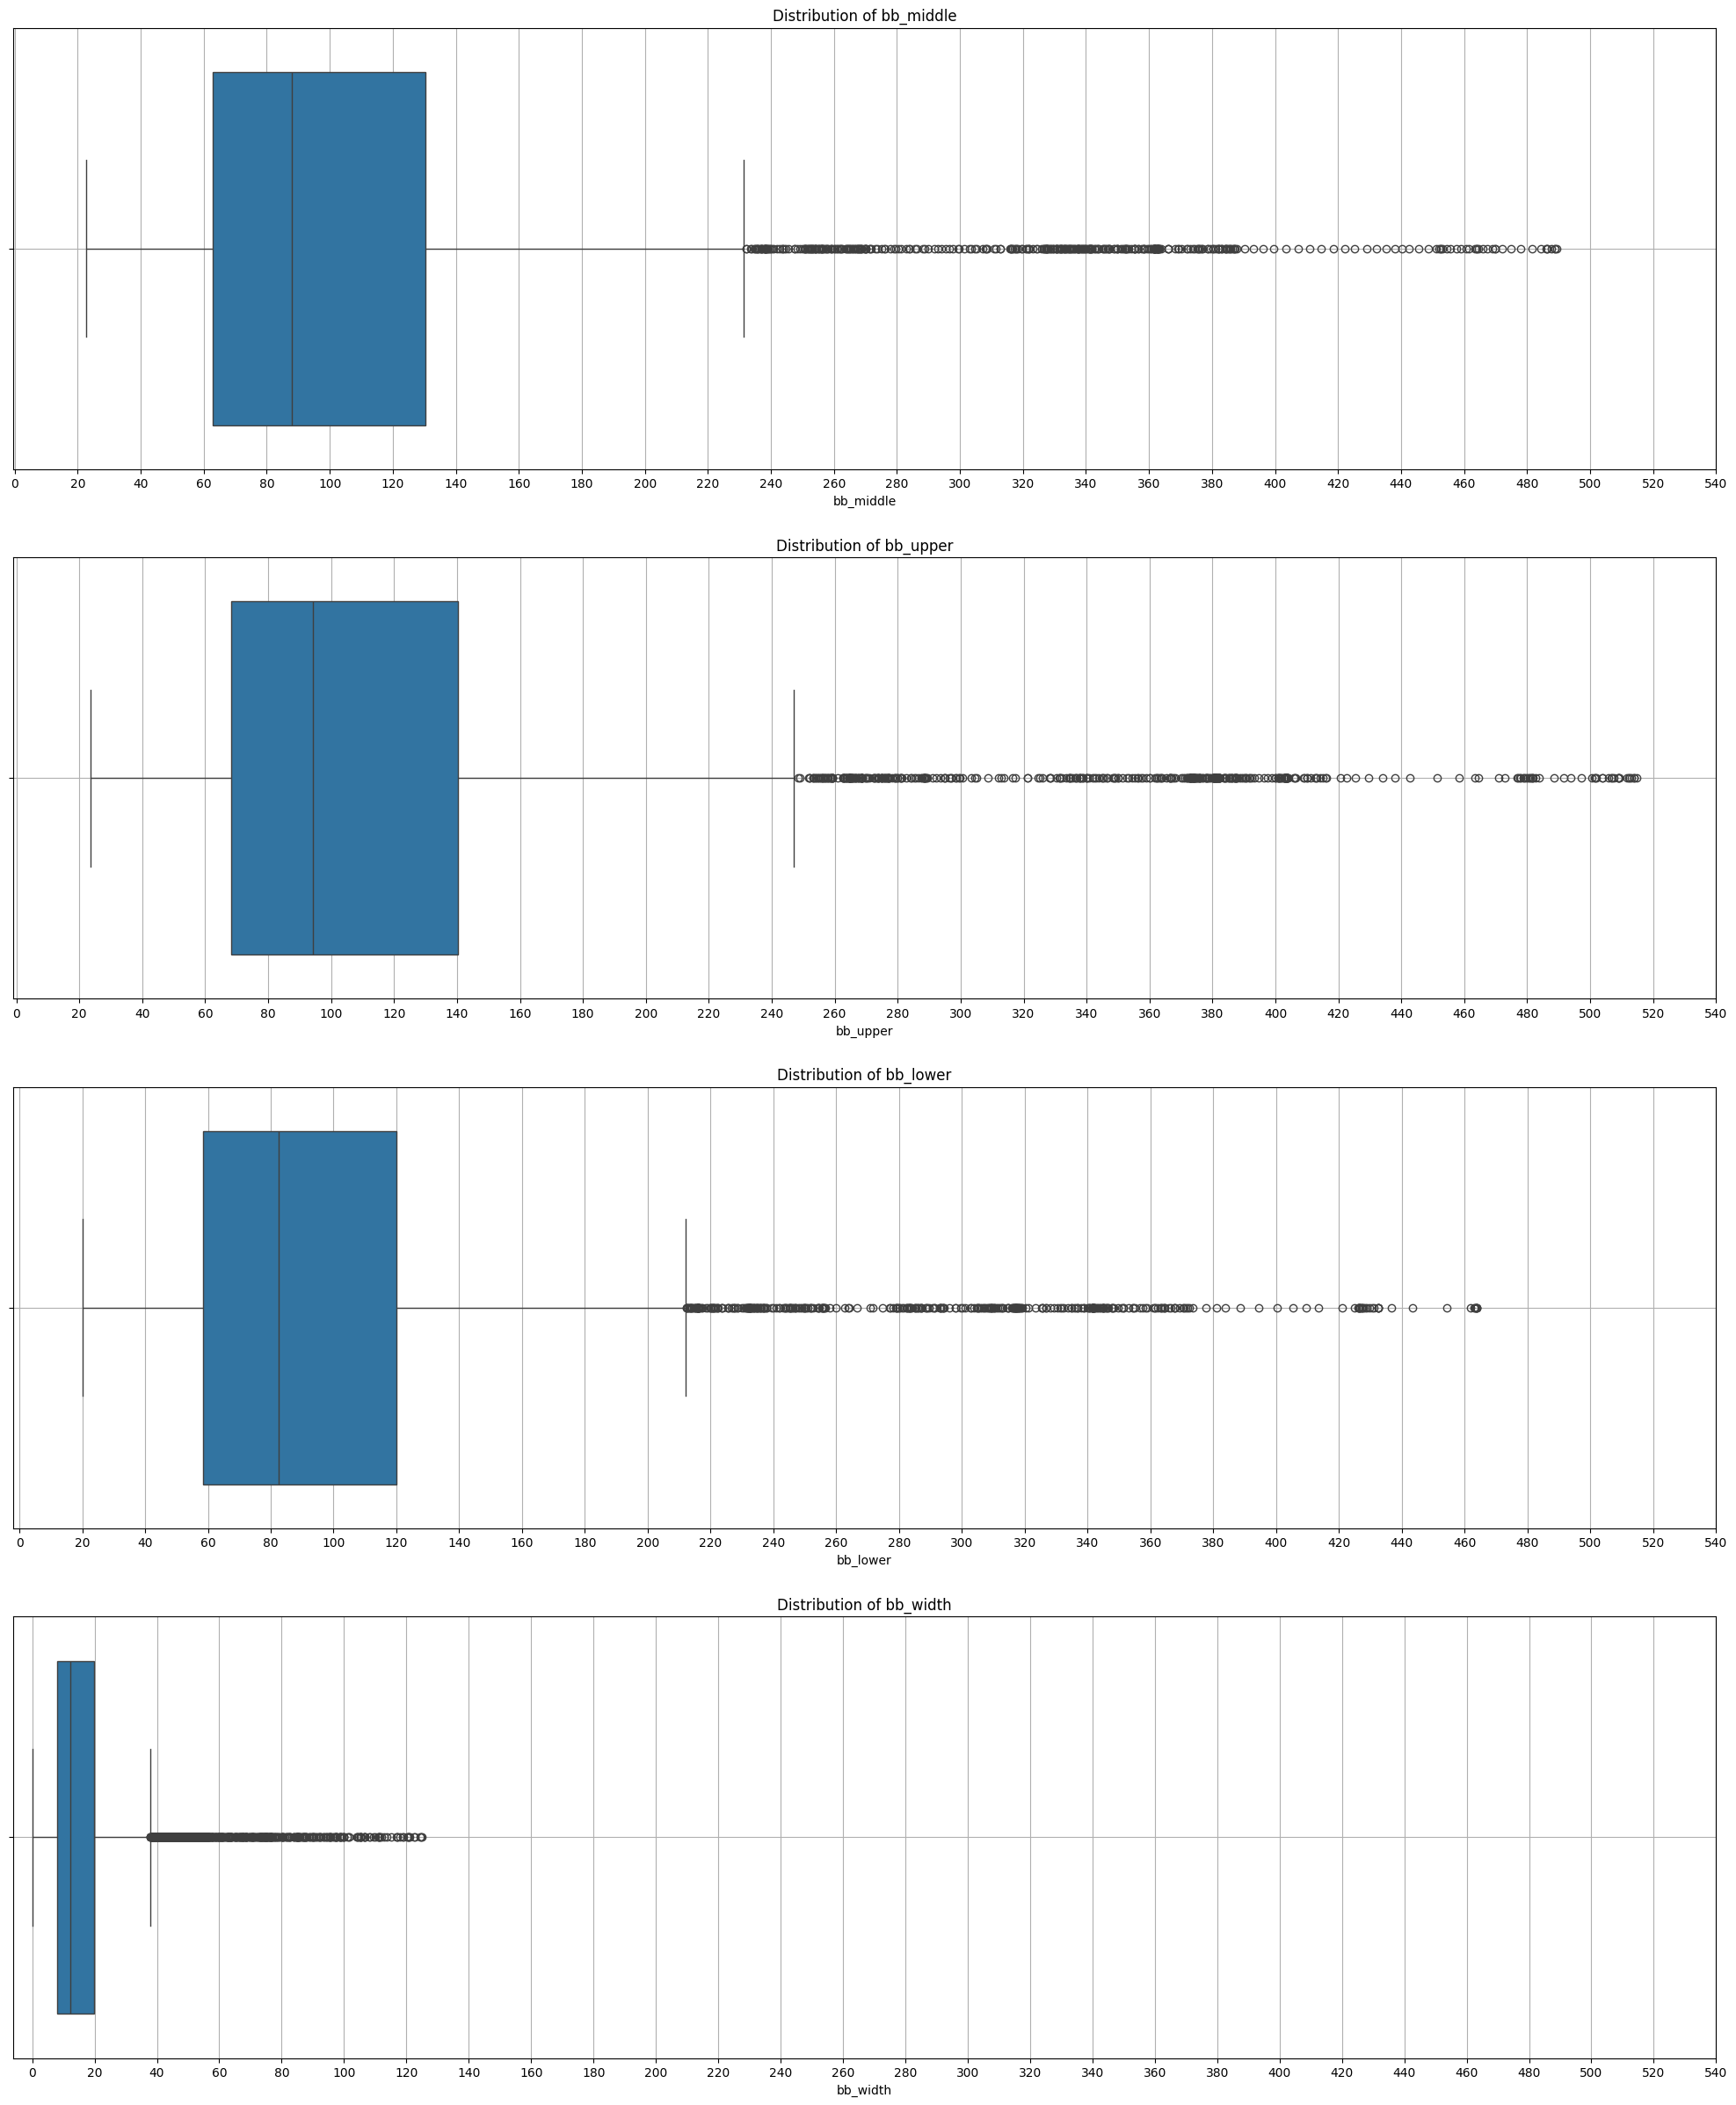

In [197]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(25,30))
axs = axs.flatten()
for i, x in enumerate(bb_group):
    sns.boxplot(stk_prices_indicators[x], orient='h', ax=axs[i])
    axs[i].set_title(f'Distribution of {x}')
    axs[i].set_xticks(range(0,550,20))
    axs[i].grid();


##### Bolinger's Bands (BB) variants are all right skewed and multimodal except BB_Width which has the smallest range among the variables. In all cases, there are outliers at the positive end of the histogram. 

In [198]:
for i in bb_group:
    m = stk_prices_indicators[i].isnull().sum()
    print(f"{i} has {m} missing values")

bb_middle has 0 missing values
bb_upper has 20 missing values
bb_lower has 20 missing values
bb_width has 331 missing values


In [199]:
#Calculating Bolinger's Bands (BB) to impute missing values
num_std = 2 

# rolling std over the same window as your middle band
window = 20  # same window used for your MB
stk_prices_indicators['rolling_std'] = stk_prices_indicators.groupby('ticker')['close'].transform(lambda x: x.rolling(window).std())

# Upper Band
stk_prices_indicators['bb_upper2'] = stk_prices_indicators['bb_middle'] + num_std * stk_prices_indicators['rolling_std']

# Lower Band
stk_prices_indicators['bb_lower2'] = stk_prices_indicators['bb_middle'] - num_std * stk_prices_indicators['rolling_std']


In [206]:
stk_prices_indicators['bb_width2'] = stk_prices_indicators['bb_upper'] - stk_prices_indicators['bb_lower']


In [208]:
stk_prices_indicators[['ticker', 'bb_middle', 'bb_upper',
       'bb_lower', 'bb_width', 'bb_upper2', 'bb_lower2', 'bb_width2']].head(40)

,ticker,bb_middle,bb_upper,bb_lower,bb_width,bb_upper2,bb_lower2,bb_width2
date,,,,,,,,
2021-01-04,STK001,160.110000,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,STK001,161.235000,164.416981,158.053019,6.363961,NaN,NaN,6.363961
2021-01-06,STK001,161.416667,163.753017,159.080316,4.672701,NaN,NaN,4.672701
2021-01-07,STK001,162.830000,168.796507,156.863493,11.933013,NaN,NaN,11.933013
2021-01-08,STK001,163.400000,169.161718,157.638282,11.523437,NaN,NaN,11.523437
2021-01-11,STK001,163.555000,168.764081,158.345919,10.418161,NaN,NaN,10.418161
2021-01-12,STK001,163.805714,168.742526,158.868902,9.873624,NaN,NaN,9.873624
2021-01-13,STK001,163.303750,168.684583,157.922917,10.761666,NaN,NaN,10.761666
2021-01-14,STK001,162.572222,169.250469,155.893976,13.356493,NaN,NaN,13.356493


In [209]:
bb_group2 = ['bb_upper2', 'bb_lower2', 'bb_width2']

##### Although computing BB gave similar results, the absence of prior data points for the rolling calculations meant that the missing values in the original columns could not be fully imputed. As such, the computed BB columns also have missing values. BB width however shows promising signs and will be used to fill the Nulls. 

In [212]:
stk_prices_indicators[['ticker', 'bb_width', 'bb_width2']].head(40)

,ticker,bb_width,bb_width2
date,,,
2021-01-04,STK001,NaN,NaN
2021-01-05,STK001,6.363961,6.363961
2021-01-06,STK001,4.672701,4.672701
2021-01-07,STK001,11.933013,11.933013
2021-01-08,STK001,11.523437,11.523437
2021-01-11,STK001,10.418161,10.418161
2021-01-12,STK001,9.873624,9.873624
2021-01-13,STK001,10.761666,10.761666
2021-01-14,STK001,13.356493,13.356493


In [213]:
stk_prices_indicators['bb_width'].fillna(stk_prices_indicators['bb_width2'], inplace=True)

C:\Users\ofori\AppData\Local\Temp\ipykernel_9112\786052167.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  stk_prices_indicators['bb_width'].fillna(stk_prices_indicators['bb_width2'], inplace=True)


In [214]:
stk_prices_indicators['bb_width'].isnull().sum()

np.int64(20)

#### The null values in bb_width have been successfully filled using the computed bb_width2 column.

In [222]:
tr = ['true_range', 'atr_14']

In [223]:
for i in tr:
    m = stk_prices_indicators[i].describe()
    print(f"---{i}---\n{m}\n")

---true_range---
count    15502.000000
mean         3.731157
std          2.904011
min          0.270000
25%          1.870000
50%          2.970000
75%          4.620000
max         39.530000
Name: true_range, dtype: float64

---atr_14---
count    15502.000000
mean         3.718369
std          2.330653
min          0.650000
25%          2.158571
50%          3.128929
75%          4.653571
max         19.738571
Name: atr_14, dtype: float64



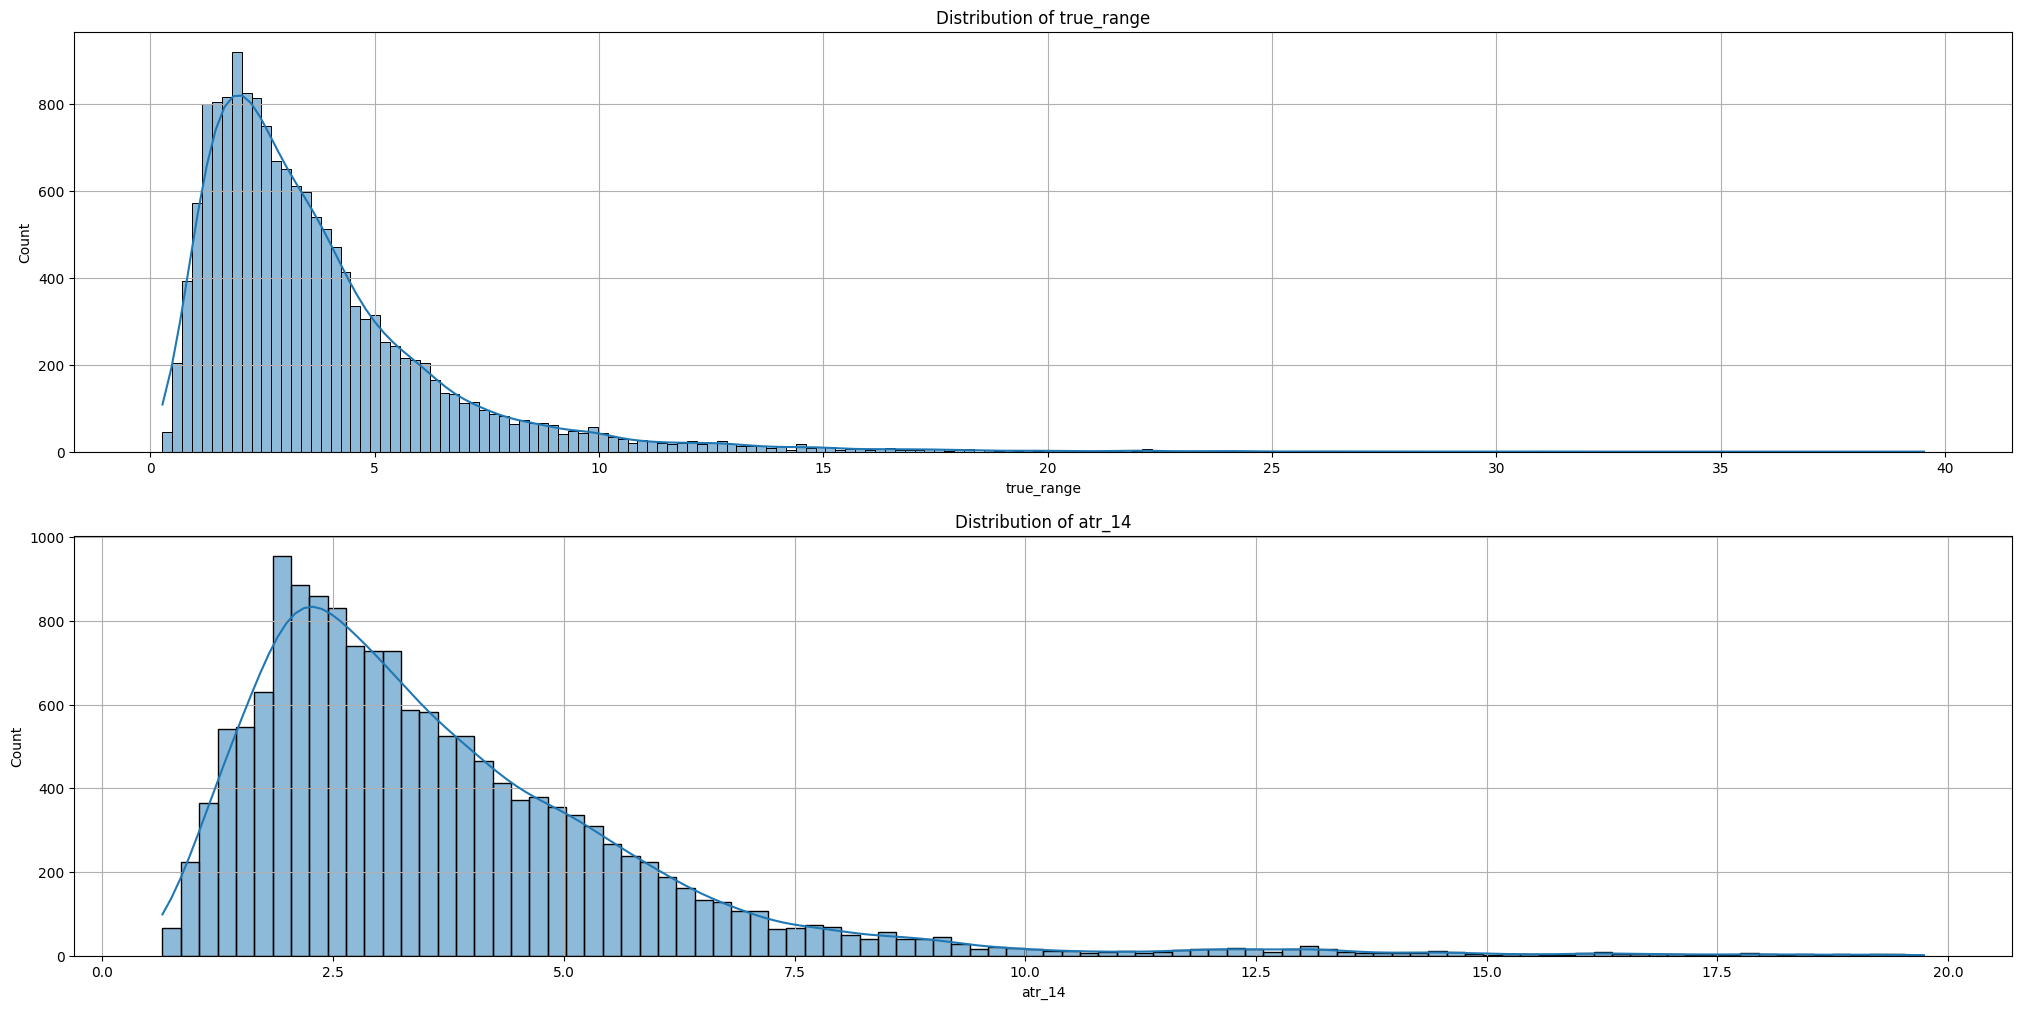

In [224]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(25,12))
axs = axs.flatten()

for i in tr:
    sns.histplot(stk_prices_indicators[i], kde=True, ax=axs[tr.index(i)])
    axs[tr.index(i)].set_title(f'Distribution of {i}')
    axs[tr.index(i)].grid();

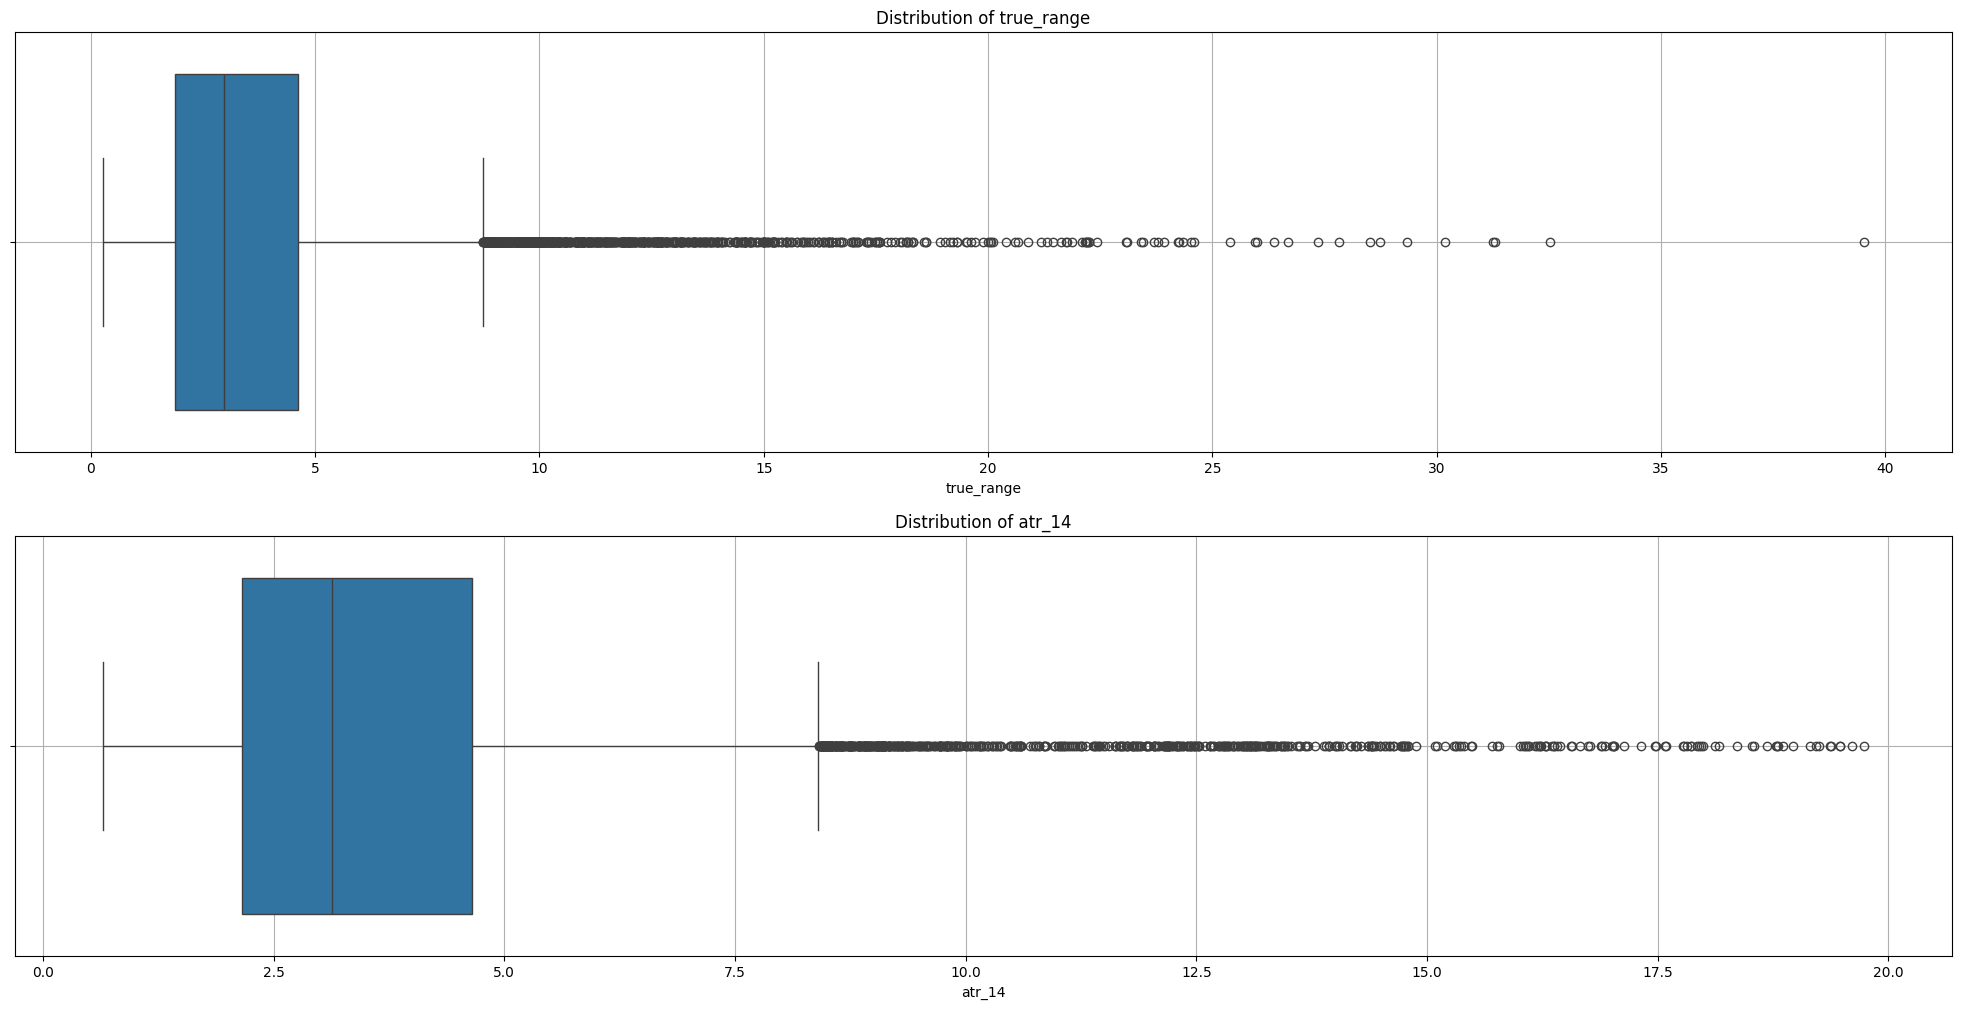

In [226]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(25,12))
axs = axs.flatten()

for i in tr:
    sns.boxplot(stk_prices_indicators[i], ax=axs[tr.index(i)], orient='h')
    axs[tr.index(i)].set_title(f'Distribution of {i}')
    axs[tr.index(i)].grid();

In [217]:
stk_prices_indicators['true_range'].isnull().sum()

np.int64(0)

In [227]:
stk_prices_indicators['atr_14'].isnull().sum()

np.int64(0)

##### The true range data is skewed to the right, with most values concentrated at the lower end of the scale. While average true range has a lower average and max values, as expected, it affirms that, averagely, overnight gaps in prices across the years have been quite minimal with evident outliers in certain cases.

In [159]:
stk_prices_indicators.columns

Index(['ticker', 'open', 'high', 'low', 'close', 'volume', 'adjusted_close',
       'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd',
       'macd_signal', 'macd_histogram', 'rsi_14', 'bb_middle', 'bb_upper',
       'bb_lower', 'bb_width', 'true_range', 'atr_14', 'volume_sma_20',
       'volume_ratio', 'momentum_10', 'momentum_20', 'price_to_sma_50',
       'volatility_20', 'future_return_5d', 'trend_label', 'Year', 'Month',
       'Day', 'mnth_yr', 'SMA20'],
      dtype='object')

In [ ]:
stk_prices_indicators['close'].resample('M').mean().plot(figsize=(12,6))

C:\Users\ofori\AppData\Local\Temp\ipykernel_18816\67523363.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


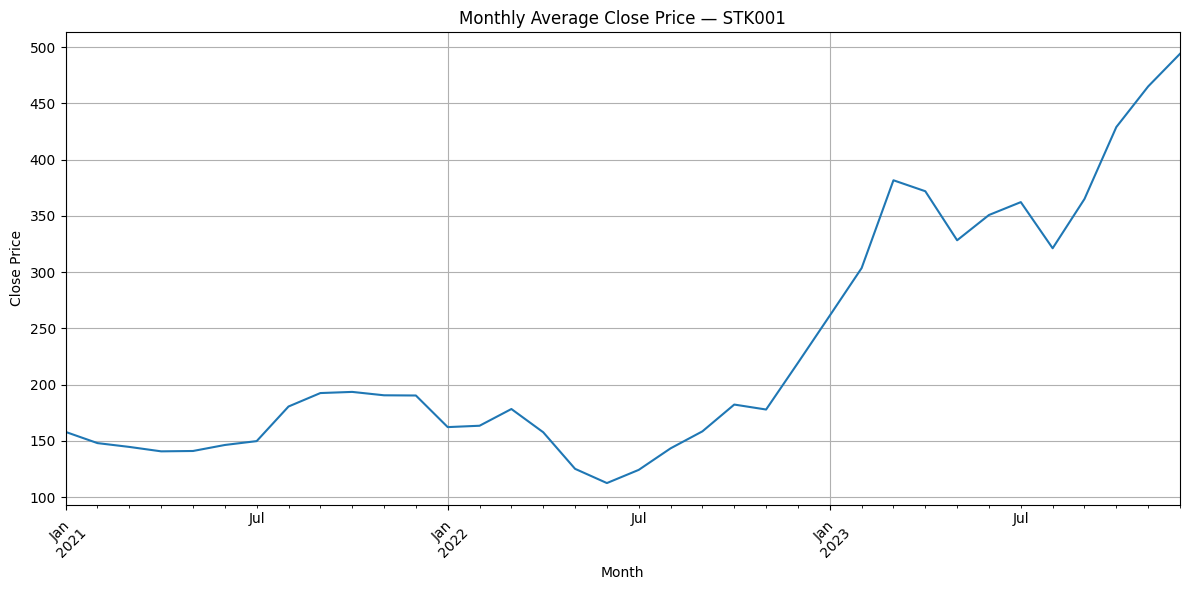

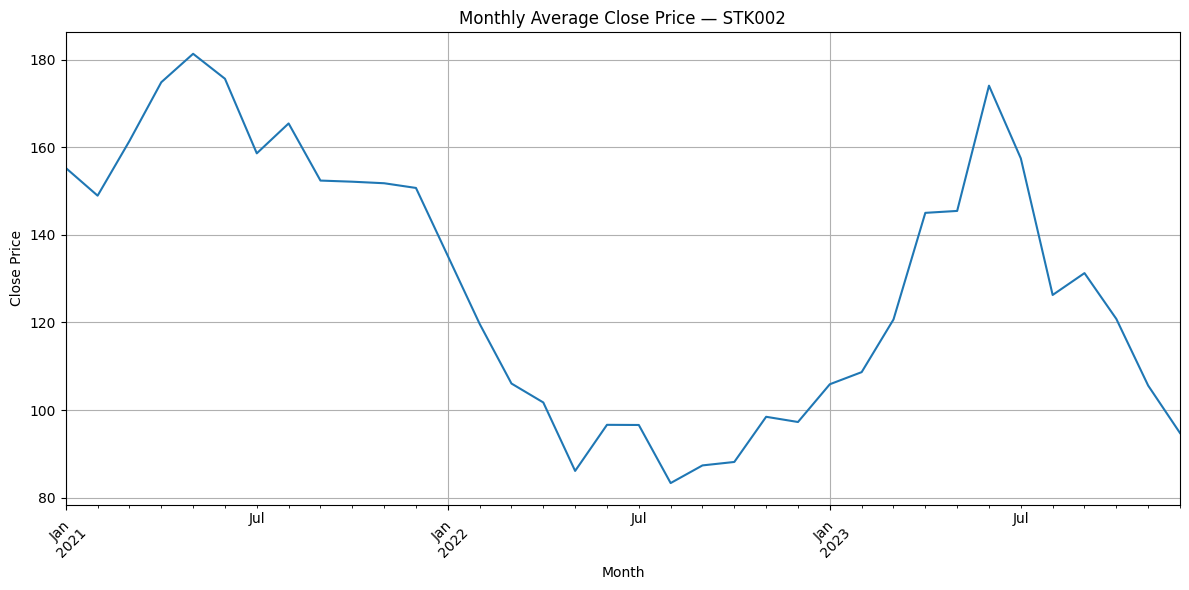

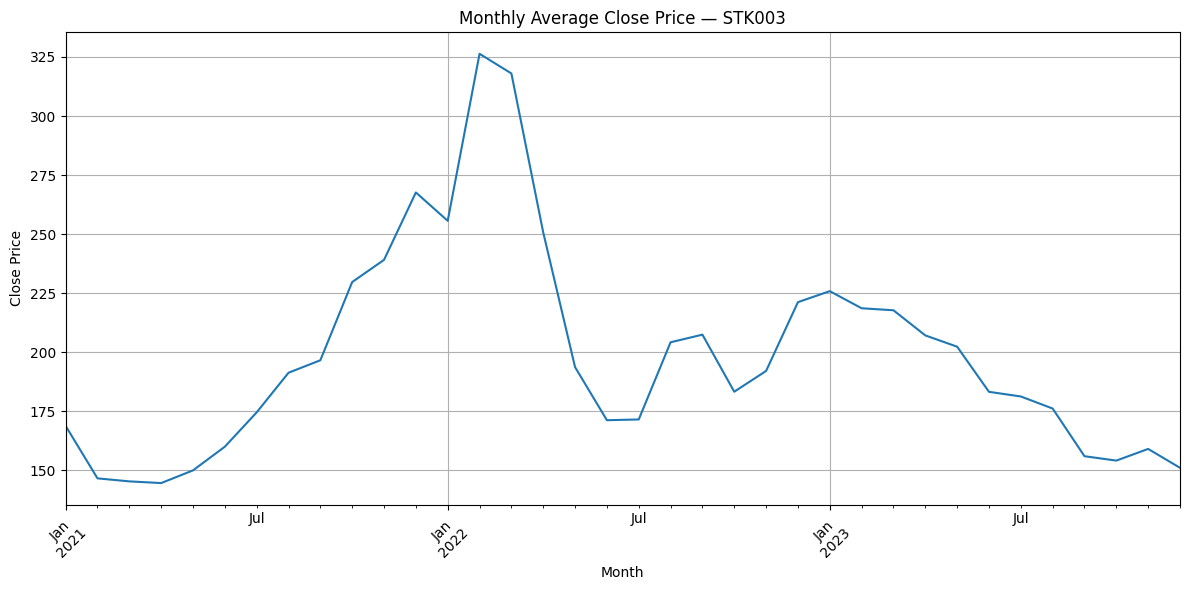

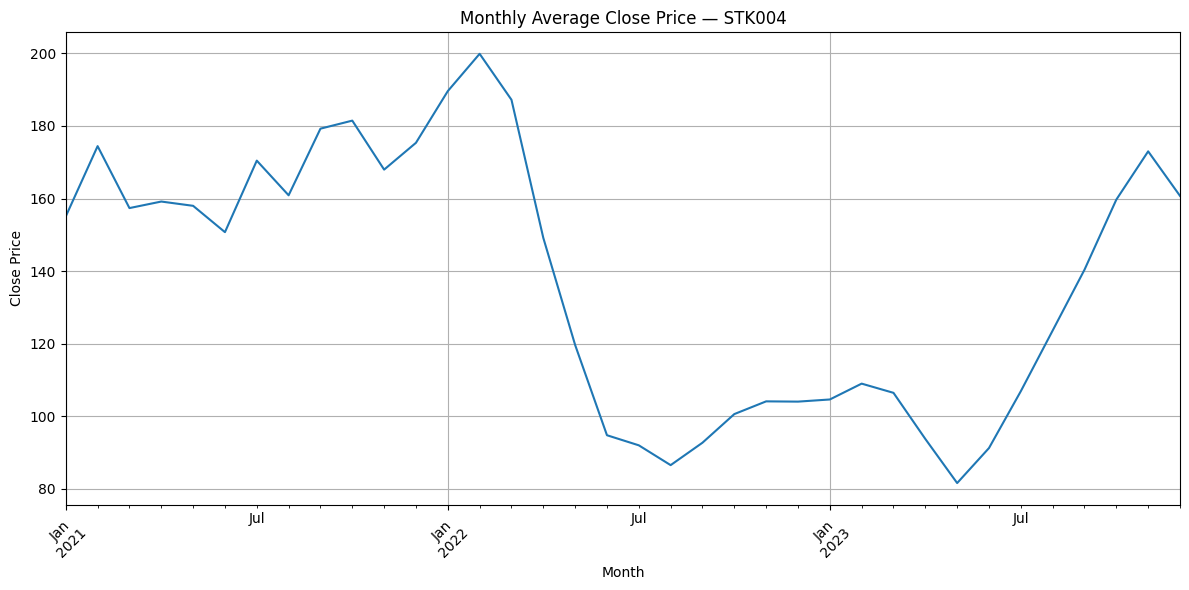

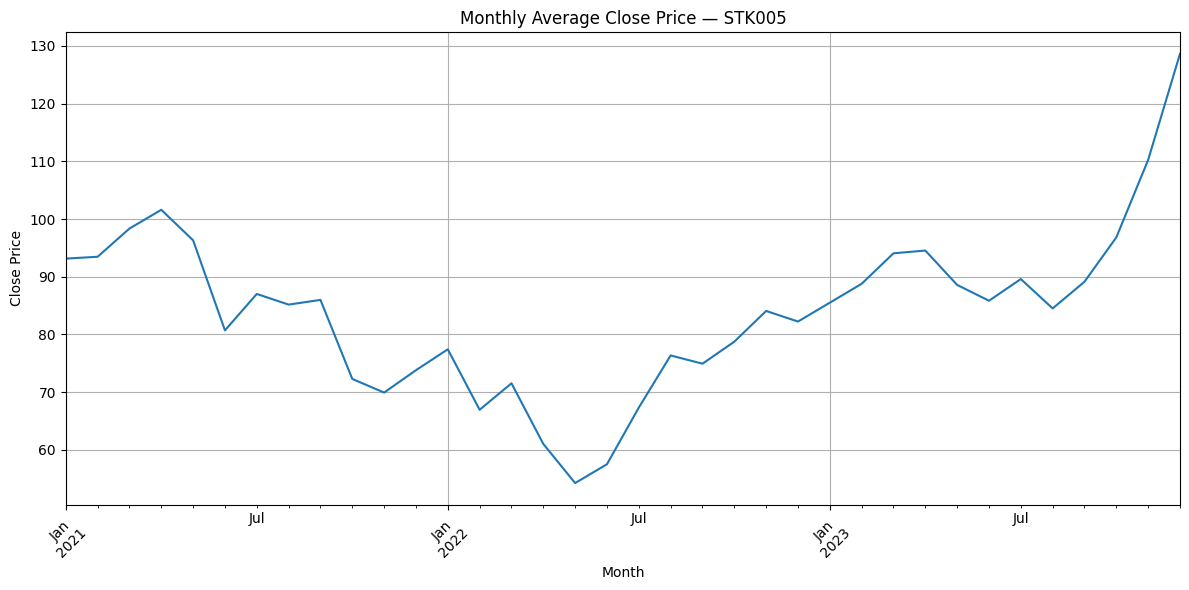

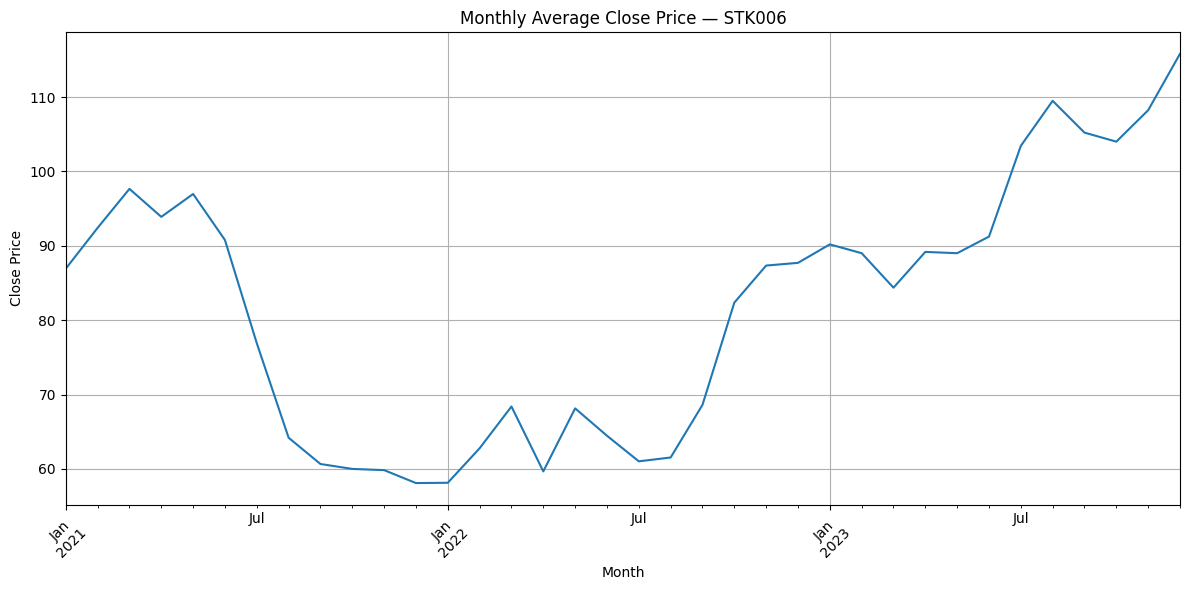

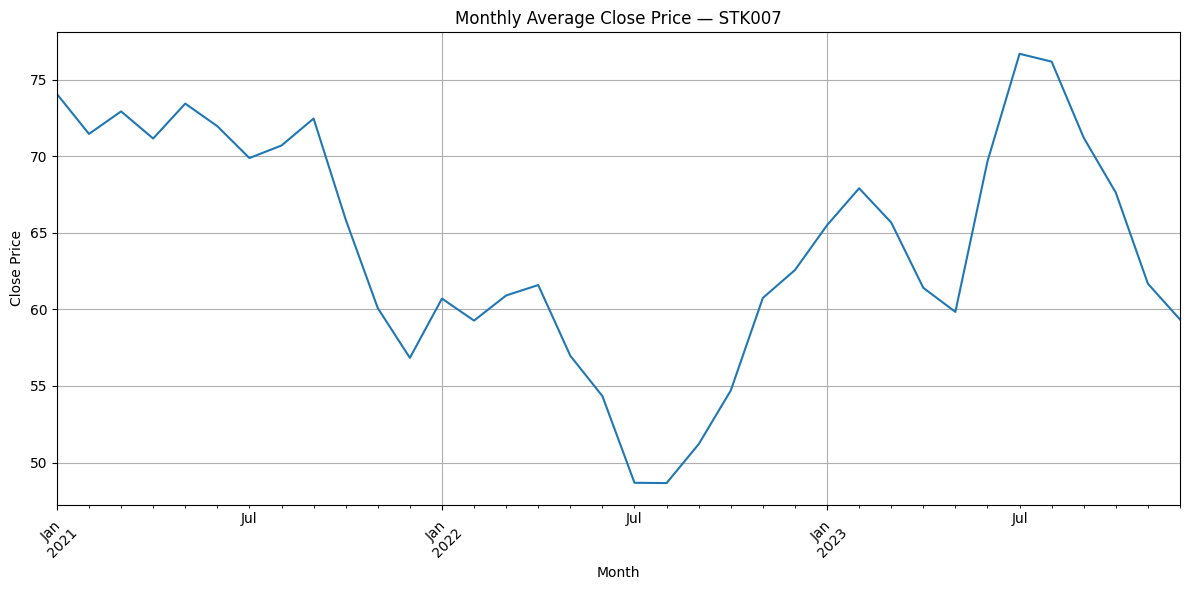

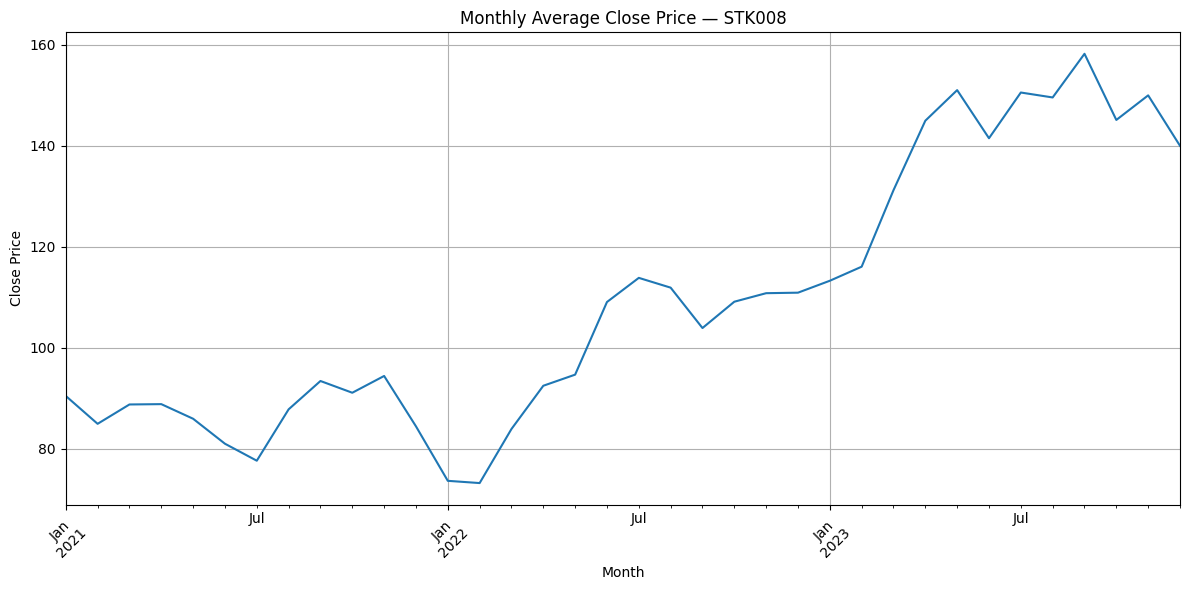

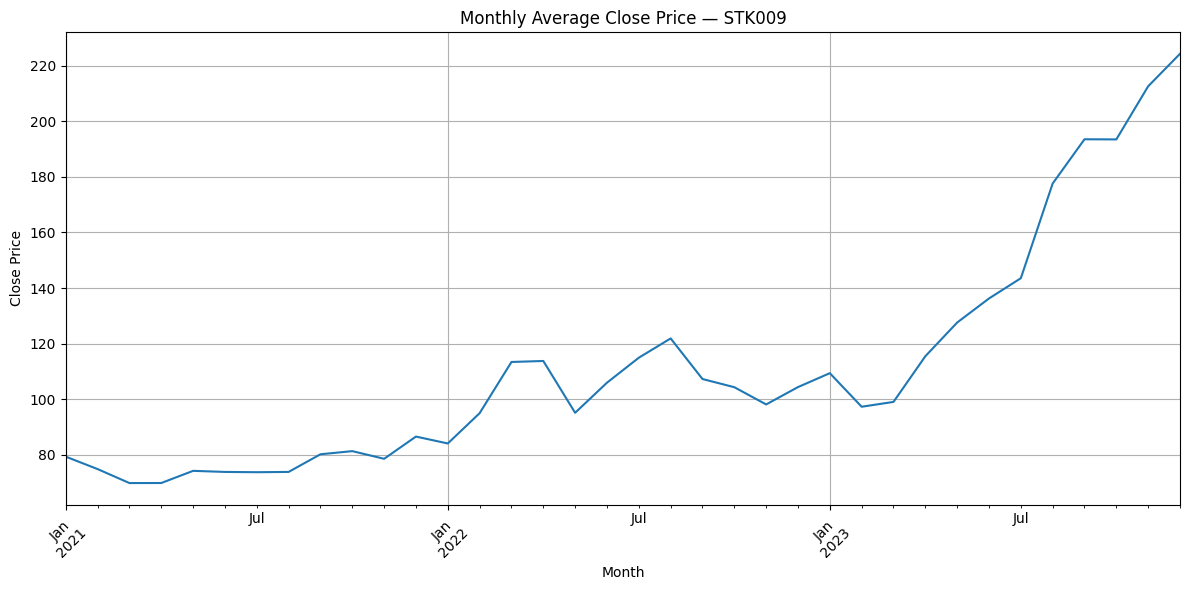

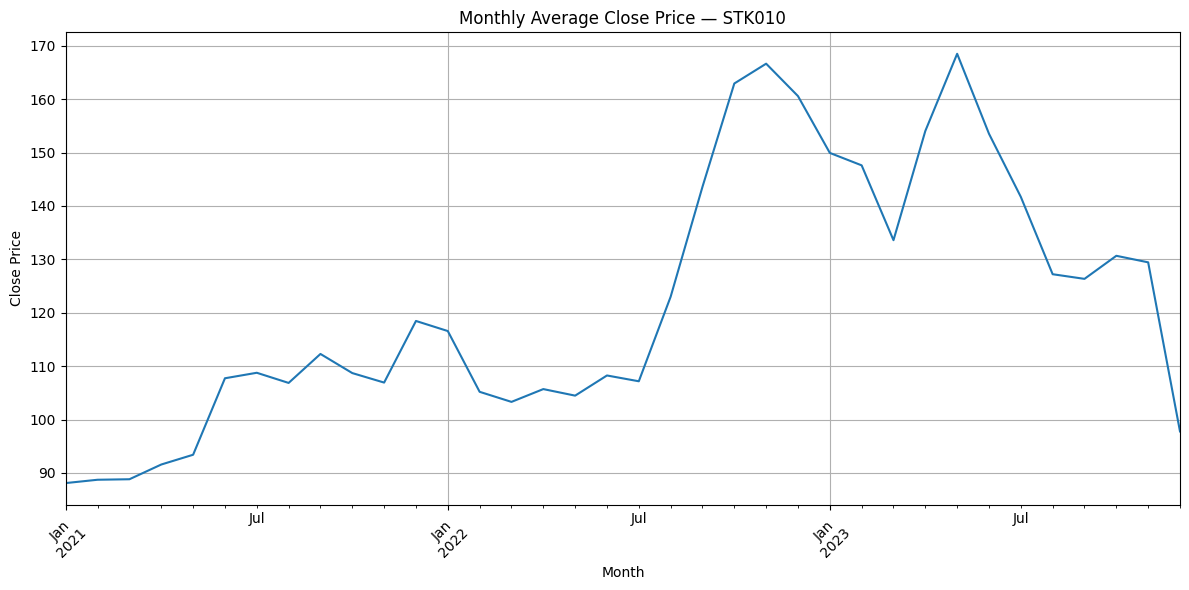

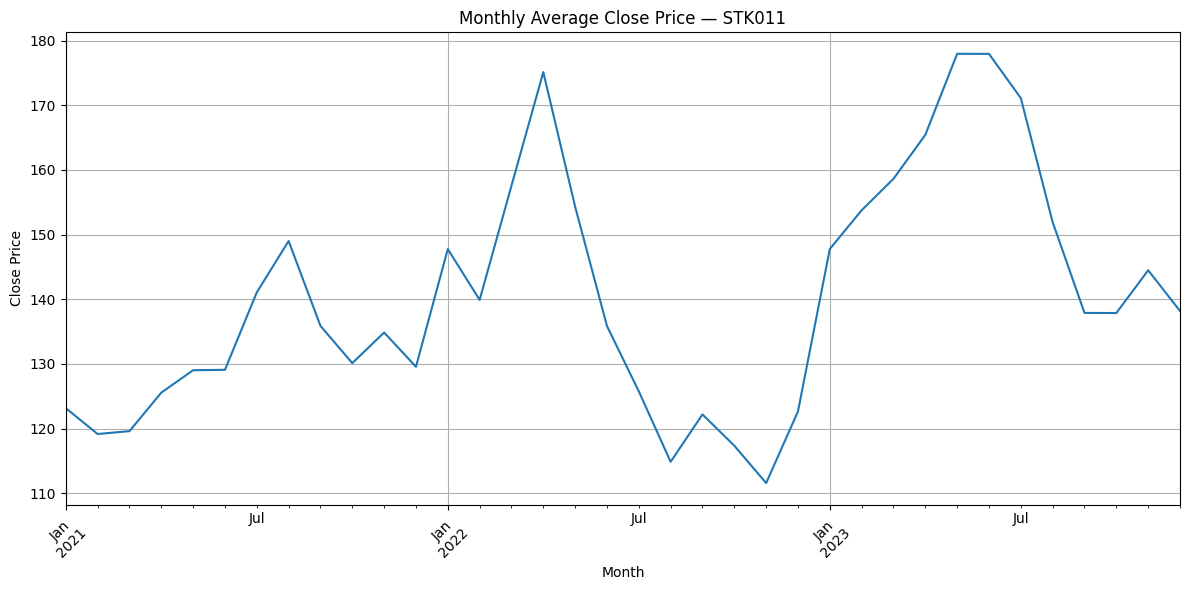

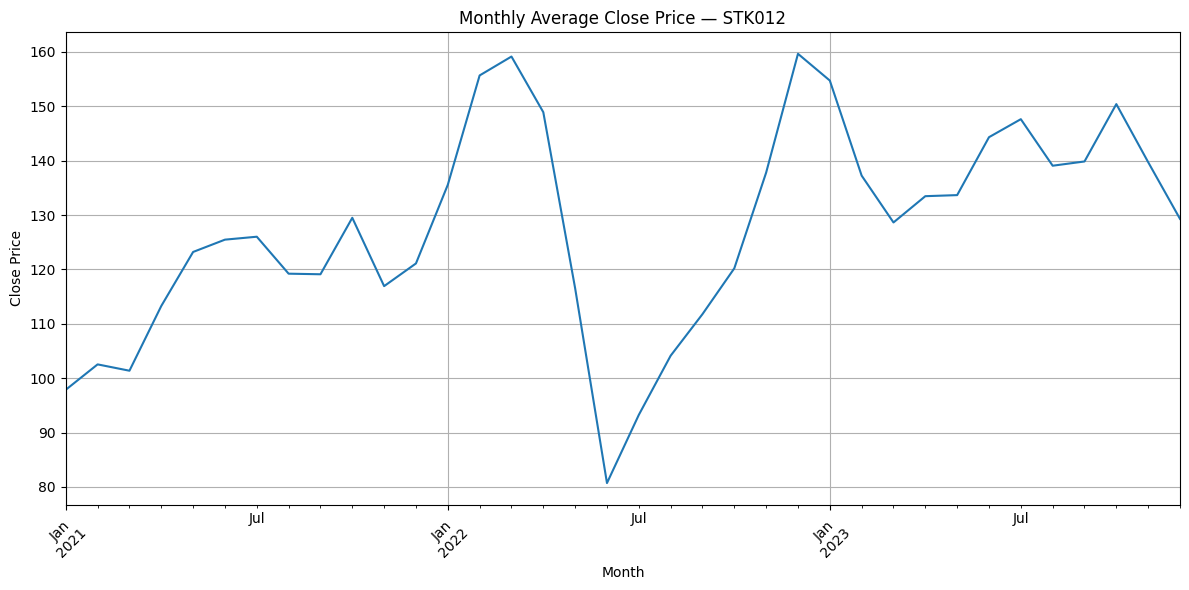

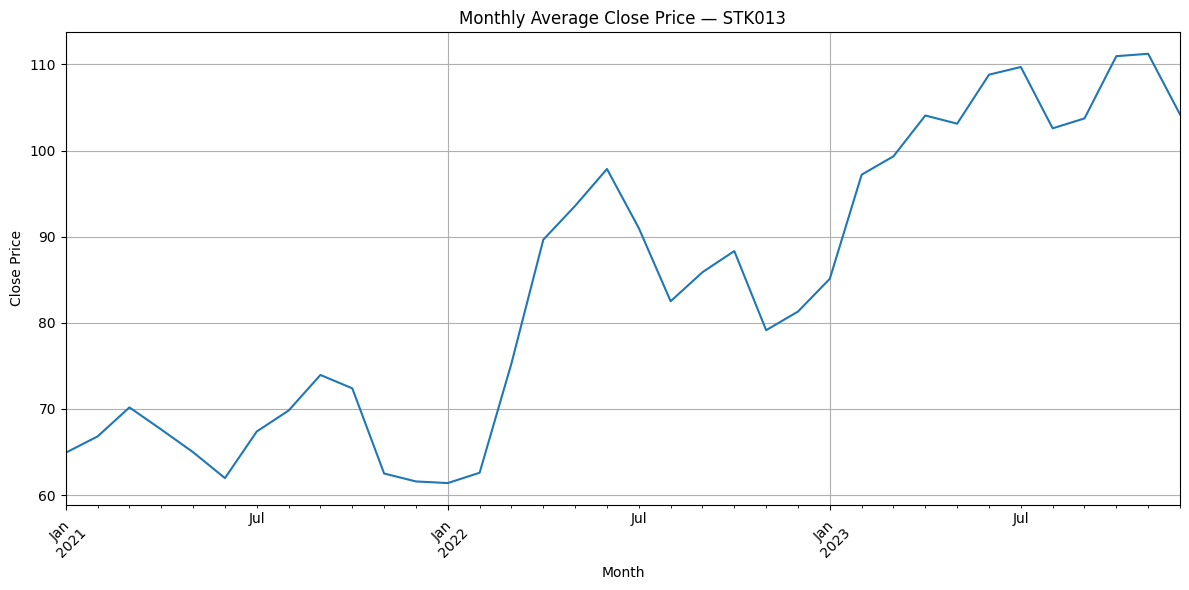

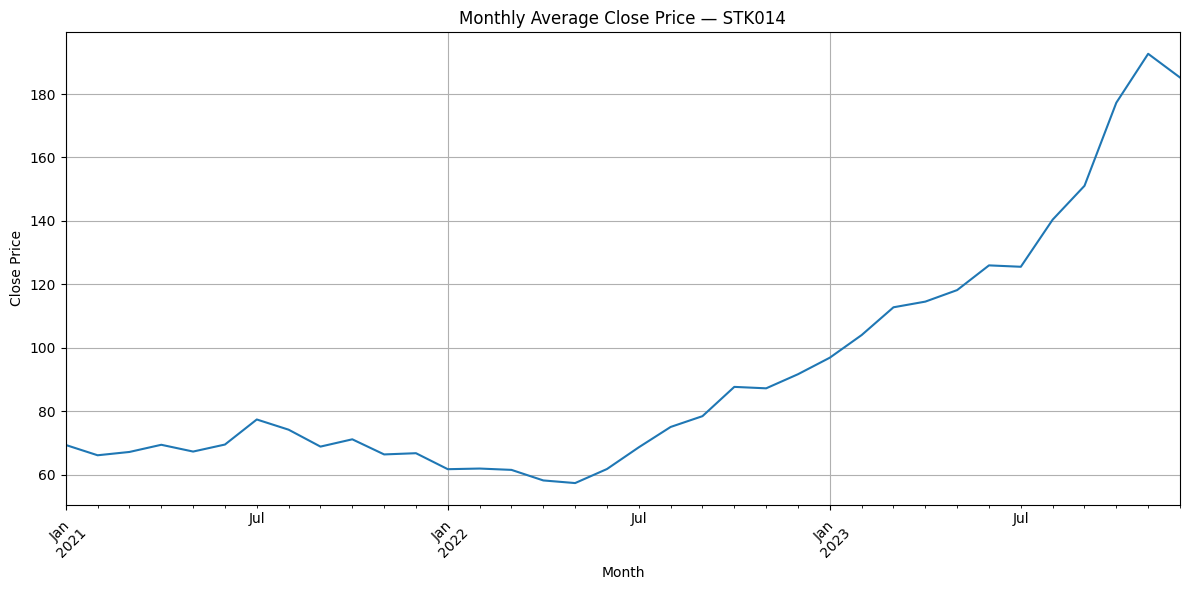

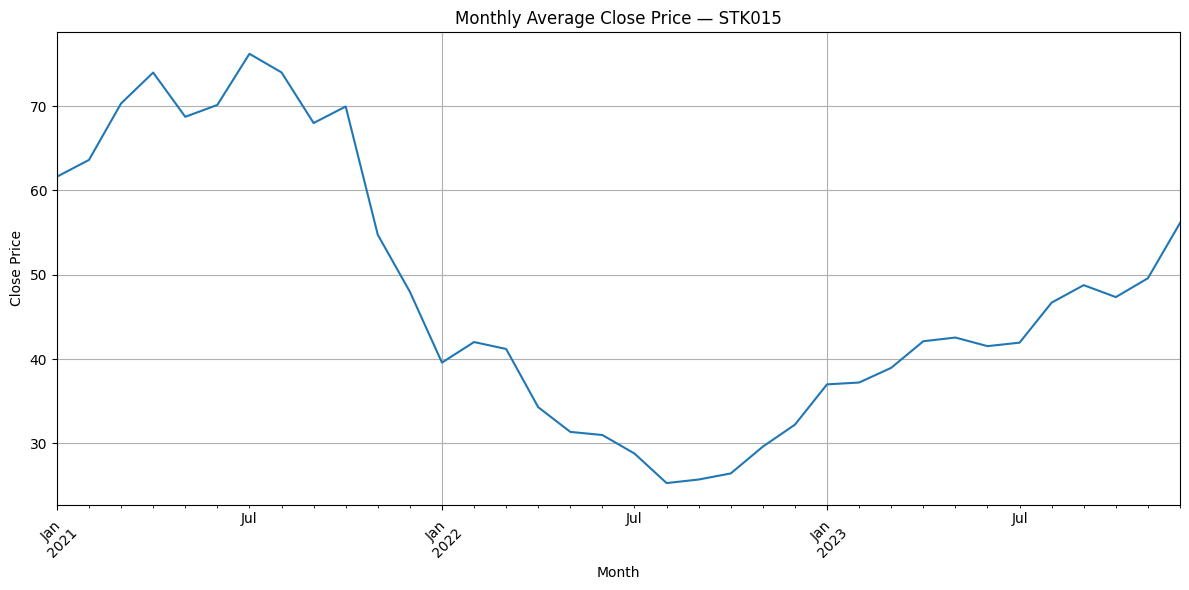

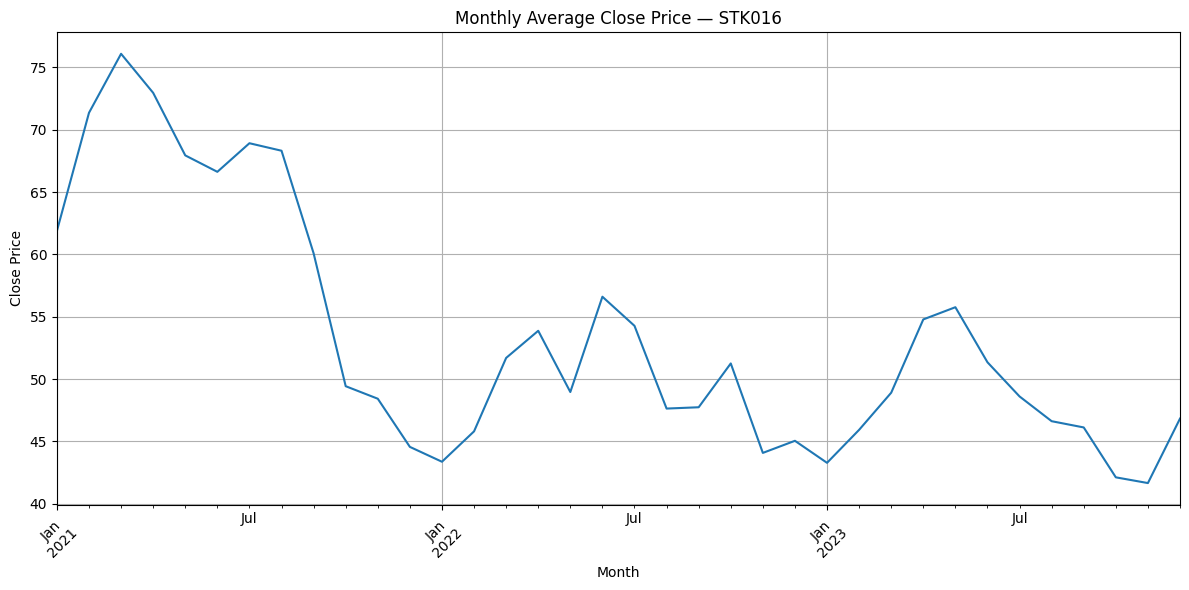

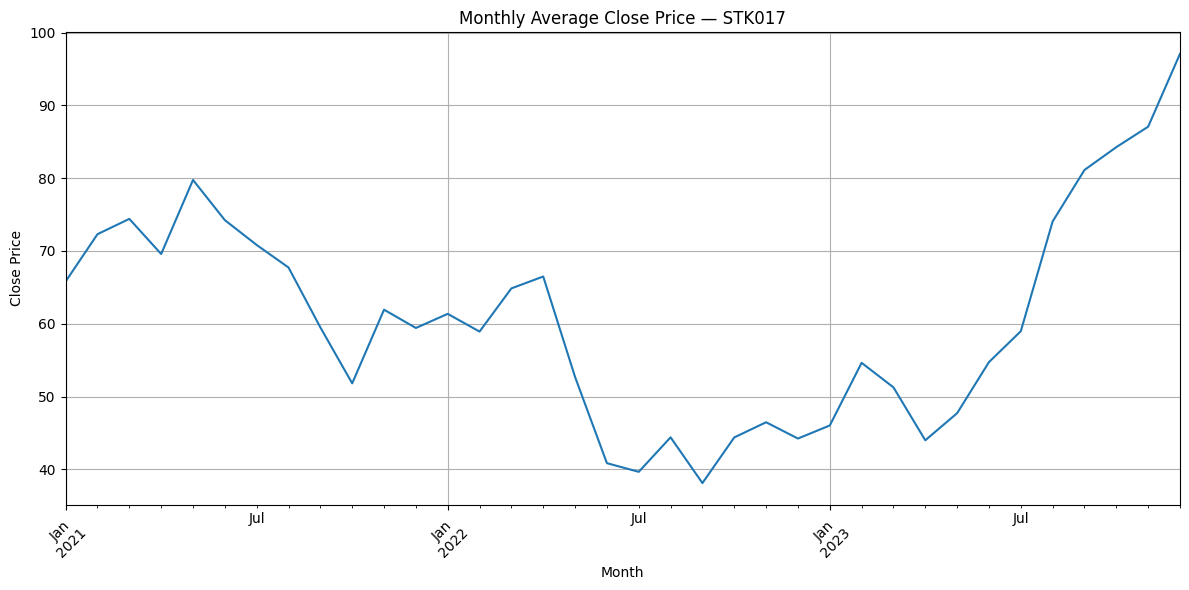

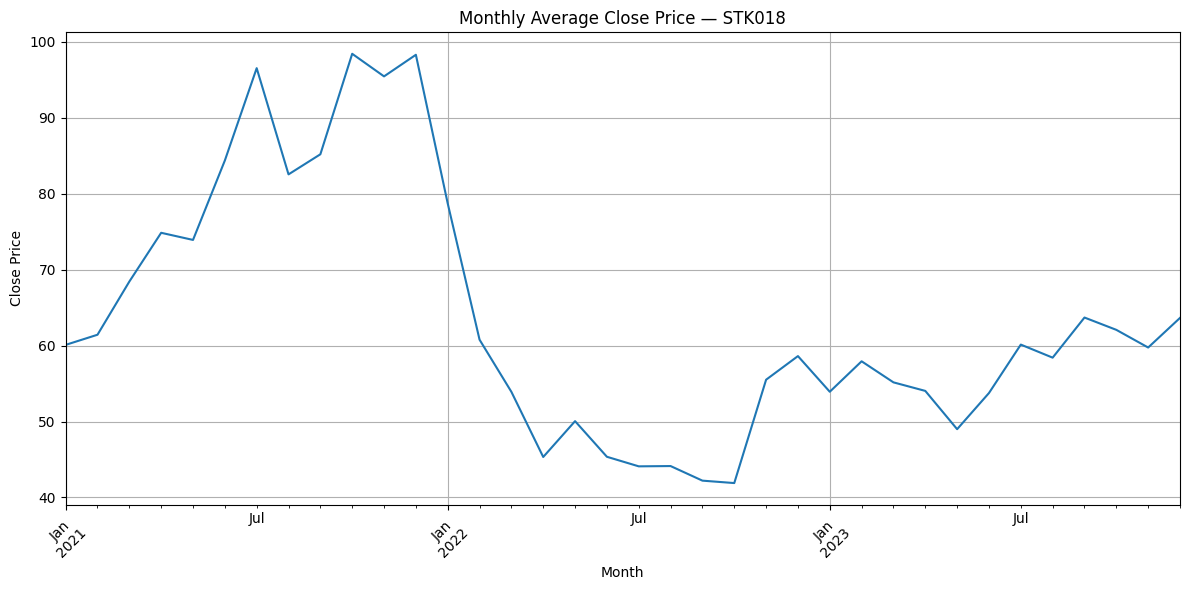

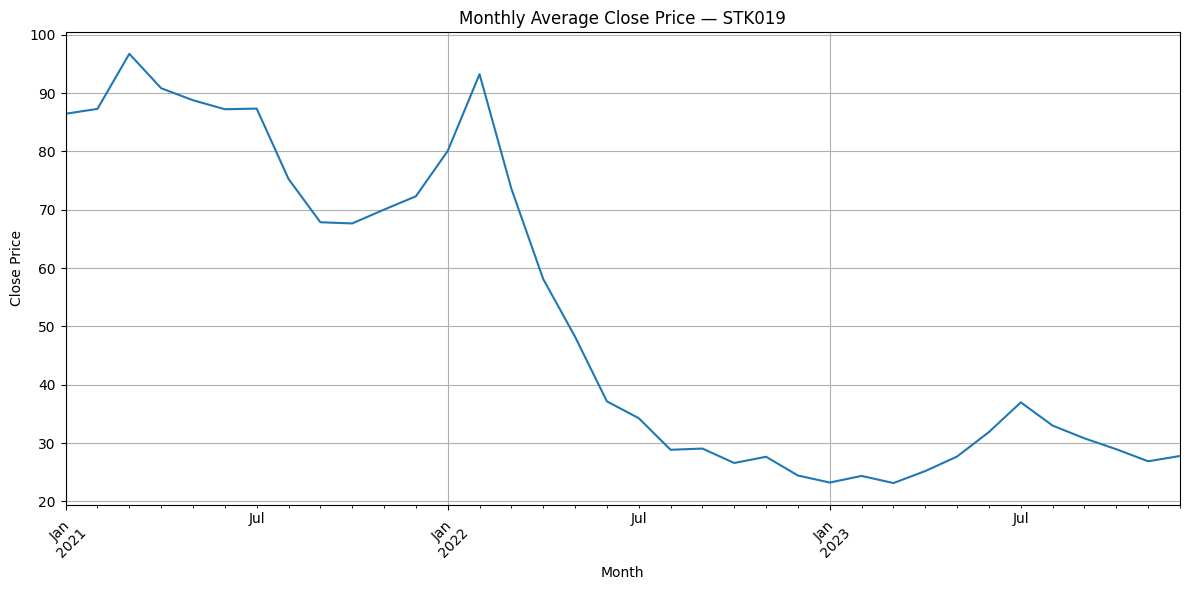

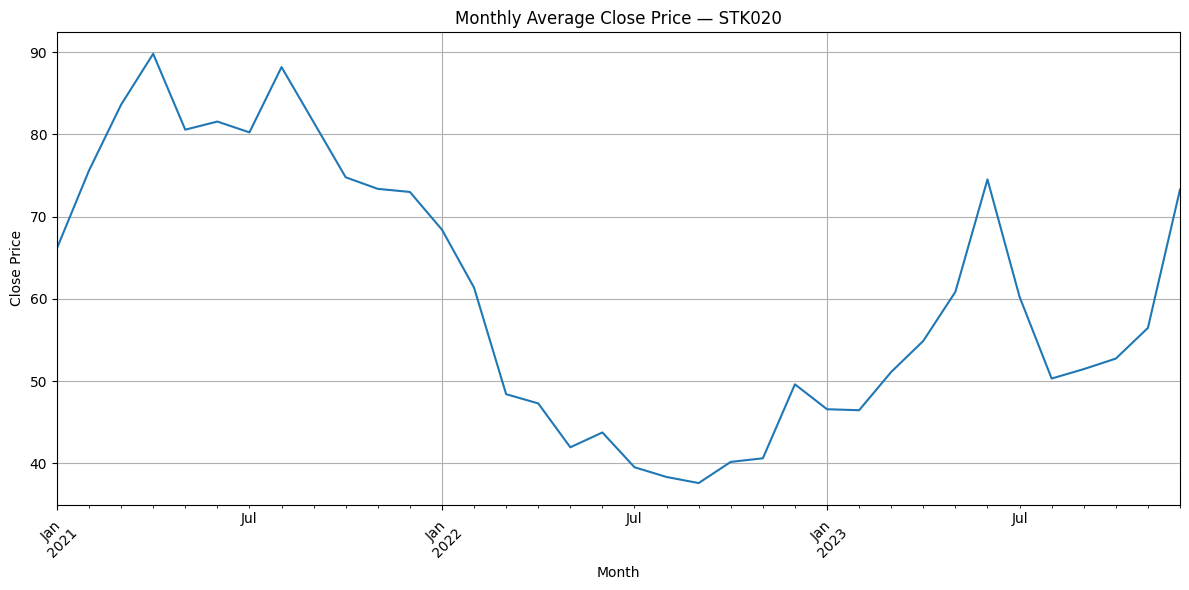

In [ ]:
monthly = (
    stk_prices_indicators
    .set_index("mnth_yr")
    .groupby("ticker")["close"]
    .resample("ME")
    .mean()
)
tickers = stk_prices_indicators["ticker"].unique()

for t in tickers:
    plt.figure(figsize=(12,6))

    # Plot monthly averages
    monthly.loc[t].plot()

    plt.title(f"Monthly Average Close Price — {t}")
    plt.xlabel("Month")
    plt.ylabel("Close Price")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


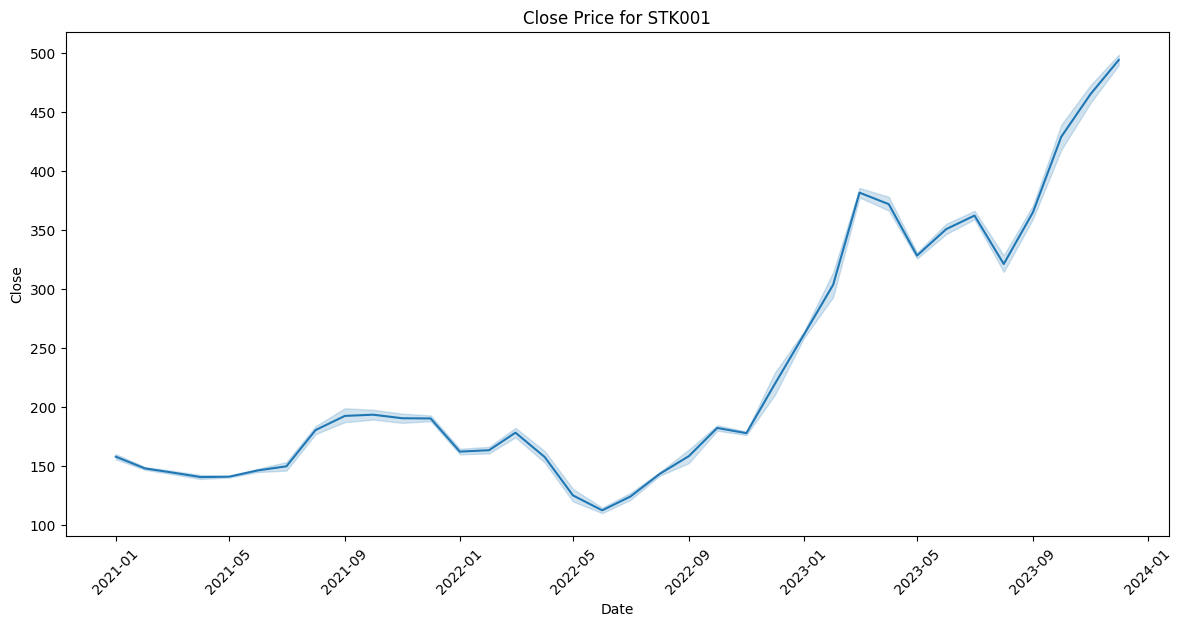

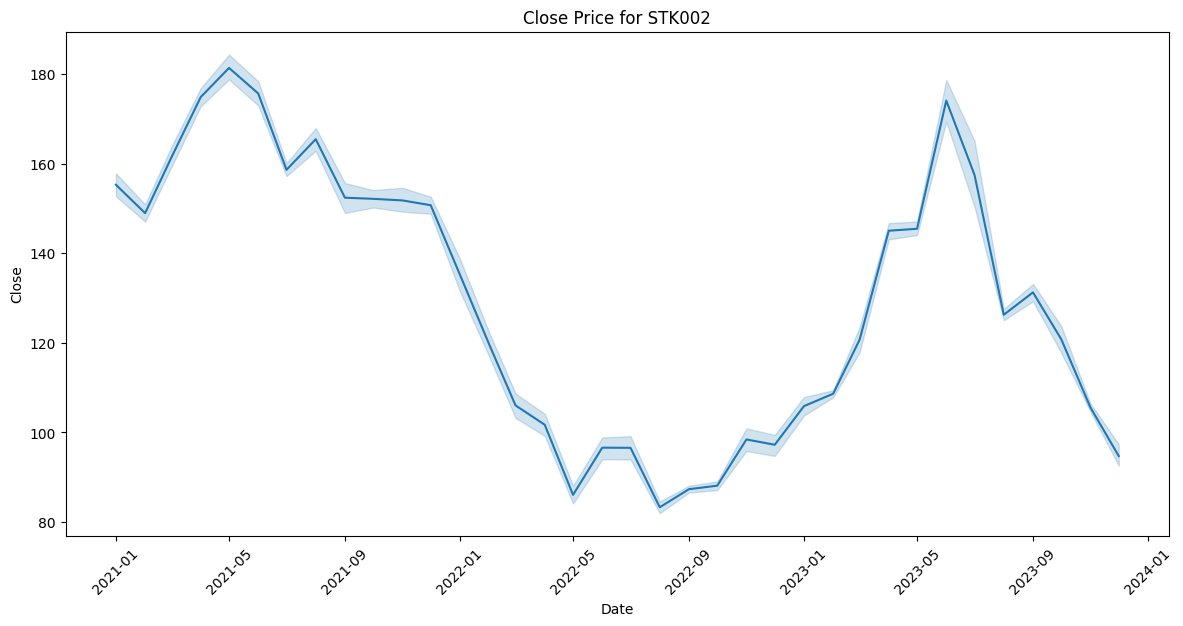

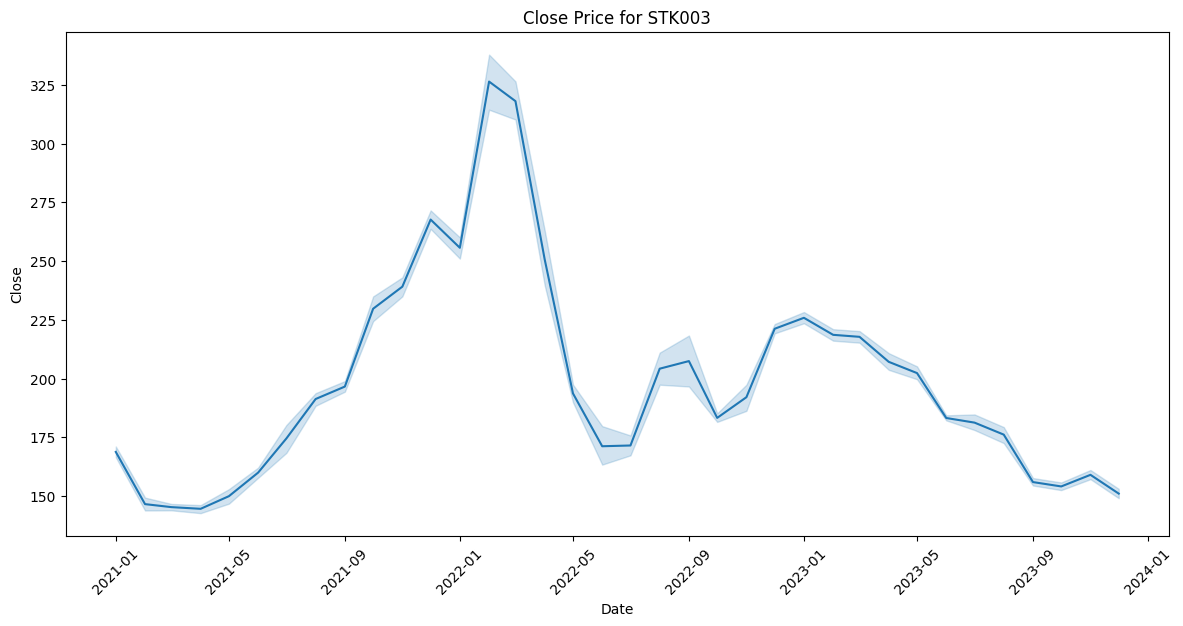

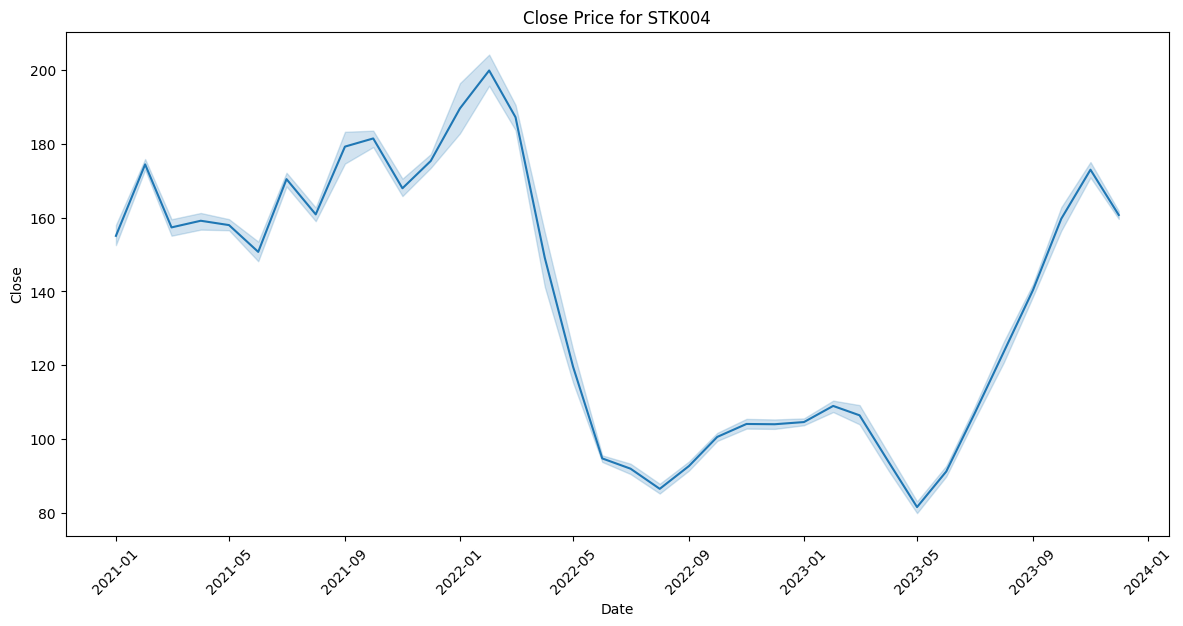

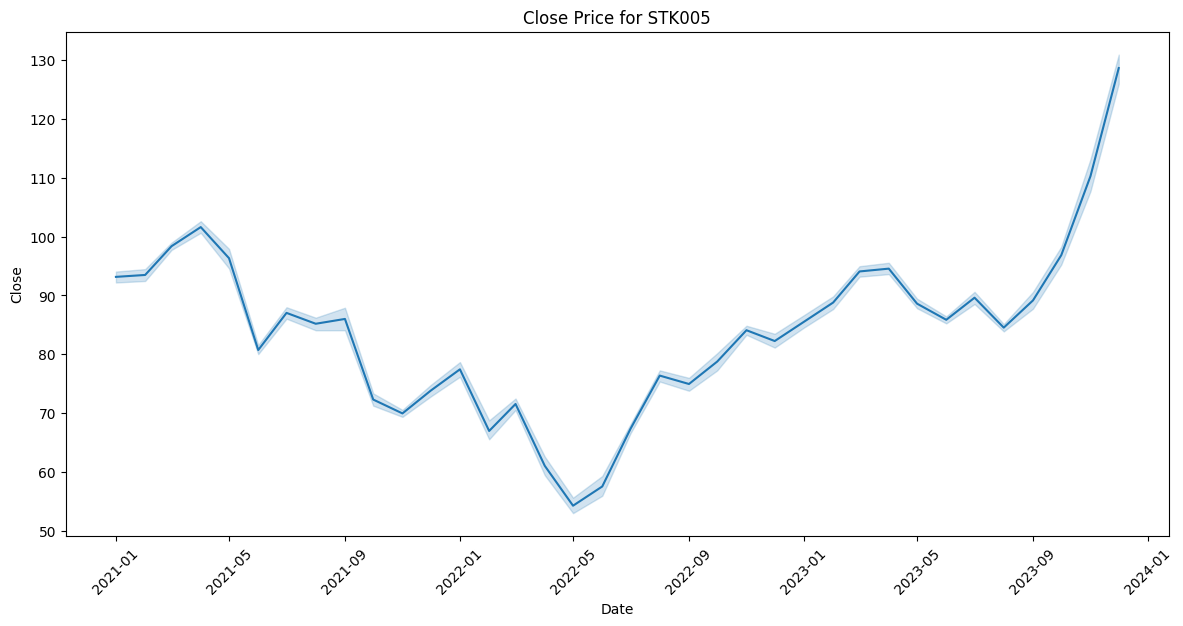

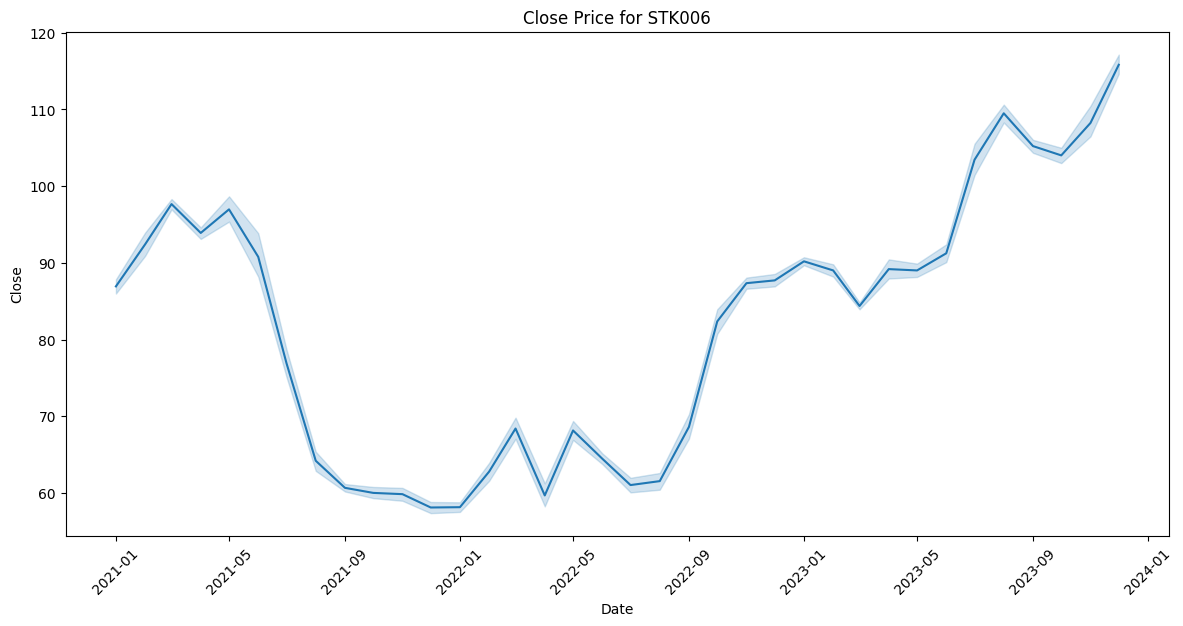

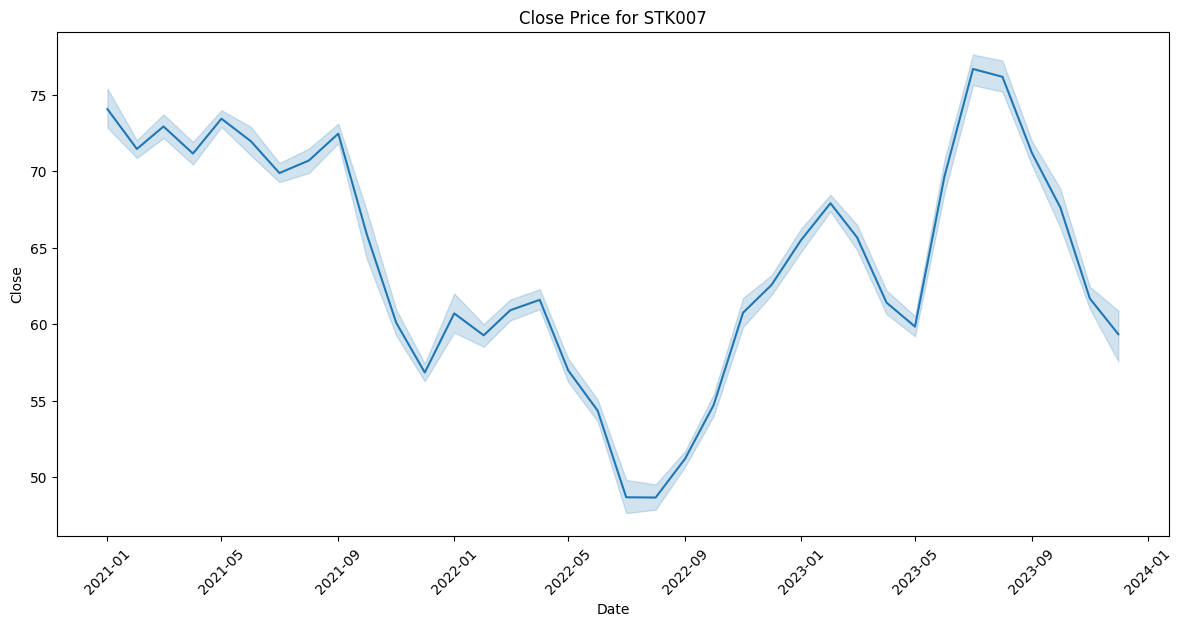

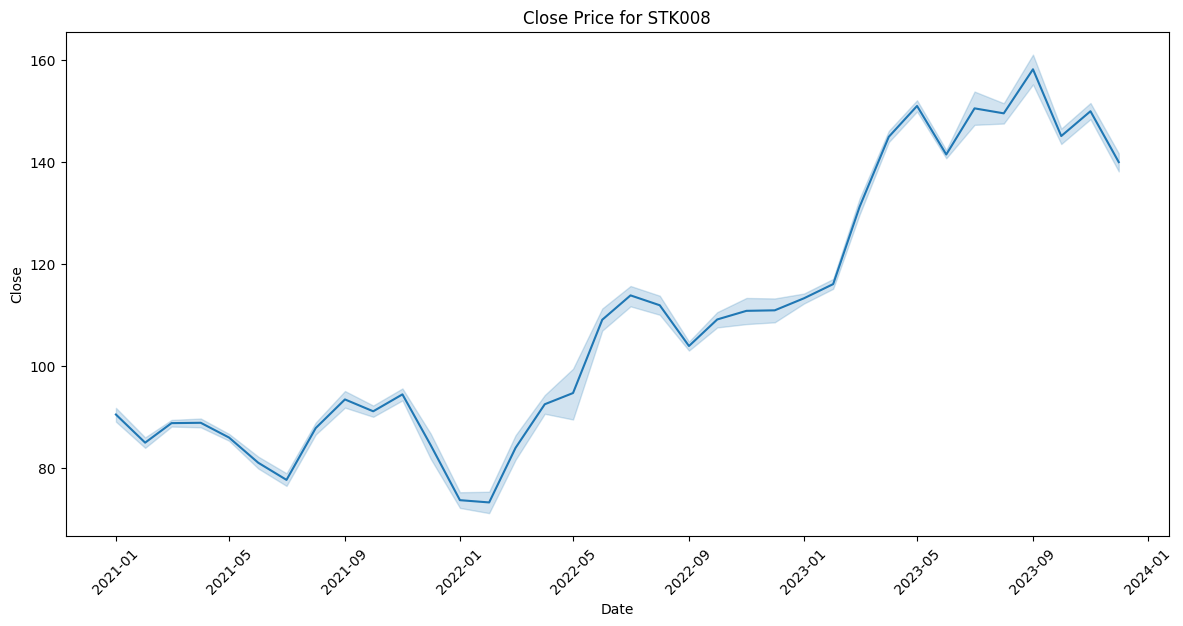

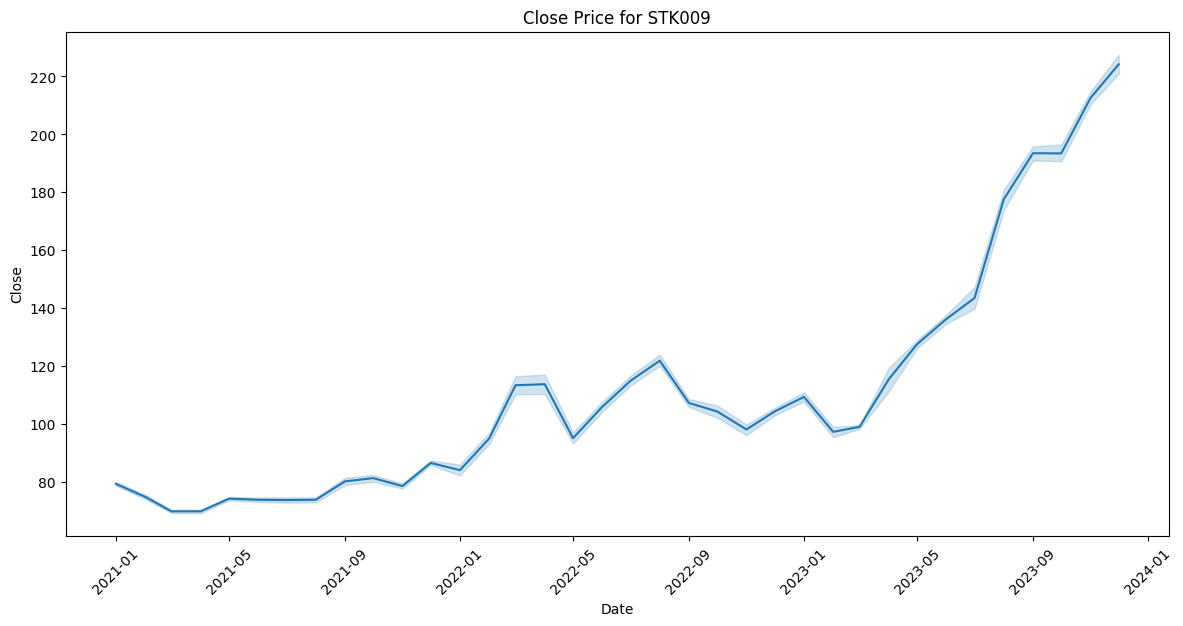

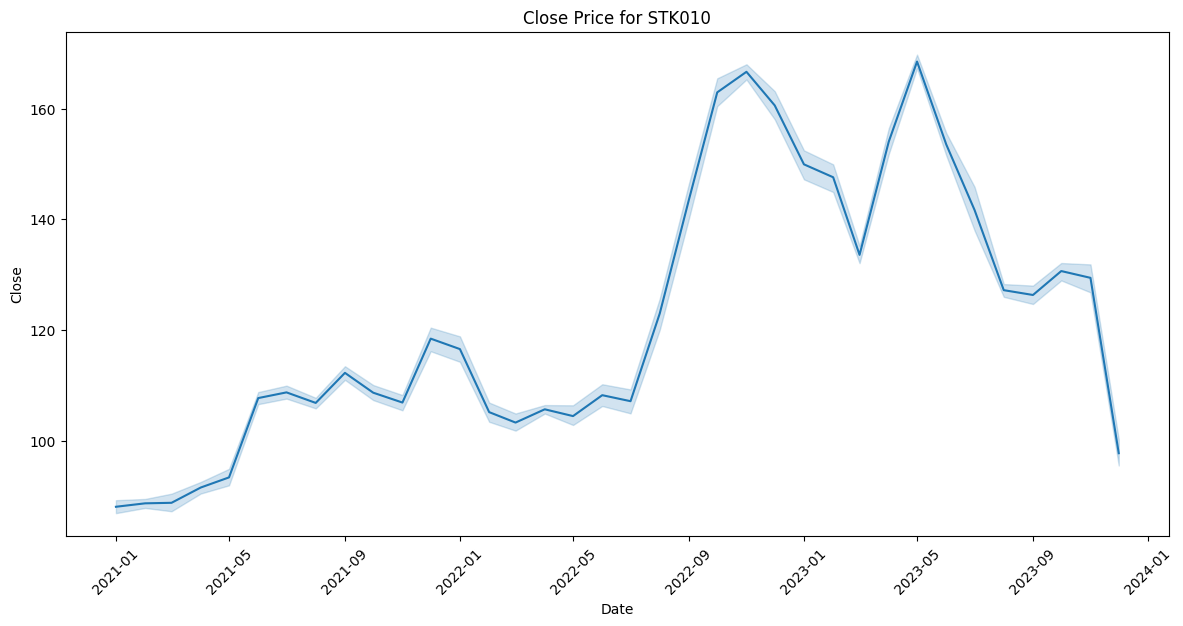

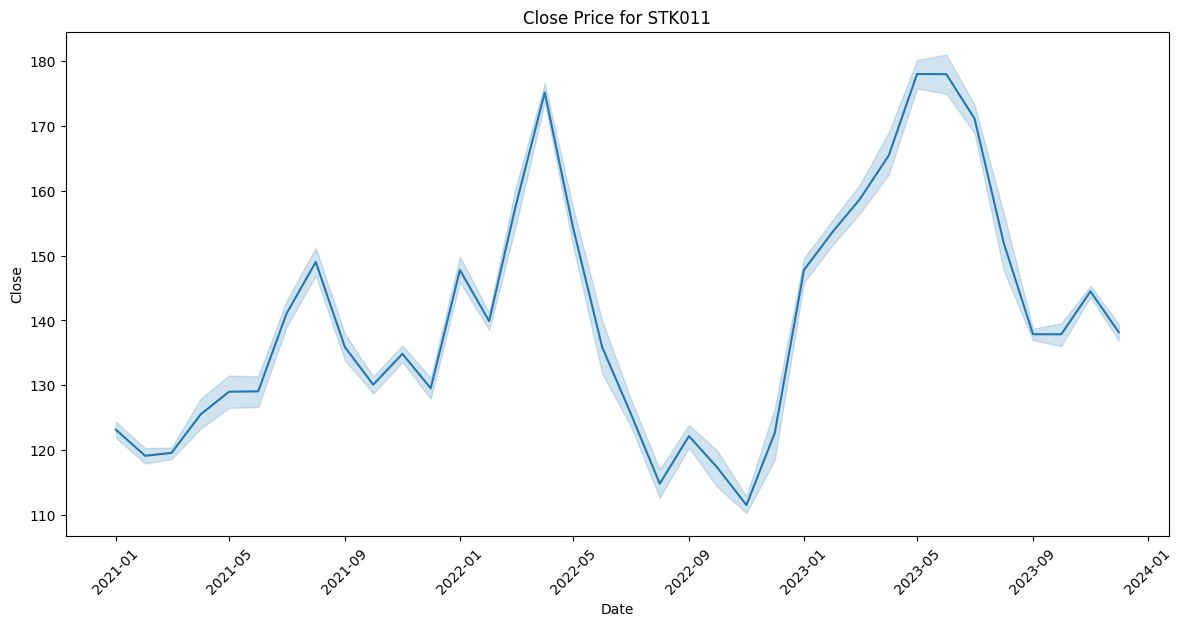

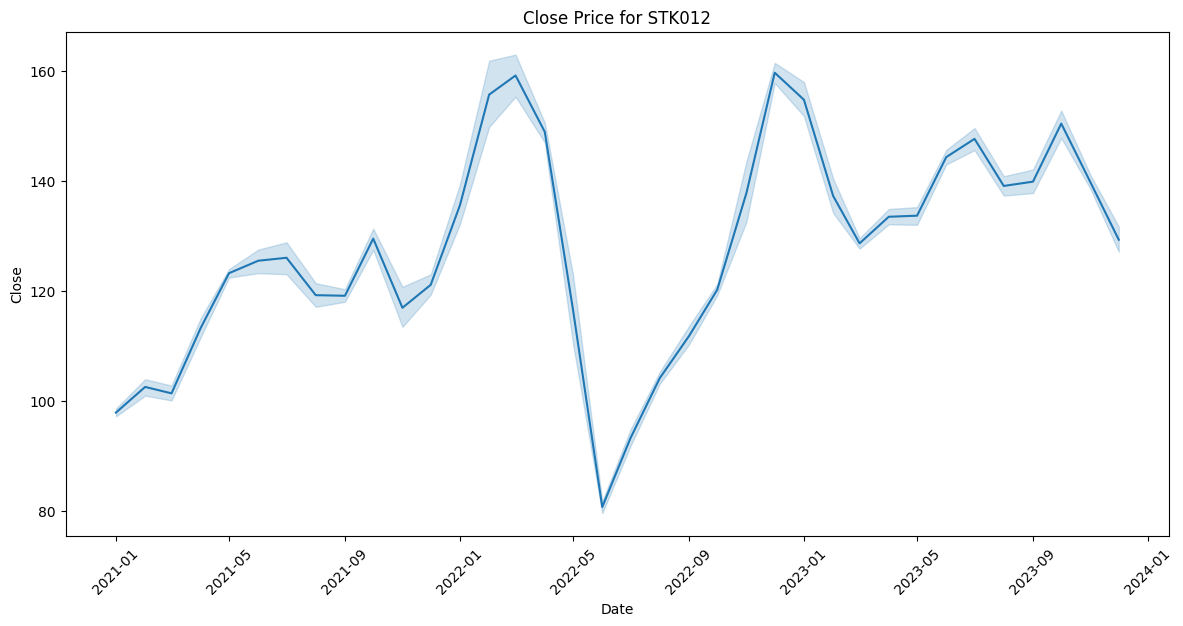

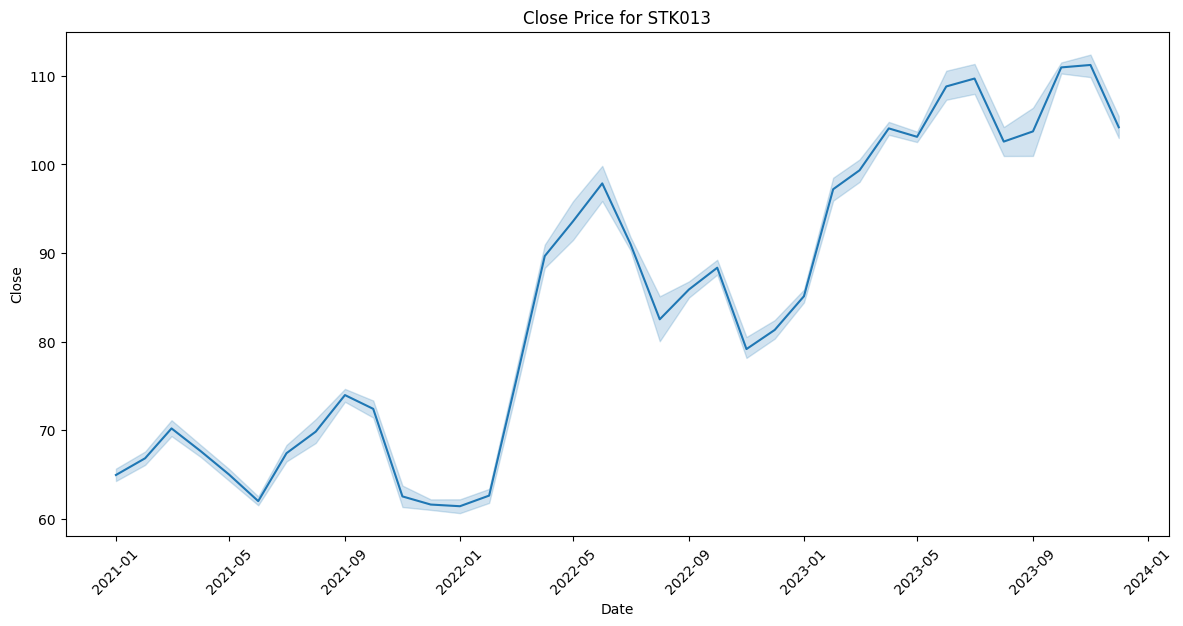

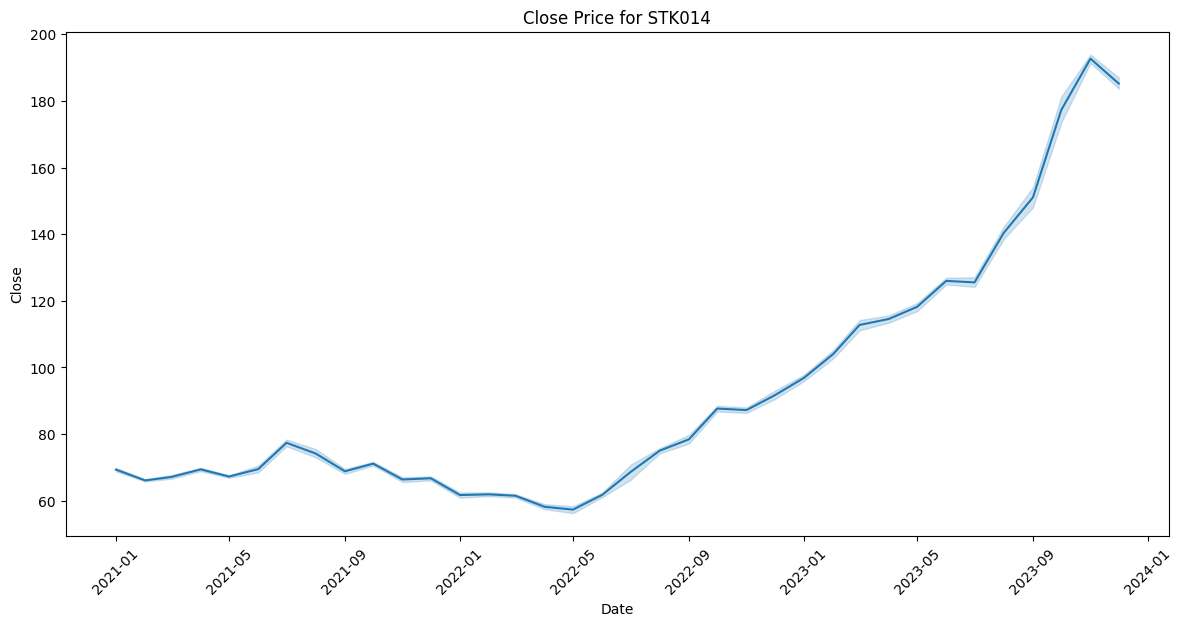

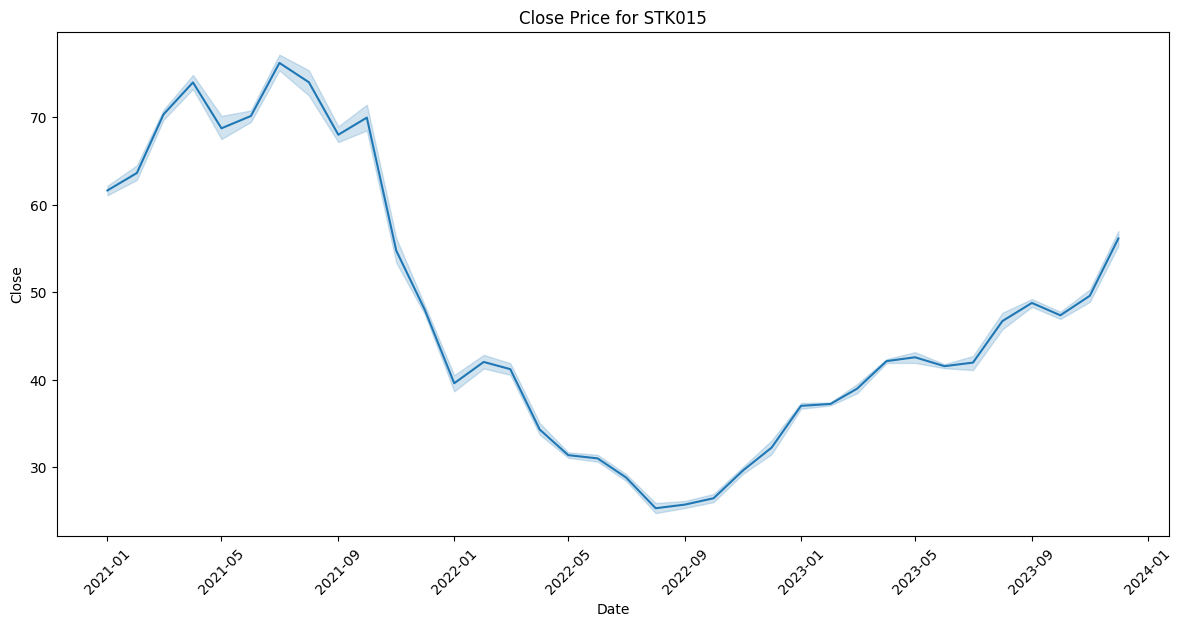

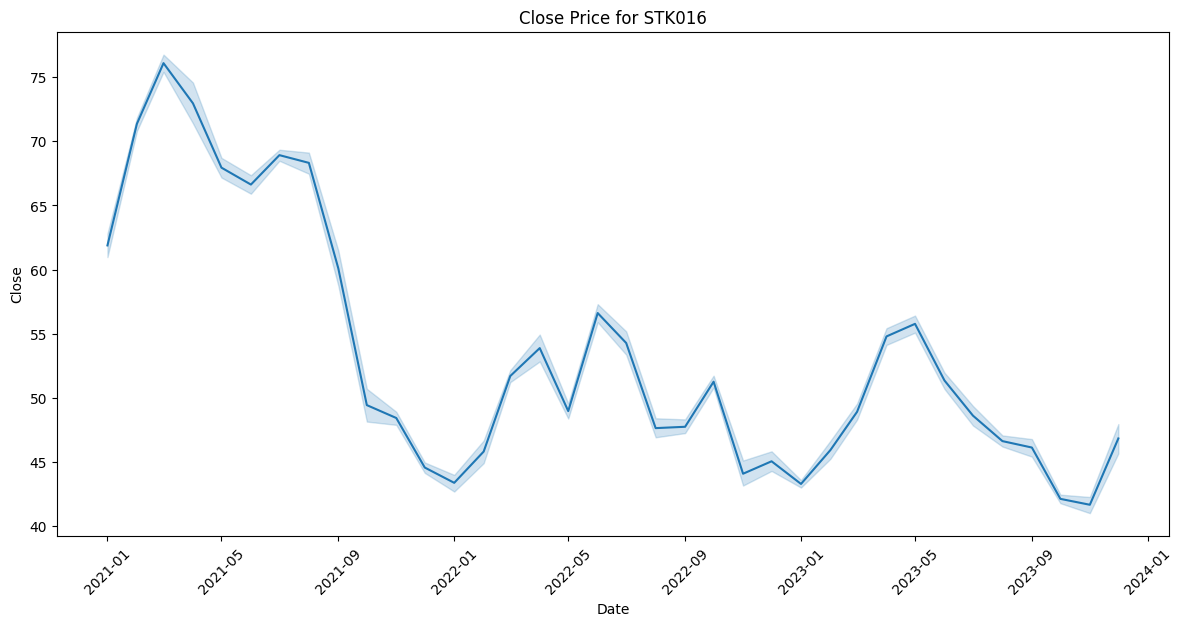

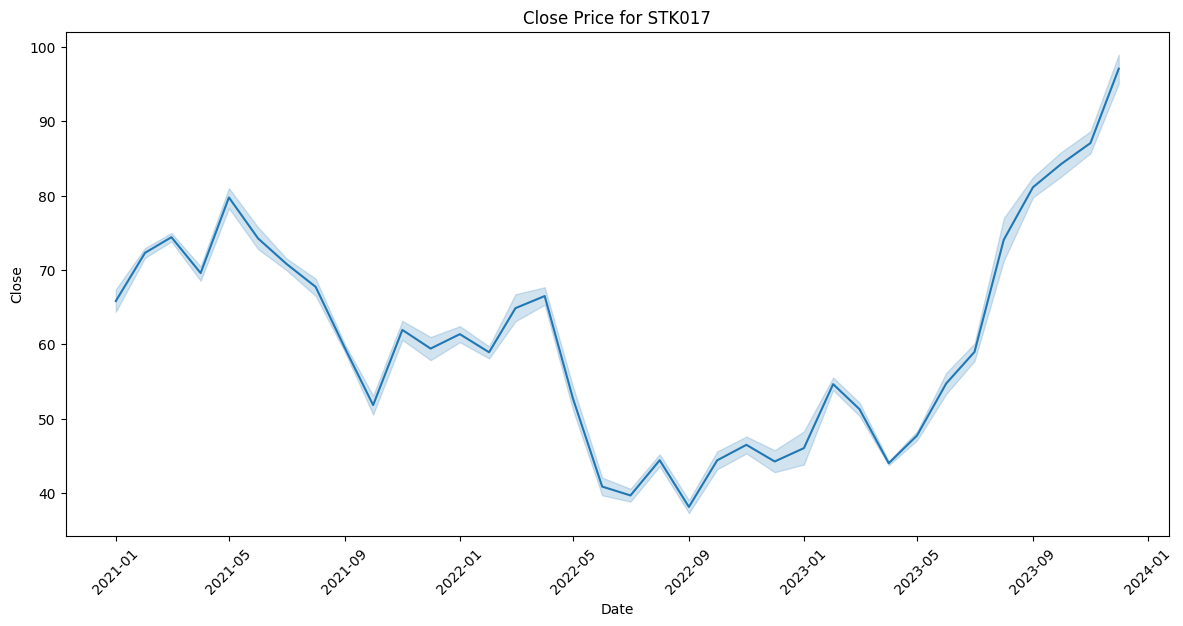

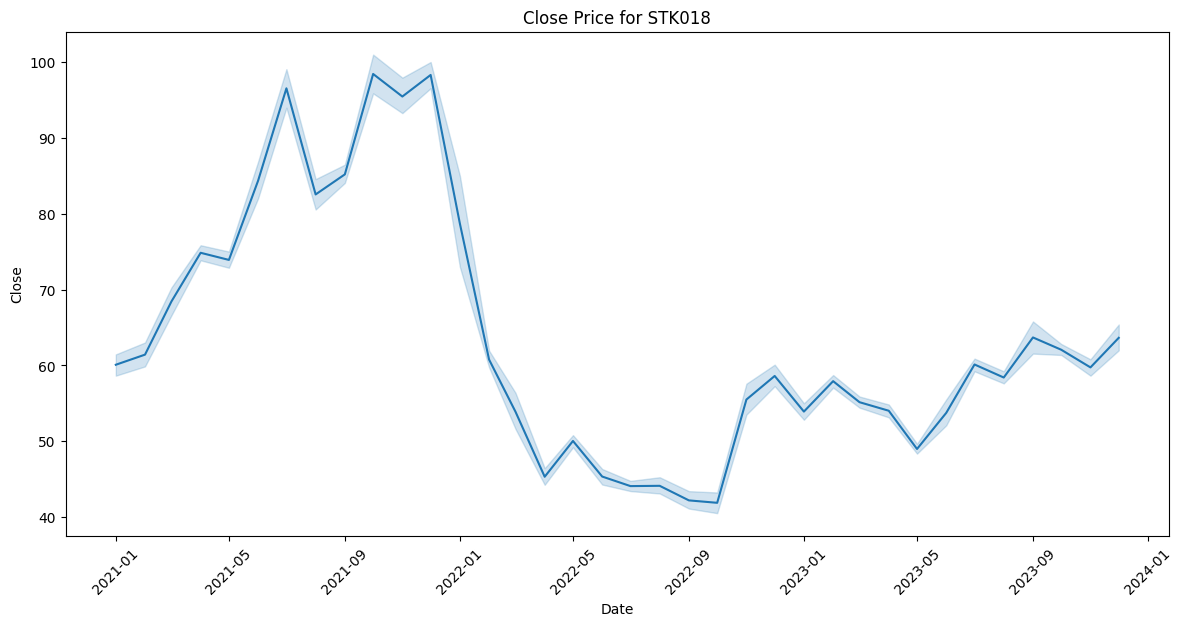

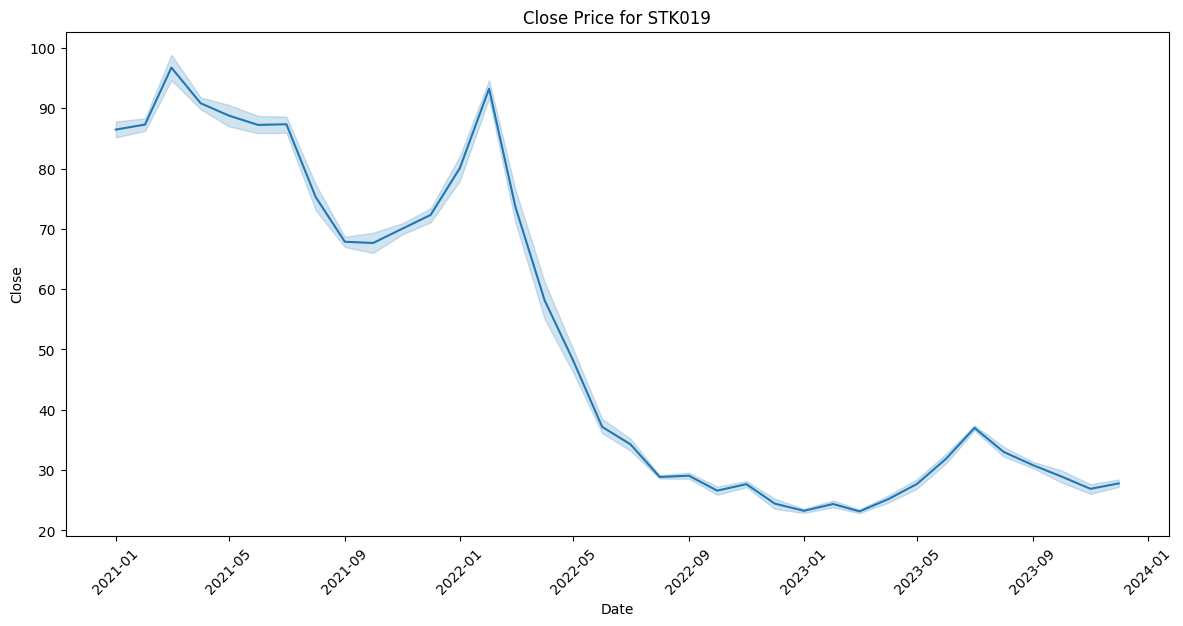

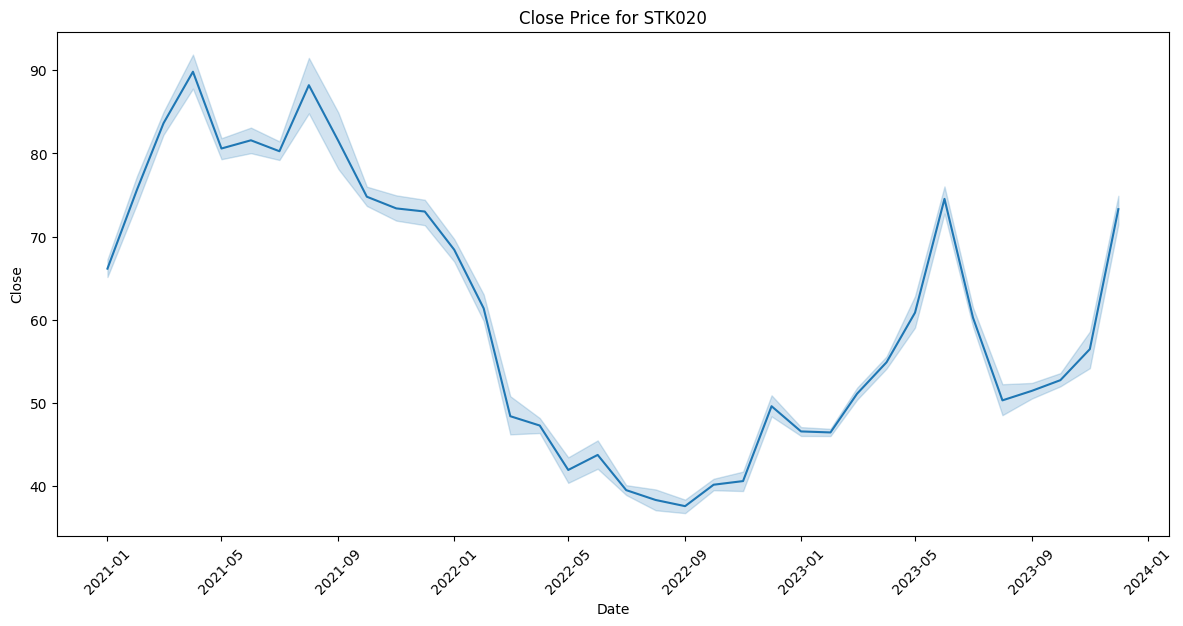

In [9]:
tickers = stk_prices['ticker'].unique()

for t in tickers:
    plt.figure(figsize=(12,6))
    sns.lineplot(data=stk_prices[stk_prices['ticker'] == t], 
                 x='mnth_yr', y='close')
    plt.title(f"Close Price for {t}")
    plt.xlabel("Date")
    plt.ylabel("Close")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()


C:\Users\ofori\AppData\Local\Temp\ipykernel_18816\962844134.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stk_prices2['close'].resample('M').mean().plot(figsize=(12,6))


<Axes: xlabel='date'>

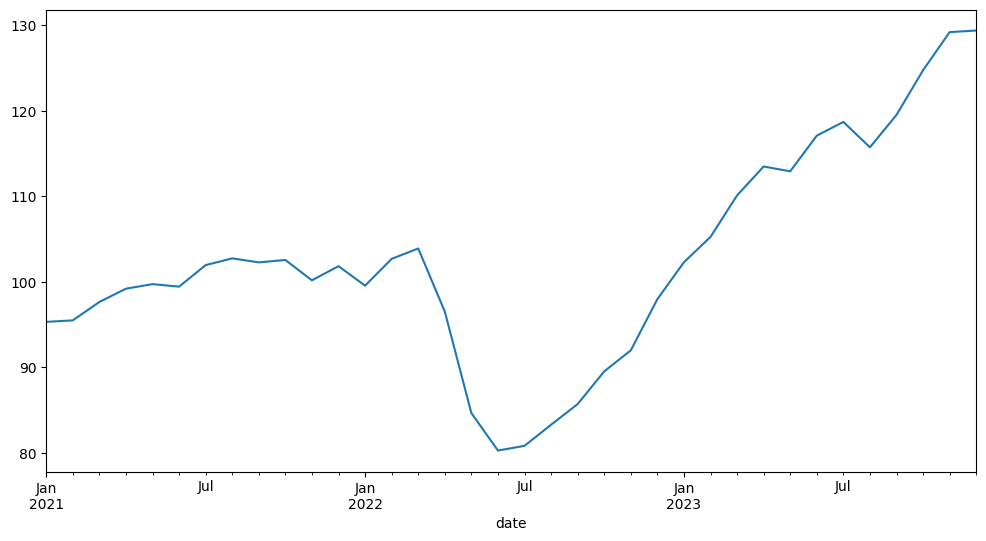